# Notebook 29 — Full-protocol Level 1–3 audit for DC–AC charging

## Objective

This notebook audits DC–AC charging under a full CC–CV protocol using a three-level validation structure.

### Level 1 — Operational protocol effectiveness

Test whether DC–AC charging reaches the same net charge state $Q_\mathrm{net}$ / SOC earlier than the corresponding DC reference under the same peak-current and voltage constraints.

### Level 2 — Common-CC current-geometry separation

In the shared prescribed-current CC region before either protocol reaches 4.2 V, decompose:

$$
\Delta t_\mathrm{model}(Q)
=
\Delta t_\mathrm{geom}(Q)
+
\Delta t_\mathrm{resid}(Q)
$$

where $\Delta t_\mathrm{geom}(Q)$ is computed only from the imposed current waveform.

### Level 3 — Boundary/CV contribution audit

After the 4.2 V boundary is reached by one branch, analyze whether the remaining full-protocol time gain is preserved, amplified, or consumed through boundary timing, AC-off transition, and CV feedback trajectory.

---

## Scope

This notebook does not claim universal electrochemical acceleration. It separates:

- current-waveform first-passage geometry,
- voltage-boundary timing,
- control-state transition,
- CV feedback trajectory,
- possible non-geometric electrochemical residual.

The full-protocol time difference is interpreted as a layered quantity:

$$
\Delta t_\mathrm{full}(Q)
=
\Delta t_\mathrm{CC,geom}(Q)
+
\Delta t_\mathrm{boundary/CV}(Q)
+
\Delta t_\mathrm{possible\,resid}(Q)
$$

The prescribed-current CC region is treated separately from the voltage-limited and CV-controlled regions.

---

## Initial parameter sets

The first audit uses parameter sets previously validated in the Day18B CC-only residual null baseline:

- Chen2020
- Ecker2015
- ORegan2022

These parameter sets are used first because their prescribed-current CC-only behavior already showed:

$$
\Delta t_\mathrm{model}(Q) \approx \Delta t_\mathrm{geom}(Q)
$$

and therefore:

$$
\Delta t_\mathrm{resid}(Q) \approx 0
$$

within numerical resolution.

---

## Initial conditions

The first audit starts with selected DC–AC protocols satisfying:

$$
I_\mathrm{DC} + I_\mathrm{AC} \leq 1C
$$

and uses the charge-first convention aligned with the experimental NGU201 ARB waveform:

$$
I_\mathrm{py}(t) = -I_\mathrm{DC} - I_\mathrm{AC}\sin(2\pi f t)
$$

where PyBaMM uses negative current for charging.

For analysis, the charging-positive current is reconstructed as:

$$
I_\mathrm{chg}(t) = -I_\mathrm{py}(t)
$$

therefore:

$$
I_\mathrm{chg}(t) = I_\mathrm{DC} + I_\mathrm{AC}\sin(2\pi f t)
$$

---

## Geometry reference

The geometry reference is computed only from the prescribed current waveform:

$$
Q_\mathrm{geom}^{DC}(t)
=
\int_0^t I_\mathrm{DC} \, d\tau
$$

$$
Q_\mathrm{geom}^{DCAC}(t)
=
\int_0^t
\left[
I_\mathrm{DC}
+
I_\mathrm{AC}\sin(2\pi f \tau)
\right]
d\tau
$$

For a target charge state $Q^\*$, the first-passage time is:

$$
t(Q^\*) = \inf \{t \mid Q(t) \geq Q^\* \}
$$

and the geometry-only time difference is:

$$
\Delta t_\mathrm{geom}(Q)
=
t_\mathrm{geom}^{DC}(Q)
-
t_\mathrm{geom}^{DCAC}(Q)
$$

No voltage, SOC model state, DFN internal variable, or 4.2 V event is allowed in the geometry reference.

---

## Shared CC window

The Level 2 residual audit is only valid inside the common prescribed-current CC region:

$$
Q_\mathrm{hi,A}
=
\min
\left(
Q_{4.2V,DC},
Q_{4.2V,DCAC}
\right)
-
Q_\mathrm{margin}
$$

Only targets satisfying:

$$
Q_\mathrm{lo} \leq Q \leq Q_\mathrm{hi,A}
$$

are used for the common-CC residual decomposition.

Once either branch reaches 4.2 V, the system leaves the pure prescribed-current comparison domain. Boundary timing and CV feedback must then be treated as separate Level 3 contributions.

---

## Planned outputs

This notebook writes four audit files:

- `data/day29_full_protocol_summary.csv`
- `data/day29_full_delta_tQ_curves.csv`
- `data/day29_cc_geometry_residual.csv`
- `data/day29_segment_incremental_gain.csv`

---

## Interpretation boundary

A positive full-protocol $\Delta t(Q)$ validates protocol-level effectiveness under the tested conditions.

A near-zero common-CC $\Delta t_\mathrm{resid}(Q)$ means that the common prescribed-current CC gain is current-geometry dominated.

Only a stable positive residual beyond current geometry and numerical floor supports a non-geometric internal contribution.

The expected conservative interpretation is:

> DC–AC charging can be operationally effective under specific frequency, amplitude, and control-boundary conditions, but full-protocol gains must be decomposed before assigning them to internal electrochemical acceleration.

In [2]:
# Cell 1 — Imports and environment check（导入库与环境检查）

from pathlib import Path
import math
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import pybamm
except Exception as e:
    raise RuntimeError(f"PyBaMM import failed: {e}")


def find_repo_root(start: Path) -> Path:
    """
    Locate repository root from either repo root or notebooks/ working directory.
    The expected repo contains both data/ and notebooks/.
    """
    start = start.resolve()
    candidates = [start, *start.parents]
    for p in candidates:
        if (p / "data").exists() and (p / "notebooks").exists():
            return p
    raise FileNotFoundError(
        f"Could not locate repo root from {start}. "
        "Expected a parent directory containing both data/ and notebooks/."
    )


CWD = Path.cwd()
REPO = find_repo_root(CWD)
DATA_DIR = REPO / "data"
NOTEBOOKS_DIR = REPO / "notebooks"

print("[cwd]", CWD)
print("[repo]", REPO)
print("[data dir exists]", DATA_DIR.exists())
print("[notebooks dir exists]", NOTEBOOKS_DIR.exists())
print("[pybamm version]", pybamm.__version__)

assert pybamm.__version__ == "26.3.1", (
    f"Unexpected PyBaMM version: {pybamm.__version__}. "
    "This notebook was designed against PyBaMM 26.3.1."
)

OUT_SUMMARY = DATA_DIR / "day29_full_protocol_summary.csv"
OUT_DTQ = DATA_DIR / "day29_full_delta_tQ_curves.csv"
OUT_CC_RESID = DATA_DIR / "day29_cc_geometry_residual.csv"
OUT_SEGMENT = DATA_DIR / "day29_segment_incremental_gain.csv"

for p in [OUT_SUMMARY, OUT_DTQ, OUT_CC_RESID, OUT_SEGMENT]:
    print("[planned output]", p.relative_to(REPO))

print("[OK] Environment and repository root resolved.")

[cwd] /Users/louislu/pybamm-dcac-superimposed/notebooks
[repo] /Users/louislu/pybamm-dcac-superimposed
[data dir exists] True
[notebooks dir exists] True
[pybamm version] 26.3.1
[planned output] data/day29_full_protocol_summary.csv
[planned output] data/day29_full_delta_tQ_curves.csv
[planned output] data/day29_cc_geometry_residual.csv
[planned output] data/day29_segment_incremental_gain.csv
[OK] Environment and repository root resolved.


In [3]:
# Cell 2 — Day29 audit configuration（Day29审计配置）

TAU_LABEL_S = 11.1

FREQS = {
    "0.1tau": 1.0 / (2 * math.pi * (0.1 * TAU_LABEL_S)),
    "1tau":   1.0 / (2 * math.pi * TAU_LABEL_S),
    "5tau":   1.0 / (2 * math.pi * (5.0 * TAU_LABEL_S)),
    "10tau":  1.0 / (2 * math.pi * (10.0 * TAU_LABEL_S)),
}

PARAMETER_SETS = [
    "Chen2020",
    "Ecker2015",
    "ORegan2022",
]

CONDITIONS = [
    {
        "pair_id": "P01_0p3DC_vs_0p3p0p7_10tau",
        "dc_ref_c": 0.3,
        "dcac_dc_c": 0.3,
        "dcac_ac_c": 0.7,
        "freq_label": "10tau",
        "role": "MJ1-main-effect analogue",
    },
    {
        "pair_id": "P02_0p3DC_vs_0p3p0p7_1tau",
        "dc_ref_c": 0.3,
        "dcac_dc_c": 0.3,
        "dcac_ac_c": 0.7,
        "freq_label": "1tau",
        "role": "frequency contrast",
    },
    {
        "pair_id": "P03_0p3DC_vs_0p3p0p7_0p1tau",
        "dc_ref_c": 0.3,
        "dcac_dc_c": 0.3,
        "dcac_ac_c": 0.7,
        "freq_label": "0.1tau",
        "role": "event-dominant / misleading contrast",
    },
    {
        "pair_id": "P04_0p2DC_vs_0p2p0p8_10tau",
        "dc_ref_c": 0.2,
        "dcac_dc_c": 0.2,
        "dcac_ac_c": 0.8,
        "freq_label": "10tau",
        "role": "high-kappa boundary case",
    },
    {
        "pair_id": "P05_0p4DC_vs_0p4p0p6_5tau",
        "dc_ref_c": 0.4,
        "dcac_dc_c": 0.4,
        "dcac_ac_c": 0.6,
        "freq_label": "5tau",
        "role": "higher-DC boundary compression case",
    },
]

cfg_rows = []
for c in CONDITIONS:
    amp_sum = c["dcac_dc_c"] + c["dcac_ac_c"]
    assert amp_sum <= 1.0 + 1e-12, f"Amplitude constraint violated: {c}"
    cfg_rows.append({
        **c,
        "dcac_kappa": c["dcac_ac_c"] / c["dcac_dc_c"],
        "frequency_hz": FREQS[c["freq_label"]],
        "tau_label_s": TAU_LABEL_S,
        "amp_sum_c": amp_sum,
    })

df_cfg = pd.DataFrame(cfg_rows)
display(df_cfg)

print("[OK] Day29 initial condition table frozen.")

,pair_id,dc_ref_c,dcac_dc_c,dcac_ac_c,freq_label,role,dcac_kappa,frequency_hz,tau_label_s,amp_sum_c
0,P01_0p3DC_vs_0p3p0p7_10tau,0.3,0.3,0.7,10tau,MJ1-main-effect analogue,2.333333,0.001434,11.1,1.0
1,P02_0p3DC_vs_0p3p0p7_1tau,0.3,0.3,0.7,1tau,frequency contrast,2.333333,0.014338,11.1,1.0
2,P03_0p3DC_vs_0p3p0p7_0p1tau,0.3,0.3,0.7,0.1tau,event-dominant / misleading contrast,2.333333,0.143383,11.1,1.0
3,P04_0p2DC_vs_0p2p0p8_10tau,0.2,0.2,0.8,10tau,high-kappa boundary case,4.000000,0.001434,11.1,1.0
4,P05_0p4DC_vs_0p4p0p6_5tau,0.4,0.4,0.6,5tau,higher-DC boundary compression case,1.500000,0.002868,11.1,1.0


[OK] Day29 initial condition table frozen.


In [4]:
# Cell 3 — Parameter-set loading and C-rate basis（参数集加载与C-rate基准检查）

def load_parameter_values(name: str):
    """
    Load a PyBaMM parameter set by name and extract nominal capacity.
    C-rate currents are computed from nominal capacity:
        I_1C [A] = Q_nom [Ah] / 1 h
    """
    try:
        pv = pybamm.ParameterValues(name)
    except Exception as e:
        raise RuntimeError(f"Failed to load parameter set {name}: {e}")

    # Most PyBaMM Li-ion parameter sets define this key.
    cap_key = "Nominal cell capacity [A.h]"
    if cap_key not in pv:
        raise KeyError(f"{name} does not contain '{cap_key}'")

    q_nom_ah = float(pv[cap_key])
    i_1c_a = q_nom_ah

    return pv, q_nom_ah, i_1c_a


param_records = []
PARAM_VALUES = {}

for name in PARAMETER_SETS:
    pv, q_nom_ah, i_1c_a = load_parameter_values(name)
    PARAM_VALUES[name] = pv

    param_records.append({
        "parameter_set": name,
        "Q_nom_Ah": q_nom_ah,
        "I_1C_A": i_1c_a,
        "I_0p2C_A": 0.2 * i_1c_a,
        "I_0p3C_A": 0.3 * i_1c_a,
        "I_0p4C_A": 0.4 * i_1c_a,
        "I_0p7C_A": 0.7 * i_1c_a,
        "I_0p8C_A": 0.8 * i_1c_a,
    })

df_params = pd.DataFrame(param_records)
display(df_params)

assert len(df_params) == len(PARAMETER_SETS)
assert (df_params["Q_nom_Ah"] > 0).all()

print("[OK] Parameter sets loaded and nominal C-rate basis extracted.")

,parameter_set,Q_nom_Ah,I_1C_A,I_0p2C_A,I_0p3C_A,I_0p4C_A,I_0p7C_A,I_0p8C_A
0,Chen2020,5.00000,5.00000,1.00000,1.500000,2.0000,3.500000,4.000
1,Ecker2015,0.15625,0.15625,0.03125,0.046875,0.0625,0.109375,0.125
2,ORegan2022,5.00000,5.00000,1.00000,1.500000,2.0000,3.500000,4.000


[OK] Parameter sets loaded and nominal C-rate basis extracted.


[sanity case] P01_0p3DC_vs_0p3p0p7_10tau
[parameter basis] Chen2020
[I_1C_A] 5.0
[frequency_hz] 0.0014338283161432013
[period_s] 697.4335690969341
[period_min] 11.623892818282235
[I_chg min/max A] -1.999995673400091 4.999995673400091
[I_py min/max A] -4.999995673400091 1.999995673400091
[sanity case] P01_0p3DC_vs_0p3p0p7_10tau
[parameter basis] Chen2020
[I_1C_A] 5.0
[frequency_hz] 0.0014338283161432013
[period_s] 697.4335690969341
[period_min] 11.623892818282235
[I_chg min/max A] -1.999995673400091 4.999995673400091
[I_py min/max A] -4.999995673400091 1.999995673400091
[max |(-I_py) - I_chg| A] 0.0


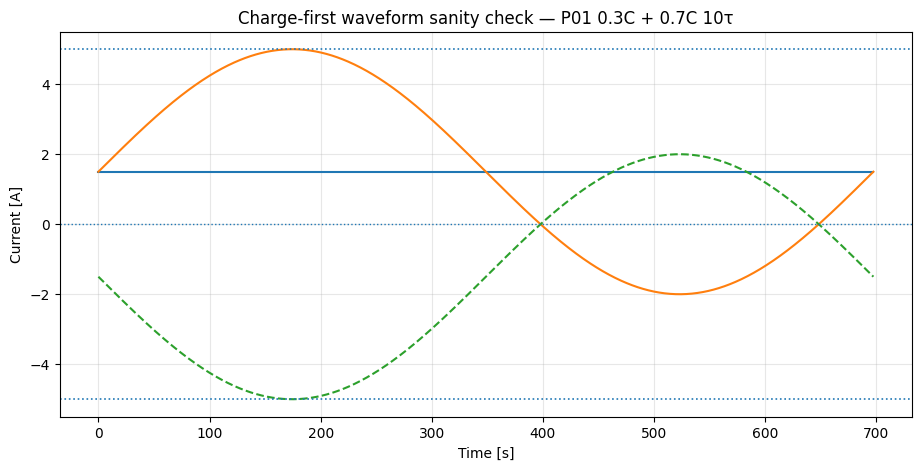

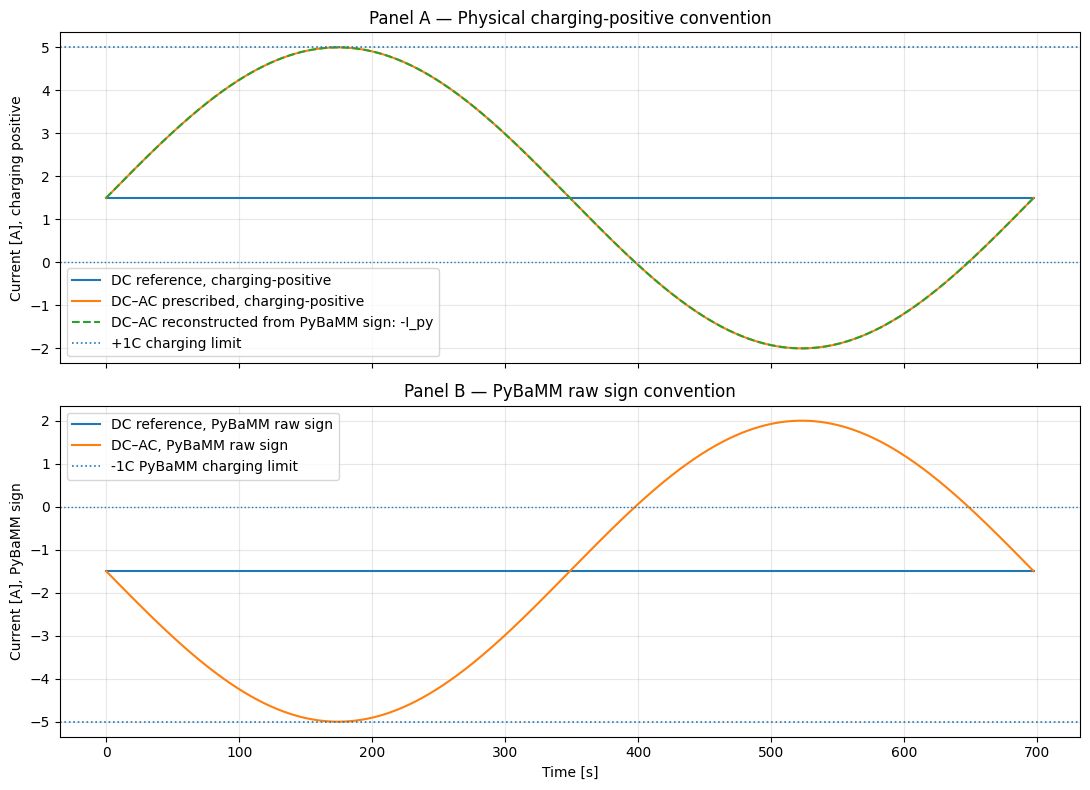

[OK] Charge-first current convention sanity plot passed with explicit sign reconstruction.
[OK] Charge-first current convention sanity plot passed.


In [6]:
# Cell 4 — Charge-first current convention sanity plot（charge-first 电流相位审计图）

def dc_current_chg_positive(t_s, dc_c, i_1c_a):
    """
    Charging-positive DC current in ampere.
    """
    return dc_c * i_1c_a * np.ones_like(np.asarray(t_s, dtype=float))


def dcac_current_chg_positive(t_s, dc_c, ac_c, frequency_hz, i_1c_a):
    """
    Charging-positive experimental/analysis convention:
        I_chg(t) = I_DC + I_AC * sin(2*pi*f*t)
    """
    t_s = np.asarray(t_s, dtype=float)
    i_dc = dc_c * i_1c_a
    i_ac = ac_c * i_1c_a
    return i_dc + i_ac * np.sin(2 * np.pi * frequency_hz * t_s)


def dcac_current_pybamm_sign(t_s, dc_c, ac_c, frequency_hz, i_1c_a):
    """
    PyBaMM convention: negative current charges the cell.
        I_py(t) = -I_DC - I_AC * sin(2*pi*f*t)
    """
    return -dcac_current_chg_positive(t_s, dc_c, ac_c, frequency_hz, i_1c_a)


# Use Chen2020 only for the visual current-amplitude basis.
plot_param = "Chen2020"
i_1c_plot = float(df_params.loc[df_params["parameter_set"] == plot_param, "I_1C_A"].iloc[0])

# Select one main case: 0.3C + 0.7C at 10tau
case = df_cfg.loc[df_cfg["pair_id"] == "P01_0p3DC_vs_0p3p0p7_10tau"].iloc[0].to_dict()

f = case["frequency_hz"]
period_s = 1.0 / f
t_plot = np.linspace(0, period_s, 1000)

i_dc_chg = dc_current_chg_positive(
    t_plot,
    dc_c=case["dc_ref_c"],
    i_1c_a=i_1c_plot,
)

i_dcac_chg = dcac_current_chg_positive(
    t_plot,
    dc_c=case["dcac_dc_c"],
    ac_c=case["dcac_ac_c"],
    frequency_hz=f,
    i_1c_a=i_1c_plot,
)

i_dcac_py = dcac_current_pybamm_sign(
    t_plot,
    dc_c=case["dcac_dc_c"],
    ac_c=case["dcac_ac_c"],
    frequency_hz=f,
    i_1c_a=i_1c_plot,
)

print("[sanity case]", case["pair_id"])
print("[parameter basis]", plot_param)
print("[I_1C_A]", i_1c_plot)
print("[frequency_hz]", f)
print("[period_s]", period_s)
print("[period_min]", period_s / 60)
print("[I_chg min/max A]", float(np.min(i_dcac_chg)), float(np.max(i_dcac_chg)))
print("[I_py min/max A]", float(np.min(i_dcac_py)), float(np.max(i_dcac_py)))

# Key audit assertions
assert np.isclose(np.max(i_dcac_chg), i_1c_plot, rtol=1e-3, atol=1e-6), "Peak charging current should be 1C"
assert np.isclose(np.min(i_dcac_chg), -0.4 * i_1c_plot, rtol=1e-3, atol=1e-6), "0.3C+0.7C should dip to -0.4C in charging-positive convention"
assert i_dcac_chg[1] > i_dcac_chg[0], "Charge-first convention failed: first half-wave should initially increase charging current"
assert i_dcac_py[1] < i_dcac_py[0], "PyBaMM current should become more negative at charge-first start"

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(t_plot, i_dc_chg, label="DC reference, charging-positive")
ax.plot(t_plot, i_dcac_chg, label="DC–AC, charging-positive")
ax.plot(t_plot, i_dcac_py, linestyle="--", label="DC–AC, PyBaMM sign")

ax.axhline(i_1c_plot, linestyle=":", linewidth=1.2, label="+1C charging limit")
ax.axhline(0.0, linestyle=":", linewidth=1.0)
ax.axhline(-i_1c_plot, linestyle=":", linewidth=1.2, label="-1C PyBaMM charge direction")

ax.set_title("Charge-first waveform sanity check — P01 0.3C + 0.7C 10τ")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Current [A]")
ax.grid(True, alpha=0.3)# Cell 4 — Charge-first current convention sanity plot（charge-first 电流相位审计图，修正版）

def dc_current_chg_positive(t_s, dc_c, i_1c_a):
    """
    Charging-positive DC current in ampere.
    """
    return dc_c * i_1c_a * np.ones_like(np.asarray(t_s, dtype=float))


def dcac_current_chg_positive(t_s, dc_c, ac_c, frequency_hz, i_1c_a):
    """
    Charging-positive experimental/analysis convention:
        I_chg(t) = I_DC + I_AC * sin(2*pi*f*t)
    """
    t_s = np.asarray(t_s, dtype=float)
    i_dc = dc_c * i_1c_a
    i_ac = ac_c * i_1c_a
    return i_dc + i_ac * np.sin(2 * np.pi * frequency_hz * t_s)


def dc_current_pybamm_sign(t_s, dc_c, i_1c_a):
    """
    PyBaMM convention:
        negative current charges the cell.
    """
    return -dc_current_chg_positive(t_s, dc_c, i_1c_a)


def dcac_current_pybamm_sign(t_s, dc_c, ac_c, frequency_hz, i_1c_a):
    """
    PyBaMM convention:
        I_py(t) = -I_DC - I_AC * sin(2*pi*f*t)
    """
    return -dcac_current_chg_positive(t_s, dc_c, ac_c, frequency_hz, i_1c_a)


# Use Chen2020 only for visual current-amplitude basis.
plot_param = "Chen2020"
i_1c_plot = float(df_params.loc[df_params["parameter_set"] == plot_param, "I_1C_A"].iloc[0])

# Select one main case: 0.3C + 0.7C at 10tau
case = df_cfg.loc[df_cfg["pair_id"] == "P01_0p3DC_vs_0p3p0p7_10tau"].iloc[0].to_dict()

f = case["frequency_hz"]
period_s = 1.0 / f
t_plot = np.linspace(0, period_s, 1000)

# Charging-positive convention
i_dc_chg = dc_current_chg_positive(
    t_plot,
    dc_c=case["dc_ref_c"],
    i_1c_a=i_1c_plot,
)

i_dcac_chg = dcac_current_chg_positive(
    t_plot,
    dc_c=case["dcac_dc_c"],
    ac_c=case["dcac_ac_c"],
    frequency_hz=f,
    i_1c_a=i_1c_plot,
)

# PyBaMM raw sign convention
i_dc_py = dc_current_pybamm_sign(
    t_plot,
    dc_c=case["dc_ref_c"],
    i_1c_a=i_1c_plot,
)

i_dcac_py = dcac_current_pybamm_sign(
    t_plot,
    dc_c=case["dcac_dc_c"],
    ac_c=case["dcac_ac_c"],
    frequency_hz=f,
    i_1c_a=i_1c_plot,
)

# Reconstructed charging-positive current from PyBaMM sign
i_dcac_chg_from_py = -i_dcac_py
i_dc_chg_from_py = -i_dc_py

print("[sanity case]", case["pair_id"])
print("[parameter basis]", plot_param)
print("[I_1C_A]", i_1c_plot)
print("[frequency_hz]", f)
print("[period_s]", period_s)
print("[period_min]", period_s / 60)
print("[I_chg min/max A]", float(np.min(i_dcac_chg)), float(np.max(i_dcac_chg)))
print("[I_py min/max A]", float(np.min(i_dcac_py)), float(np.max(i_dcac_py)))

# Audit assertions
assert np.isclose(i_dcac_chg[0], case["dcac_dc_c"] * i_1c_plot, rtol=1e-12, atol=1e-12)
assert np.isclose(i_dcac_py[0], -case["dcac_dc_c"] * i_1c_plot, rtol=1e-12, atol=1e-12)

assert np.isclose(
    np.max(i_dcac_chg),
    i_1c_plot,
    rtol=1e-3,
    atol=1e-6,
), "Peak charging-positive current should be +1C"

assert np.isclose(
    np.min(i_dcac_chg),
    -0.4 * i_1c_plot,
    rtol=1e-3,
    atol=1e-6,
), "0.3C+0.7C should dip to -0.4C in charging-positive convention"

assert i_dcac_chg[1] > i_dcac_chg[0], (
    "Charge-first convention failed: first half-wave should initially increase charging current"
)

assert i_dcac_py[1] < i_dcac_py[0], (
    "PyBaMM current should become more negative at charge-first start"
)

assert np.allclose(
    i_dcac_chg_from_py,
    i_dcac_chg,
    rtol=1e-12,
    atol=1e-12,
), "Reconstructed charging-positive current from PyBaMM sign does not match prescribed DCAC"

assert np.allclose(
    i_dc_chg_from_py,
    i_dc_chg,
    rtol=1e-12,
    atol=1e-12,
), "Reconstructed charging-positive DC current from PyBaMM sign does not match prescribed DC"

max_reconstruction_error = float(np.max(np.abs(i_dcac_chg_from_py - i_dcac_chg)))
print("[max |(-I_py) - I_chg| A]", max_reconstruction_error)

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

# Panel 1: charging-positive physical convention
axes[0].plot(t_plot, i_dc_chg, label="DC reference, charging-positive")
axes[0].plot(t_plot, i_dcac_chg, label="DC–AC prescribed, charging-positive")
axes[0].plot(
    t_plot,
    i_dcac_chg_from_py,
    linestyle="--",
    label="DC–AC reconstructed from PyBaMM sign: -I_py",
)

axes[0].axhline(i_1c_plot, linestyle=":", linewidth=1.2, label="+1C charging limit")
axes[0].axhline(0.0, linestyle=":", linewidth=1.0)
axes[0].set_title("Panel A — Physical charging-positive convention")
axes[0].set_ylabel("Current [A], charging positive")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="best")

# Panel 2: raw PyBaMM convention
axes[1].plot(t_plot, i_dc_py, label="DC reference, PyBaMM raw sign")
axes[1].plot(t_plot, i_dcac_py, label="DC–AC, PyBaMM raw sign")
axes[1].axhline(-i_1c_plot, linestyle=":", linewidth=1.2, label="-1C PyBaMM charging limit")
axes[1].axhline(0.0, linestyle=":", linewidth=1.0)
axes[1].set_title("Panel B — PyBaMM raw sign convention")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Current [A], PyBaMM sign")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()

print("[OK] Charge-first current convention sanity plot passed with explicit sign reconstruction.")
ax.legend(loc="best")
plt.show()

print("[OK] Charge-first current convention sanity plot passed.")

[smoke parameter set] Chen2020
[smoke case] P01_0p3DC_vs_0p3p0p7_10tau


,parameter_set,protocol_label,dc_c,ac_c,frequency_hz,initial_soc,Q_nom_Ah,I_1C_A,t_stop_s,t_stop_min,V_stop_V,Q_stop_Ah,Q_stop_frac_nominal,I_chg_last_A,termination,status,error_msg
0,Chen2020,DC_ref_CC_to_Vmax,0.3,0.0,0.001434,0.05,5.0,5.0,10782.817059,179.713618,4.19999,4.492840,0.898568,1.500000,event: Maximum voltage [V],ok,
1,Chen2020,DCAC_CC_to_Vmax,0.3,0.7,0.001434,0.05,5.0,5.0,10494.543245,174.909054,4.19999,4.377472,0.875494,2.526477,event: Maximum voltage [V],ok,


[expected DCAC I_chg(0) A] 1.5
[observed DCAC I_chg(0) A] 1.5


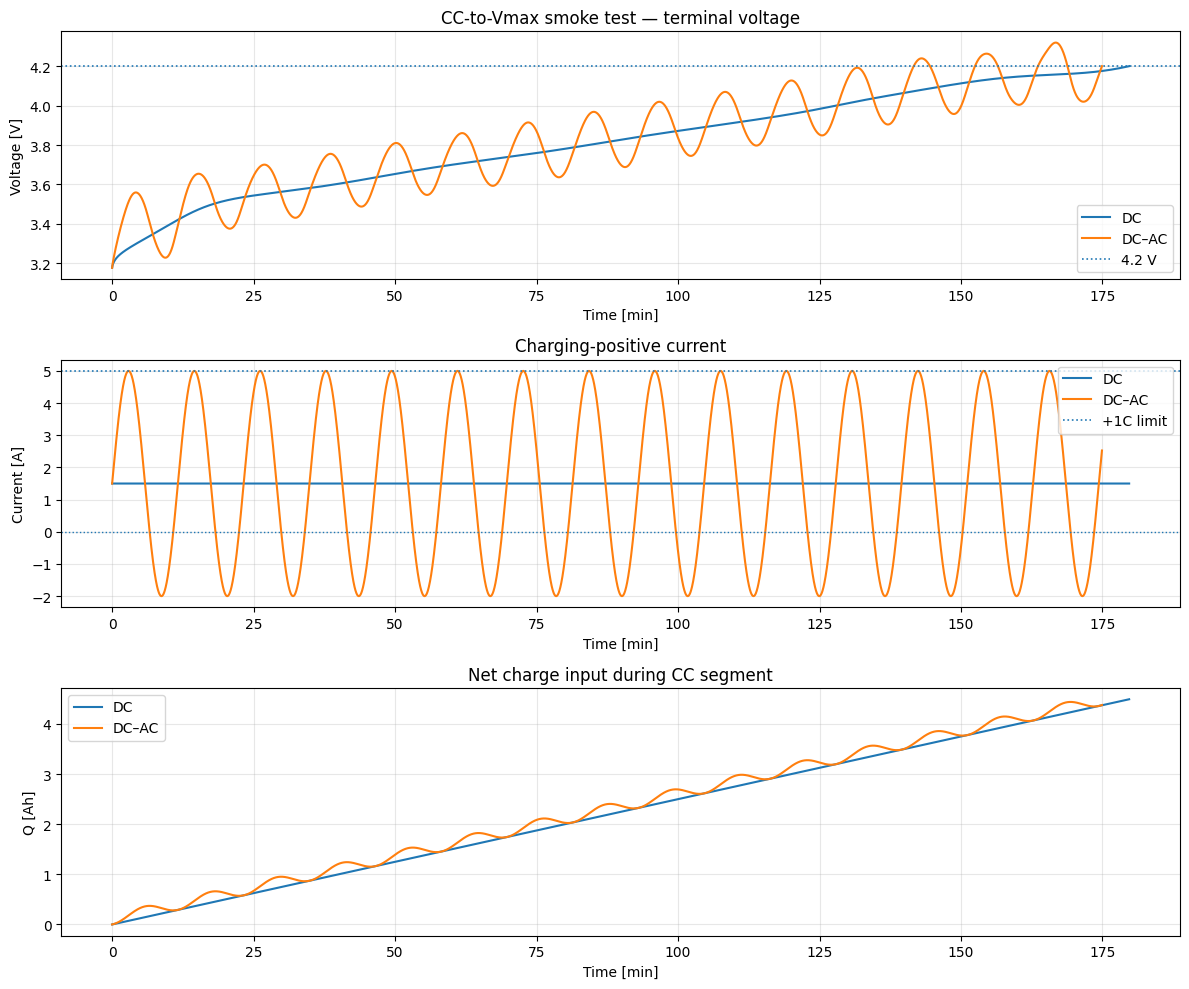

[OK] CC-to-Vmax smoke test completed.


In [9]:
# Cell 5 — Current-controlled CC-to-Vmax smoke test（电流控制CC段到4.2V冒烟测试）

def cumtrapz_np(y, x):
    """
    Minimal cumulative trapezoidal integration without scipy dependency.
    Returns integral array with the same length as x.
    """
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x, dtype=float)
    if len(x) < 2:
        return out
    dx = np.diff(x)
    avg_y = 0.5 * (y[1:] + y[:-1])
    out[1:] = np.cumsum(avg_y * dx)
    return out


def make_pybamm_current_function(dc_c, ac_c, frequency_hz, i_1c_a):
    """
    Return a PyBaMM-compatible callable current function.

    PyBaMM sign convention:
        positive current = discharge
        negative current = charge

    Charge-first experimental convention:
        I_chg(t) = I_DC + I_AC * sin(2*pi*f*t)

    Therefore:
        I_py(t) = -I_chg(t)
                = -I_DC - I_AC * sin(2*pi*f*t)
    """
    i_dc = float(dc_c) * float(i_1c_a)
    i_ac = float(ac_c) * float(i_1c_a)
    f = float(frequency_hz)

    def current_fun(t):
        return -i_dc - i_ac * pybamm.sin(2 * math.pi * f * t)

    return current_fun


def run_cc_to_vmax(
    parameter_set,
    protocol_label,
    dc_c,
    ac_c,
    frequency_hz,
    initial_soc=0.05,
    t_max_s=8 * 3600,
    dt_out_s=2.0,
):
    """
    Run a current-controlled PyBaMM DFN simulation until the model voltage event stops it.
    This is only the AC-on/DC current-controlled CC segment.

    Returns:
        summary dict,
        trajectory dataframe,
        PyBaMM solution
    """
    pv_base = PARAM_VALUES[parameter_set]
    pv = pv_base.copy()

    q_nom_ah = float(pv["Nominal cell capacity [A.h]"])
    i_1c_a = q_nom_ah

    current_fun = make_pybamm_current_function(
        dc_c=dc_c,
        ac_c=ac_c,
        frequency_hz=frequency_hz,
        i_1c_a=i_1c_a,
    )

    pv.update({"Current function [A]": current_fun})

    model = pybamm.lithium_ion.DFN()

    solver = pybamm.CasadiSolver(
        mode="safe",
        rtol=1e-6,
        atol=1e-8,
    )

    t_eval = np.arange(0, t_max_s + dt_out_s, dt_out_s)

    sim = pybamm.Simulation(
        model,
        parameter_values=pv,
        solver=solver,
    )

    try:
        sol = sim.solve(t_eval=t_eval, initial_soc=initial_soc)
        status = "ok"
        error_msg = ""
    except Exception as e:
        return (
            {
                "parameter_set": parameter_set,
                "protocol_label": protocol_label,
                "dc_c": dc_c,
                "ac_c": ac_c,
                "frequency_hz": frequency_hz,
                "initial_soc": initial_soc,
                "status": "failed",
                "error_msg": repr(e),
            },
            pd.DataFrame(),
            None,
        )

    t_s = np.asarray(sol.t, dtype=float)

    # Processed variables at solution time grid
    V = np.asarray(sol["Terminal voltage [V]"](t_s), dtype=float).reshape(-1)
    I_py = np.asarray(sol["Current [A]"](t_s), dtype=float).reshape(-1)

    # Charging-positive current
    I_chg = -I_py

    # Net charge input in Ah
    Q_Ah = cumtrapz_np(I_chg, t_s) / 3600.0

    df = pd.DataFrame({
        "parameter_set": parameter_set,
        "protocol_label": protocol_label,
        "t_s": t_s,
        "t_min": t_s / 60.0,
        "V_terminal_V": V,
        "I_py_A": I_py,
        "I_chg_A": I_chg,
        "Q_Ah": Q_Ah,
        "Q_frac_nominal": Q_Ah / q_nom_ah,
    })

    summary = {
        "parameter_set": parameter_set,
        "protocol_label": protocol_label,
        "dc_c": dc_c,
        "ac_c": ac_c,
        "frequency_hz": frequency_hz,
        "initial_soc": initial_soc,
        "Q_nom_Ah": q_nom_ah,
        "I_1C_A": i_1c_a,
        "t_stop_s": float(t_s[-1]),
        "t_stop_min": float(t_s[-1] / 60.0),
        "V_stop_V": float(V[-1]),
        "Q_stop_Ah": float(Q_Ah[-1]),
        "Q_stop_frac_nominal": float(Q_Ah[-1] / q_nom_ah),
        "I_chg_last_A": float(I_chg[-1]),
        "termination": str(getattr(sol, "termination", "")),
        "status": status,
        "error_msg": error_msg,
    }

    return summary, df, sol


# Smoke-test case: Chen2020, P01 0.3C DC vs 0.3C+0.7C 10tau
smoke_param = "Chen2020"
smoke_case = df_cfg.loc[df_cfg["pair_id"] == "P01_0p3DC_vs_0p3p0p7_10tau"].iloc[0].to_dict()

print("[smoke parameter set]", smoke_param)
print("[smoke case]", smoke_case["pair_id"])

summary_dc, df_dc_cc, sol_dc_cc = run_cc_to_vmax(
    parameter_set=smoke_param,
    protocol_label="DC_ref_CC_to_Vmax",
    dc_c=smoke_case["dc_ref_c"],
    ac_c=0.0,
    frequency_hz=smoke_case["frequency_hz"],
    initial_soc=0.05,
    t_max_s=8 * 3600,
    dt_out_s=2.0,
)

summary_dcac, df_dcac_cc, sol_dcac_cc = run_cc_to_vmax(
    parameter_set=smoke_param,
    protocol_label="DCAC_CC_to_Vmax",
    dc_c=smoke_case["dcac_dc_c"],
    ac_c=smoke_case["dcac_ac_c"],
    frequency_hz=smoke_case["frequency_hz"],
    initial_soc=0.05,
    t_max_s=8 * 3600,
    dt_out_s=2.0,
)

df_smoke_summary = pd.DataFrame([summary_dc, summary_dcac])
display(df_smoke_summary)

assert summary_dc["status"] == "ok", summary_dc["error_msg"]
assert summary_dcac["status"] == "ok", summary_dcac["error_msg"]

# Basic voltage event plausibility
assert summary_dc["V_stop_V"] >= 4.19, "DC branch did not reach upper voltage region."
assert summary_dcac["V_stop_V"] >= 4.19, "DCAC branch did not reach upper voltage region."

# Current reconstruction sanity: DCAC initial charging current should start at DC level
i_1c_smoke = summary_dcac["I_1C_A"]
expected_i0 = smoke_case["dcac_dc_c"] * i_1c_smoke
observed_i0 = float(df_dcac_cc["I_chg_A"].iloc[0])
print("[expected DCAC I_chg(0) A]", expected_i0)
print("[observed DCAC I_chg(0) A]", observed_i0)
assert np.isclose(observed_i0, expected_i0, rtol=1e-5, atol=1e-6)

# Plot audit
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)

axes[0].plot(df_dc_cc["t_min"], df_dc_cc["V_terminal_V"], label="DC")
axes[0].plot(df_dcac_cc["t_min"], df_dcac_cc["V_terminal_V"], label="DC–AC")
axes[0].axhline(4.2, linestyle=":", linewidth=1.2, label="4.2 V")
axes[0].set_title("CC-to-Vmax smoke test — terminal voltage")
axes[0].set_xlabel("Time [min]")
axes[0].set_ylabel("Voltage [V]")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="best")

axes[1].plot(df_dc_cc["t_min"], df_dc_cc["I_chg_A"], label="DC")
axes[1].plot(df_dcac_cc["t_min"], df_dcac_cc["I_chg_A"], label="DC–AC")
axes[1].axhline(i_1c_smoke, linestyle=":", linewidth=1.2, label="+1C limit")
axes[1].axhline(0.0, linestyle=":", linewidth=1.0)
axes[1].set_title("Charging-positive current")
axes[1].set_xlabel("Time [min]")
axes[1].set_ylabel("Current [A]")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="best")

axes[2].plot(df_dc_cc["t_min"], df_dc_cc["Q_Ah"], label="DC")
axes[2].plot(df_dcac_cc["t_min"], df_dcac_cc["Q_Ah"], label="DC–AC")
axes[2].set_title("Net charge input during CC segment")
axes[2].set_xlabel("Time [min]")
axes[2].set_ylabel("Q [Ah]")
axes[2].grid(True, alpha=0.3)
axes[2].legend(loc="best")

plt.tight_layout()
plt.show()

print("[OK] CC-to-Vmax smoke test completed.")

[MJ1 cutoff current A] 0.05
[MJ1 1C current A] 3.4
[cutoff C equivalent] 0.014705882352941178


,parameter_set,protocol_label,stage,status,error_msg,removed_events,cutoff_current_A,cutoff_C,t_cv_start_s,t_cv_start_min,t_end_s,t_end_min,V_end_V,I_chg_end_A,I_chg_end_C,Q_end_Ah,Q_end_frac_nominal,termination
0,Chen2020,DC_ref_CV,CV,ok,,Maximum voltage [V]; Maximum voltage switch [V],0.073529,0.014706,10782.817059,179.713618,13924.093545,232.068226,4.2,0.073539,0.014708,4.872670,0.974534,event: Charge current cutoff [A]
1,Chen2020,DCAC_CV_after_ACoff,CV,ok,,Maximum voltage [V]; Maximum voltage switch [V],0.073529,0.014706,10494.543245,174.909054,13889.522477,231.492041,4.2,0.073539,0.014708,4.872024,0.974405,event: Charge current cutoff [A]


,parameter_set,branch,t_vmax_min,Q_vmax_Ah,t_end_min,Q_end_Ah,I_end_A,I_end_C,termination
0,Chen2020,DC,179.713618,4.492840,232.068226,4.872670,0.073539,0.014708,event: Charge current cutoff [A]
1,Chen2020,DCAC,174.909054,4.377472,231.492041,4.872024,0.073539,0.014708,event: Charge current cutoff [A]


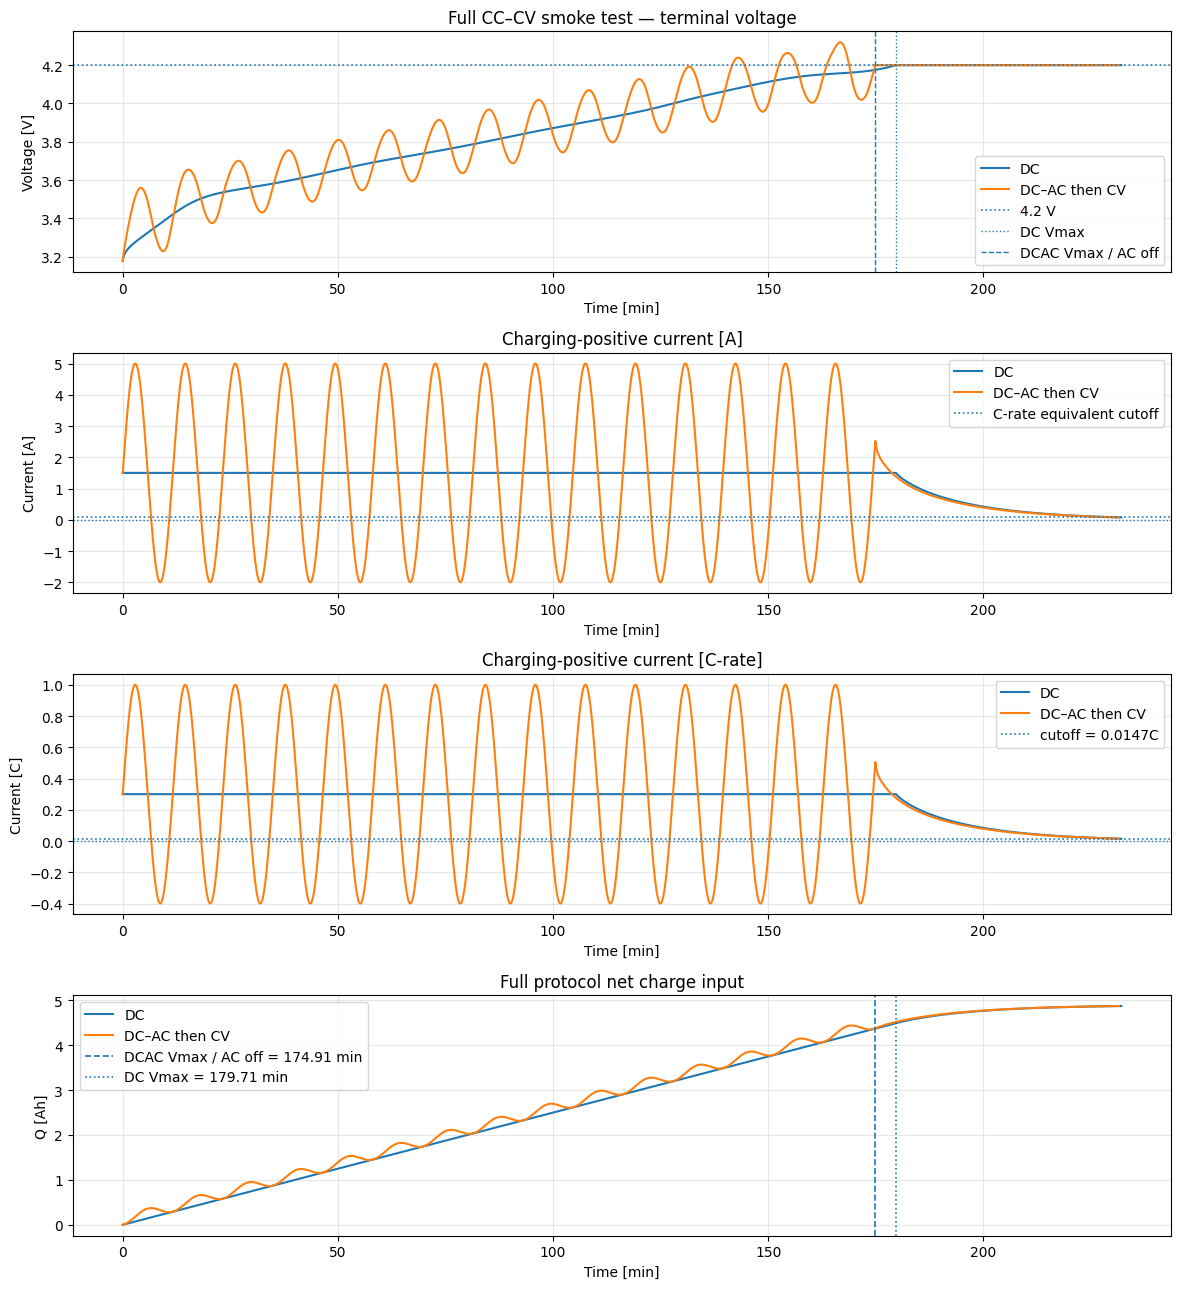

[OK] Full CC–CV continuation smoke test completed with normalized cutoff.


In [13]:
# Cell 6 — Full CC-CV continuation smoke test（完整CC-CV延续冒烟测试，v2：去除Vmax事件 + C-rate cutoff）

MJ1_I_1C_A = 3.4
MJ1_CUTOFF_A = 0.05
CUTOFF_C_EQUIV = MJ1_CUTOFF_A / MJ1_I_1C_A

print("[MJ1 cutoff current A]", MJ1_CUTOFF_A)
print("[MJ1 1C current A]", MJ1_I_1C_A)
print("[cutoff C equivalent]", CUTOFF_C_EQUIV)


def cutoff_current_a_for_parameter_set(parameter_set: str) -> float:
    """
    Use MJ1-equivalent cutoff C-rate for transferability audit.

    MJ1 experiment:
        I_cut = 0.05 A
        I_1C  = 3.4 A
        I_cut_C = 0.05 / 3.4 = 0.0147059 C

    For each PyBaMM parameter set:
        I_cut_A = I_cut_C * I_1C_parameter_set
    """
    i_1c_a = float(PARAM_VALUES[parameter_set]["Nominal cell capacity [A.h]"])
    return CUTOFF_C_EQUIV * i_1c_a


def apply_initial_conditions_from_solution(model, solution):
    """
    Set model initial conditions from the final state of a previous solution.

    This avoids Simulation.solve(starting_solution=...) because PyBaMM 26.3.1
    only allows starting_solution when simulating an Experiment.
    """
    try:
        out = model.set_initial_conditions_from(solution, inplace=True)
        if out is not None:
            model = out
    except TypeError:
        out = model.set_initial_conditions_from(solution)
        if out is not None:
            model = out
    return model


def remove_events_containing(model, substrings):
    """
    Remove events whose names contain any of the specified substrings.
    Needed for voltage-mode CV continuation because the model starts at Vmax.
    """
    kept = []
    removed = []

    for ev in model.events:
        name = getattr(ev, "name", "")
        if any(s in name for s in substrings):
            removed.append(name)
        else:
            kept.append(ev)

    model.events = kept
    return removed


def run_cv_from_vmax(
    parameter_set,
    protocol_label,
    sol_cc,
    t_cc_stop_s,
    q_cc_stop_ah,
    voltage_hold_v=4.2,
    cutoff_current_a=None,
    t_cv_max_s=4 * 3600,
    dt_out_s=2.0,
):
    """
    Continue from a current-controlled CC solution into voltage-controlled CV.

    PyBaMM sign convention:
        Current [A] < 0 means charging.

    CV cutoff:
        charging-positive current = -I_py <= cutoff_current_a

    Important:
        The built-in 'Maximum voltage [V]' event must be removed in voltage mode,
        otherwise the CV simulation terminates immediately at t=0 because it starts
        exactly at the voltage boundary.
    """
    pv_base = PARAM_VALUES[parameter_set]
    pv = pv_base.copy()
    pv.update({"Voltage function [V]": float(voltage_hold_v)})

    q_nom_ah = float(pv["Nominal cell capacity [A.h]"])
    i_1c_a = q_nom_ah

    if cutoff_current_a is None:
        cutoff_current_a = cutoff_current_a_for_parameter_set(parameter_set)

    cutoff_current_a = float(cutoff_current_a)
    cutoff_c = cutoff_current_a / i_1c_a

    try:
        model = pybamm.lithium_ion.DFN(options={"operating mode": "voltage"})
    except Exception as e:
        raise RuntimeError(f"Failed to create voltage-mode DFN: {e}")

    try:
        model = apply_initial_conditions_from_solution(model, sol_cc)
    except Exception as e:
        return (
            {
                "parameter_set": parameter_set,
                "protocol_label": protocol_label,
                "status": "failed",
                "error_msg": "set_initial_conditions_from failed: " + repr(e),
            },
            pd.DataFrame(),
            None,
        )

    # Critical fix: remove Vmax event for CV continuation
    removed_events = remove_events_containing(
        model,
        substrings=["Maximum voltage"],
    )

    # Add CV cutoff event
    try:
        current_py = model.variables["Current [A]"]
        cutoff_expr = -current_py - cutoff_current_a
        model.events.append(
            pybamm.Event(
                "Charge current cutoff [A]",
                cutoff_expr,
                pybamm.EventType.TERMINATION,
            )
        )
    except Exception as e:
        return (
            {
                "parameter_set": parameter_set,
                "protocol_label": protocol_label,
                "status": "failed",
                "error_msg": "CV cutoff event construction failed: " + repr(e),
            },
            pd.DataFrame(),
            None,
        )

    solver = pybamm.CasadiSolver(
        mode="safe",
        rtol=1e-6,
        atol=1e-8,
    )

    t_eval_rel = np.arange(
        0.0,
        float(t_cv_max_s + dt_out_s),
        float(dt_out_s),
    )

    sim = pybamm.Simulation(
        model,
        parameter_values=pv,
        solver=solver,
    )

    try:
        sol_cv = sim.solve(t_eval=t_eval_rel)
        status = "ok"
        error_msg = ""
    except Exception as e:
        return (
            {
                "parameter_set": parameter_set,
                "protocol_label": protocol_label,
                "status": "failed",
                "error_msg": repr(e),
                "removed_events": removed_events,
                "cutoff_current_A": cutoff_current_a,
                "cutoff_C": cutoff_c,
            },
            pd.DataFrame(),
            None,
        )

    t_rel_s = np.asarray(sol_cv.t, dtype=float)
    t_abs_s = float(t_cc_stop_s) + t_rel_s

    V = np.asarray(sol_cv["Terminal voltage [V]"](t_rel_s), dtype=float).reshape(-1)
    I_py = np.asarray(sol_cv["Current [A]"](t_rel_s), dtype=float).reshape(-1)
    I_chg = -I_py

    Q_cv_inc_Ah = cumtrapz_np(I_chg, t_rel_s) / 3600.0
    Q_Ah = float(q_cc_stop_ah) + (Q_cv_inc_Ah - Q_cv_inc_Ah[0])

    df_cv = pd.DataFrame({
        "parameter_set": parameter_set,
        "protocol_label": protocol_label,
        "stage": "CV",
        "t_rel_s": t_rel_s,
        "t_s": t_abs_s,
        "t_min": t_abs_s / 60.0,
        "V_terminal_V": V,
        "I_py_A": I_py,
        "I_chg_A": I_chg,
        "I_chg_C": I_chg / i_1c_a,
        "Q_Ah": Q_Ah,
        "Q_frac_nominal": Q_Ah / q_nom_ah,
    })

    summary = {
        "parameter_set": parameter_set,
        "protocol_label": protocol_label,
        "stage": "CV",
        "status": status,
        "error_msg": error_msg,
        "removed_events": "; ".join(removed_events),
        "cutoff_current_A": cutoff_current_a,
        "cutoff_C": cutoff_c,
        "t_cv_start_s": float(t_cc_stop_s),
        "t_cv_start_min": float(t_cc_stop_s / 60.0),
        "t_end_s": float(t_abs_s[-1]),
        "t_end_min": float(t_abs_s[-1] / 60.0),
        "V_end_V": float(V[-1]),
        "I_chg_end_A": float(I_chg[-1]),
        "I_chg_end_C": float(I_chg[-1] / i_1c_a),
        "Q_end_Ah": float(Q_Ah[-1]),
        "Q_end_frac_nominal": float(Q_Ah[-1] / q_nom_ah),
        "termination": str(getattr(sol_cv, "termination", "")),
    }

    return summary, df_cv, sol_cv


def combine_cc_cv(df_cc, df_cv):
    """
    Combine CC and CV trajectories into one full-protocol dataframe.
    Avoid duplicate boundary point if present.
    """
    df_cc2 = df_cc.copy()
    df_cc2["stage"] = "CC"

    q_nom_ah = float(PARAM_VALUES[df_cc2["parameter_set"].iloc[0]]["Nominal cell capacity [A.h]"])
    df_cc2["I_chg_C"] = df_cc2["I_chg_A"] / q_nom_ah

    if len(df_cv) == 0:
        return df_cc2

    t_last_cc = float(df_cc2["t_s"].iloc[-1])
    df_cv2 = df_cv.copy()
    df_cv2 = df_cv2[df_cv2["t_s"] > t_last_cc + 1e-9].copy()

    cols = [
        "parameter_set",
        "protocol_label",
        "stage",
        "t_s",
        "t_min",
        "V_terminal_V",
        "I_py_A",
        "I_chg_A",
        "I_chg_C",
        "Q_Ah",
        "Q_frac_nominal",
    ]

    return pd.concat(
        [df_cc2[cols], df_cv2[cols]],
        ignore_index=True,
    )


# Run corrected CV continuation
summary_dc_cv, df_dc_cv, sol_dc_cv = run_cv_from_vmax(
    parameter_set=smoke_param,
    protocol_label="DC_ref_CV",
    sol_cc=sol_dc_cc,
    t_cc_stop_s=summary_dc["t_stop_s"],
    q_cc_stop_ah=summary_dc["Q_stop_Ah"],
    cutoff_current_a=None,
    t_cv_max_s=4 * 3600,
    dt_out_s=2.0,
)

summary_dcac_cv, df_dcac_cv, sol_dcac_cv = run_cv_from_vmax(
    parameter_set=smoke_param,
    protocol_label="DCAC_CV_after_ACoff",
    sol_cc=sol_dcac_cc,
    t_cc_stop_s=summary_dcac["t_stop_s"],
    q_cc_stop_ah=summary_dcac["Q_stop_Ah"],
    cutoff_current_a=None,
    t_cv_max_s=4 * 3600,
    dt_out_s=2.0,
)

df_cv_summary = pd.DataFrame([summary_dc_cv, summary_dcac_cv])
display(df_cv_summary)

assert summary_dc_cv["status"] == "ok", summary_dc_cv["error_msg"]
assert summary_dcac_cv["status"] == "ok", summary_dcac_cv["error_msg"]

# Check actual CV continuation happened
assert summary_dc_cv["t_end_min"] > summary_dc_cv["t_cv_start_min"], "DC CV did not continue beyond Vmax"
assert summary_dcac_cv["t_end_min"] > summary_dcac_cv["t_cv_start_min"], "DCAC CV did not continue beyond Vmax"

# Check cutoff is reached approximately
assert summary_dc_cv["I_chg_end_A"] <= summary_dc_cv["cutoff_current_A"] * 1.02
assert summary_dcac_cv["I_chg_end_A"] <= summary_dcac_cv["cutoff_current_A"] * 1.02

# Combine full trajectories
df_dc_full = combine_cc_cv(df_dc_cc, df_dc_cv)
df_dcac_full = combine_cc_cv(df_dcac_cc, df_dcac_cv)

# Full protocol summary
df_full_smoke_summary = pd.DataFrame([
    {
        "parameter_set": smoke_param,
        "branch": "DC",
        "t_vmax_min": summary_dc["t_stop_min"],
        "Q_vmax_Ah": summary_dc["Q_stop_Ah"],
        "t_end_min": summary_dc_cv["t_end_min"],
        "Q_end_Ah": summary_dc_cv["Q_end_Ah"],
        "I_end_A": summary_dc_cv["I_chg_end_A"],
        "I_end_C": summary_dc_cv["I_chg_end_C"],
        "termination": summary_dc_cv["termination"],
    },
    {
        "parameter_set": smoke_param,
        "branch": "DCAC",
        "t_vmax_min": summary_dcac["t_stop_min"],
        "Q_vmax_Ah": summary_dcac["Q_stop_Ah"],
        "t_end_min": summary_dcac_cv["t_end_min"],
        "Q_end_Ah": summary_dcac_cv["Q_end_Ah"],
        "I_end_A": summary_dcac_cv["I_chg_end_A"],
        "I_end_C": summary_dcac_cv["I_chg_end_C"],
        "termination": summary_dcac_cv["termination"],
    },
])

display(df_full_smoke_summary)

# Plot full protocol audit
fig, axes = plt.subplots(4, 1, figsize=(12, 13), sharex=False)

axes[0].plot(df_dc_full["t_min"], df_dc_full["V_terminal_V"], label="DC")
axes[0].plot(df_dcac_full["t_min"], df_dcac_full["V_terminal_V"], label="DC–AC then CV")
axes[0].axhline(4.2, linestyle=":", linewidth=1.2, label="4.2 V")
axes[0].axvline(summary_dc["t_stop_min"], linestyle=":", linewidth=1.0, label="DC Vmax")
axes[0].axvline(summary_dcac["t_stop_min"], linestyle="--", linewidth=1.0, label="DCAC Vmax / AC off")
axes[0].set_title("Full CC–CV smoke test — terminal voltage")
axes[0].set_xlabel("Time [min]")
axes[0].set_ylabel("Voltage [V]")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="best")

axes[1].plot(df_dc_full["t_min"], df_dc_full["I_chg_A"], label="DC")
axes[1].plot(df_dcac_full["t_min"], df_dcac_full["I_chg_A"], label="DC–AC then CV")
axes[1].axhline(summary_dc_cv["cutoff_current_A"], linestyle=":", linewidth=1.2, label="C-rate equivalent cutoff")
axes[1].axhline(0.0, linestyle=":", linewidth=1.0)
axes[1].set_title("Charging-positive current [A]")
axes[1].set_xlabel("Time [min]")
axes[1].set_ylabel("Current [A]")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="best")

axes[2].plot(df_dc_full["t_min"], df_dc_full["I_chg_C"], label="DC")
axes[2].plot(df_dcac_full["t_min"], df_dcac_full["I_chg_C"], label="DC–AC then CV")
axes[2].axhline(CUTOFF_C_EQUIV, linestyle=":", linewidth=1.2, label=f"cutoff = {CUTOFF_C_EQUIV:.4f}C")
axes[2].axhline(0.0, linestyle=":", linewidth=1.0)
axes[2].set_title("Charging-positive current [C-rate]")
axes[2].set_xlabel("Time [min]")
axes[2].set_ylabel("Current [C]")
axes[2].grid(True, alpha=0.3)
axes[2].legend(loc="best")

axes[3].plot(df_dc_full["t_min"], df_dc_full["Q_Ah"], label="DC")
axes[3].plot(df_dcac_full["t_min"], df_dcac_full["Q_Ah"], label="DC–AC then CV")

axes[3].axvline(
    summary_dcac["t_stop_min"],
    linestyle="--",
    linewidth=1.2,
    label=f"DCAC Vmax / AC off = {summary_dcac['t_stop_min']:.2f} min",
)

axes[3].axvline(
    summary_dc["t_stop_min"],
    linestyle=":",
    linewidth=1.2,
    label=f"DC Vmax = {summary_dc['t_stop_min']:.2f} min",
)

axes[3].set_title("Full protocol net charge input")
axes[3].set_xlabel("Time [min]")
axes[3].set_ylabel("Q [Ah]")
axes[3].grid(True, alpha=0.3)
axes[3].legend(loc="best")

plt.tight_layout()
plt.show()

print("[OK] Full CC–CV continuation smoke test completed with normalized cutoff.")

,parameter_set,pair_id,Q_Ah,Q_frac_nominal_increment,SOC_est,t_DC_s,t_DCAC_s,t_DC_min,t_DCAC_min,delta_t_full_s,delta_t_full_min,control_state_DC,control_state_DCAC,segment_label
0,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,0.100000,0.020000,0.070000,240.000000,114.332832,4.000000,1.905547,125.667168,2.094453,CC,AC_on_CC,A_common_CC
1,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,0.134295,0.026859,0.076859,322.308335,140.684093,5.371806,2.344735,181.624242,3.027071,CC,AC_on_CC,A_common_CC
2,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,0.168590,0.033718,0.083718,404.616670,165.731617,6.743611,2.762194,238.885053,3.981418,CC,AC_on_CC,A_common_CC
3,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,0.202885,0.040577,0.090577,486.925005,190.470683,8.115417,3.174511,296.454322,4.940905,CC,AC_on_CC,A_common_CC
4,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,0.237181,0.047436,0.097436,569.233339,215.793075,9.487222,3.596551,353.440265,5.890671,CC,AC_on_CC,A_common_CC


,parameter_set,pair_id,Q_Ah,Q_frac_nominal_increment,SOC_est,t_DC_s,t_DCAC_s,t_DC_min,t_DCAC_min,delta_t_full_s,delta_t_full_min,control_state_DC,control_state_DCAC,segment_label
135,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,4.729844,0.945969,0.995969,11721.992016,11662.301039,195.366534,194.371684,59.690977,0.994850,CV,AC_off_CV,D_common_CV
136,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,4.764139,0.952828,1.002828,11976.832017,11922.717253,199.613867,198.711954,54.114764,0.901913,CV,AC_off_CV,D_common_CV
137,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,4.798434,0.959687,1.009687,12311.217373,12265.174221,205.186956,204.419570,46.043152,0.767386,CV,AC_off_CV,D_common_CV
138,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,4.832729,0.966546,1.016546,12795.402626,12761.871489,213.256710,212.697858,33.531137,0.558852,CV,AC_off_CV,D_common_CV
139,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,4.867024,0.973405,1.023405,13677.192369,13667.687471,227.953206,227.794791,9.504899,0.158415,CV,AC_off_CV,D_common_CV


,segment_label,n,Q_min_Ah,Q_max_Ah,SOC_min,SOC_max,dt_min_min,dt_mean_min,dt_max_min
0,A_common_CC,125,0.100000,4.352597,0.070000,0.920519,1.667160,5.445661,8.632525
1,B_boundary_transition,4,4.386892,4.489778,0.927378,0.947956,0.975218,4.651803,8.583019
2,D_common_CV,11,4.524073,4.867024,0.954815,1.023405,0.158415,0.911124,1.130821


,target,SOC_target,Q_target_Ah,t_DC_min,t_DCAC_min,delta_t_full_min,segment_label,control_state_DC,control_state_DCAC,status
0,SOC80,0.800000,3.750000,150.000000,143.415928,6.584072,A_common_CC,CC,AC_on_CC,ok
1,SOC90,0.900000,4.250000,170.000000,165.653367,4.346633,A_common_CC,CC,AC_on_CC,ok
2,SOC95,0.950000,4.500000,180.004915,178.919673,1.085242,D_common_CV,CV,AC_off_CV,ok
3,common_Q_end,1.024405,4.872024,231.580284,231.492041,0.088243,D_common_CV,CV,AC_off_CV,ok


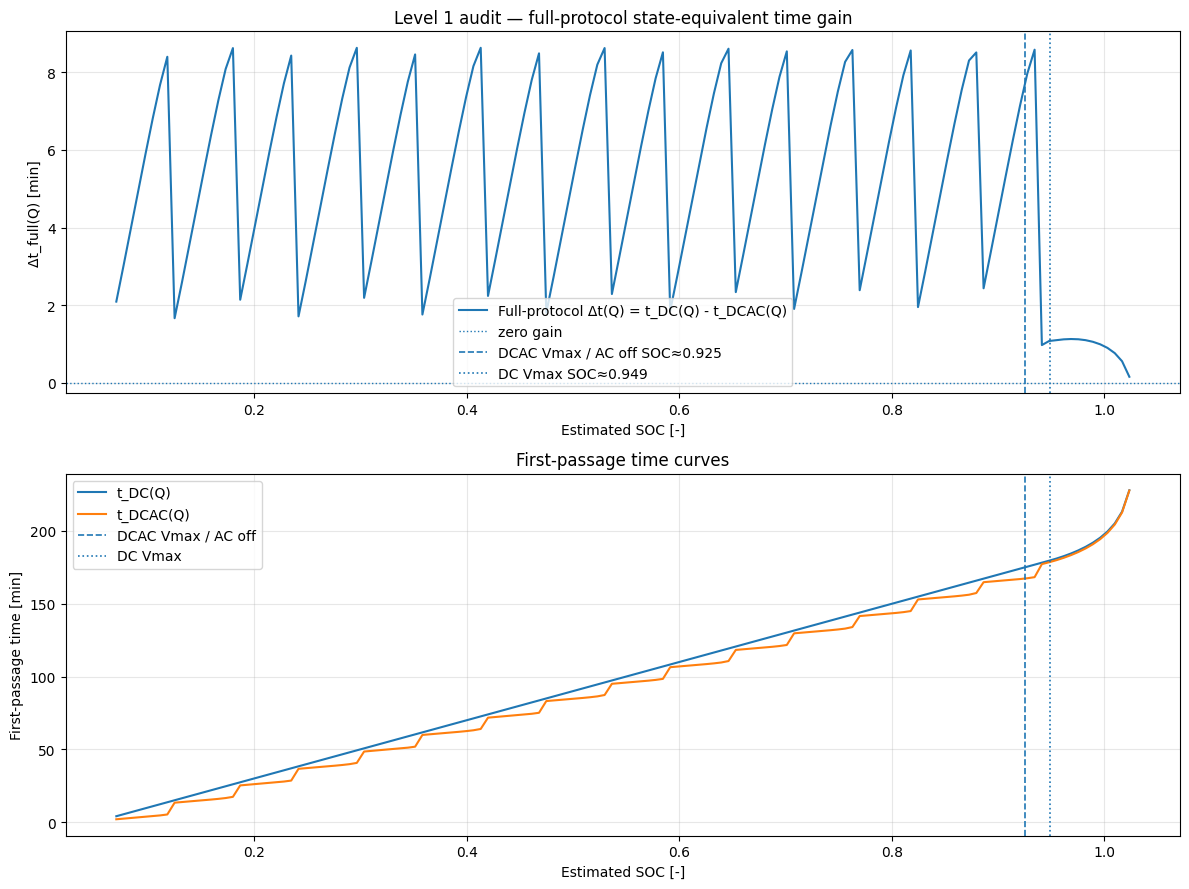

[OK] Full-protocol Δt(Q) Level 1 audit completed.


In [14]:
# Cell 7 — Full-protocol Δt(Q) curve / Level 1 audit（完整协议状态等效时间曲线）

def first_passage_time_from_Q(df, q_target_ah, q_col="Q_Ah", t_col="t_s"):
    """
    First-passage time:
        t(Q*) = inf{t | Q(t) >= Q*}

    Works with non-monotonic Q(t), because it uses the first sample
    at which the target is reached and linearly interpolates across
    the crossing interval.

    Returns np.nan if target is not reached.
    """
    q = np.asarray(df[q_col], dtype=float)
    t = np.asarray(df[t_col], dtype=float)

    hit = np.where(q >= q_target_ah)[0]
    if len(hit) == 0:
        return np.nan

    idx = int(hit[0])

    if idx == 0:
        return float(t[0])

    q0, q1 = q[idx - 1], q[idx]
    t0, t1 = t[idx - 1], t[idx]

    if np.isclose(q1, q0):
        return float(t1)

    alpha = (q_target_ah - q0) / (q1 - q0)
    return float(t0 + alpha * (t1 - t0))


def branch_control_state(q_target_ah, q_vmax_ah, branch):
    """
    Assign control state at first-passage Q target based on Vmax charge boundary.
    """
    if branch == "DC":
        return "CC" if q_target_ah <= q_vmax_ah else "CV"
    if branch == "DCAC":
        return "AC_on_CC" if q_target_ah <= q_vmax_ah else "AC_off_CV"
    raise ValueError(branch)


def segment_label_from_Q(q_target_ah, q_vmax_dc_ah, q_vmax_dcac_ah):
    """
    Segment labels for full-protocol audit.

    A/G0:
        both branches are still in prescribed-current CC.
    B/G1:
        one branch has reached Vmax but the other has not.
    D/G2:
        both branches are in voltage-limited / CV-related region.
    """
    q_low = min(q_vmax_dc_ah, q_vmax_dcac_ah)
    q_high = max(q_vmax_dc_ah, q_vmax_dcac_ah)

    if q_target_ah <= q_low:
        return "A_common_CC"
    elif q_target_ah <= q_high:
        return "B_boundary_transition"
    else:
        return "D_common_CV"


def compute_full_delta_t_curve(
    df_dc,
    df_dcac,
    q_nom_ah,
    initial_soc,
    q_vmax_dc_ah,
    q_vmax_dcac_ah,
    n_grid=140,
):
    """
    Compute full-protocol Δt(Q):

        Δt_full(Q) = t_DC(Q) - t_DCAC(Q)

    Positive Δt means DC–AC reaches the same net-charge target earlier.
    """
    q_end_dc = float(df_dc["Q_Ah"].iloc[-1])
    q_end_dcac = float(df_dcac["Q_Ah"].iloc[-1])
    q_common_end = min(q_end_dc, q_end_dcac)

    # Avoid the first few samples and the exact last endpoint.
    q_lo = max(0.02 * q_nom_ah, 0.02 * q_common_end)
    q_hi = q_common_end - 0.001 * q_nom_ah

    if q_hi <= q_lo:
        raise ValueError(f"Invalid Q grid: q_lo={q_lo}, q_hi={q_hi}")

    q_grid = np.linspace(q_lo, q_hi, n_grid)

    rows = []
    for q_target in q_grid:
        t_dc = first_passage_time_from_Q(df_dc, q_target)
        t_dcac = first_passage_time_from_Q(df_dcac, q_target)

        delta_t_s = t_dc - t_dcac

        rows.append({
            "parameter_set": smoke_param,
            "pair_id": smoke_case["pair_id"],
            "Q_Ah": q_target,
            "Q_frac_nominal_increment": q_target / q_nom_ah,
            "SOC_est": initial_soc + q_target / q_nom_ah,
            "t_DC_s": t_dc,
            "t_DCAC_s": t_dcac,
            "t_DC_min": t_dc / 60.0,
            "t_DCAC_min": t_dcac / 60.0,
            "delta_t_full_s": delta_t_s,
            "delta_t_full_min": delta_t_s / 60.0,
            "control_state_DC": branch_control_state(q_target, q_vmax_dc_ah, "DC"),
            "control_state_DCAC": branch_control_state(q_target, q_vmax_dcac_ah, "DCAC"),
            "segment_label": segment_label_from_Q(q_target, q_vmax_dc_ah, q_vmax_dcac_ah),
        })

    return pd.DataFrame(rows)


# Inputs from smoke test
q_nom_smoke = float(summary_dc["Q_nom_Ah"])
initial_soc_smoke = float(summary_dc["initial_soc"])

q_vmax_dc = float(summary_dc["Q_stop_Ah"])
q_vmax_dcac = float(summary_dcac["Q_stop_Ah"])

df_dt_full = compute_full_delta_t_curve(
    df_dc=df_dc_full,
    df_dcac=df_dcac_full,
    q_nom_ah=q_nom_smoke,
    initial_soc=initial_soc_smoke,
    q_vmax_dc_ah=q_vmax_dc,
    q_vmax_dcac_ah=q_vmax_dcac,
    n_grid=140,
)

display(df_dt_full.head())
display(df_dt_full.tail())

# Segment summary
df_segment_summary = (
    df_dt_full
    .groupby("segment_label")
    .agg(
        n=("Q_Ah", "size"),
        Q_min_Ah=("Q_Ah", "min"),
        Q_max_Ah=("Q_Ah", "max"),
        SOC_min=("SOC_est", "min"),
        SOC_max=("SOC_est", "max"),
        dt_min_min=("delta_t_full_min", "min"),
        dt_mean_min=("delta_t_full_min", "mean"),
        dt_max_min=("delta_t_full_min", "max"),
    )
    .reset_index()
)

display(df_segment_summary)

# Key targets: actual SOC 80%, 90%, 95%, and common end
target_soc_values = [0.80, 0.90, 0.95]
target_rows = []

for soc_target in target_soc_values:
    q_target = (soc_target - initial_soc_smoke) * q_nom_smoke

    if q_target <= 0 or q_target > min(df_dc_full["Q_Ah"].iloc[-1], df_dcac_full["Q_Ah"].iloc[-1]):
        target_rows.append({
            "target": f"SOC{int(soc_target*100)}",
            "SOC_target": soc_target,
            "Q_target_Ah": q_target,
            "status": "outside_common_Q_window",
        })
        continue

    t_dc = first_passage_time_from_Q(df_dc_full, q_target)
    t_dcac = first_passage_time_from_Q(df_dcac_full, q_target)

    target_rows.append({
        "target": f"SOC{int(soc_target*100)}",
        "SOC_target": soc_target,
        "Q_target_Ah": q_target,
        "t_DC_min": t_dc / 60.0,
        "t_DCAC_min": t_dcac / 60.0,
        "delta_t_full_min": (t_dc - t_dcac) / 60.0,
        "segment_label": segment_label_from_Q(q_target, q_vmax_dc, q_vmax_dcac),
        "control_state_DC": branch_control_state(q_target, q_vmax_dc, "DC"),
        "control_state_DCAC": branch_control_state(q_target, q_vmax_dcac, "DCAC"),
        "status": "ok",
    })

# Common-end target
q_common_end = min(float(df_dc_full["Q_Ah"].iloc[-1]), float(df_dcac_full["Q_Ah"].iloc[-1]))
t_dc_common_end = first_passage_time_from_Q(df_dc_full, q_common_end)
t_dcac_common_end = first_passage_time_from_Q(df_dcac_full, q_common_end)

target_rows.append({
    "target": "common_Q_end",
    "SOC_target": initial_soc_smoke + q_common_end / q_nom_smoke,
    "Q_target_Ah": q_common_end,
    "t_DC_min": t_dc_common_end / 60.0,
    "t_DCAC_min": t_dcac_common_end / 60.0,
    "delta_t_full_min": (t_dc_common_end - t_dcac_common_end) / 60.0,
    "segment_label": segment_label_from_Q(q_common_end, q_vmax_dc, q_vmax_dcac),
    "control_state_DC": branch_control_state(q_common_end, q_vmax_dc, "DC"),
    "control_state_DCAC": branch_control_state(q_common_end, q_vmax_dcac, "DCAC"),
    "status": "ok",
})

df_key_targets = pd.DataFrame(target_rows)
display(df_key_targets)

# Plot Δt(Q)
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=False)

axes[0].plot(
    df_dt_full["SOC_est"],
    df_dt_full["delta_t_full_min"],
    label="Full-protocol Δt(Q) = t_DC(Q) - t_DCAC(Q)",
)

axes[0].axhline(0.0, linestyle=":", linewidth=1.0, label="zero gain")

axes[0].axvline(
    initial_soc_smoke + q_vmax_dcac / q_nom_smoke,
    linestyle="--",
    linewidth=1.2,
    label=f"DCAC Vmax / AC off SOC≈{initial_soc_smoke + q_vmax_dcac/q_nom_smoke:.3f}",
)

axes[0].axvline(
    initial_soc_smoke + q_vmax_dc / q_nom_smoke,
    linestyle=":",
    linewidth=1.2,
    label=f"DC Vmax SOC≈{initial_soc_smoke + q_vmax_dc/q_nom_smoke:.3f}",
)

axes[0].set_title("Level 1 audit — full-protocol state-equivalent time gain")
axes[0].set_xlabel("Estimated SOC [-]")
axes[0].set_ylabel("Δt_full(Q) [min]")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="best")

# t(Q) comparison
axes[1].plot(
    df_dt_full["SOC_est"],
    df_dt_full["t_DC_min"],
    label="t_DC(Q)",
)

axes[1].plot(
    df_dt_full["SOC_est"],
    df_dt_full["t_DCAC_min"],
    label="t_DCAC(Q)",
)

axes[1].axvline(
    initial_soc_smoke + q_vmax_dcac / q_nom_smoke,
    linestyle="--",
    linewidth=1.2,
    label="DCAC Vmax / AC off",
)

axes[1].axvline(
    initial_soc_smoke + q_vmax_dc / q_nom_smoke,
    linestyle=":",
    linewidth=1.2,
    label="DC Vmax",
)

axes[1].set_title("First-passage time curves")
axes[1].set_xlabel("Estimated SOC [-]")
axes[1].set_ylabel("First-passage time [min]")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()

print("[OK] Full-protocol Δt(Q) Level 1 audit completed.")

,parameter_set,pair_id,Q_Ah,Q_frac_nominal_increment,SOC_nominal_est,t_DC_model_s,t_DCAC_model_s,delta_t_model_s,delta_t_model_min,t_DC_geom_s,t_DCAC_geom_s,delta_t_geom_s,delta_t_geom_min,delta_t_resid_s,delta_t_resid_min,q_window_lo_Ah,q_window_hi_Ah,q_margin_Ah,dt_geom_resolution_s
0,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,0.100000,0.020000,0.070000,240.000000,114.332832,125.667168,2.094453,240.000000,114.332668,125.667332,2.094456,-0.000164,-0.000003,0.1,4.277472,0.1,0.25
1,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,0.135105,0.027021,0.077021,324.251529,141.285950,182.965579,3.049426,324.251529,141.285292,182.966237,3.049437,-0.000658,-0.000011,0.1,4.277472,0.1,0.25
2,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,0.170210,0.034042,0.084042,408.503059,166.899617,241.603442,4.026724,408.503059,166.897858,241.605201,4.026753,-0.001759,-0.000029,0.1,4.277472,0.1,0.25
3,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,0.205314,0.041063,0.091063,492.754588,192.233920,300.520668,5.008678,492.754588,192.231244,300.523344,5.008722,-0.002676,-0.000045,0.1,4.277472,0.1,0.25
4,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,0.240419,0.048084,0.098084,577.006117,218.250612,358.755506,5.979258,577.006117,218.246965,358.759152,5.979319,-0.003646,-0.000061,0.1,4.277472,0.1,0.25


,parameter_set,pair_id,Q_Ah,Q_frac_nominal_increment,SOC_nominal_est,t_DC_model_s,t_DCAC_model_s,delta_t_model_s,delta_t_model_min,t_DC_geom_s,t_DCAC_geom_s,delta_t_geom_s,delta_t_geom_min,delta_t_resid_s,delta_t_resid_min,q_window_lo_Ah,q_window_hi_Ah,q_margin_Ah,dt_geom_resolution_s
115,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,4.137052,0.827410,0.877410,9928.925876,9411.137004,517.788872,8.629815,9928.925876,9411.114824,517.811052,8.630184,-0.022181,-0.000370,0.1,4.277472,0.1,0.25
116,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,4.172157,0.834431,0.884431,10013.177405,9881.421655,131.755751,2.195929,10013.177405,9881.421863,131.755543,2.195926,0.000208,0.000003,0.1,4.277472,0.1,0.25
117,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,4.207262,0.841452,0.891452,10097.428935,9908.168420,189.260515,3.154342,10097.428935,9908.167095,189.261840,3.154364,-0.001325,-0.000022,0.1,4.277472,0.1,0.25
118,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,4.242367,0.848473,0.898473,10181.680464,9933.704932,247.975532,4.132926,10181.680464,9933.702991,247.977473,4.132958,-0.001941,-0.000032,0.1,4.277472,0.1,0.25
119,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,4.277472,0.855494,0.905494,10265.931993,9959.065601,306.866392,5.114440,10265.931993,9959.062501,306.869492,5.114492,-0.003100,-0.000052,0.1,4.277472,0.1,0.25


,parameter_set,pair_id,dc_max_abs_Q_closure_mAh,dcac_max_abs_Q_closure_mAh,dc_final_Q_closure_mAh,dcac_final_Q_closure_mAh
0,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,0.0,0.005839,0.0,-0.000125


,parameter_set,pair_id,Q_window_lo_Ah,Q_window_hi_Ah,SOC_lo_nominal_est,SOC_hi_nominal_est,delta_t_model_min_min,delta_t_model_mean_min,delta_t_model_max_min,delta_t_geom_min_min,delta_t_geom_mean_min,delta_t_geom_max_min,delta_t_resid_min_s,delta_t_resid_mean_s,delta_t_resid_max_s,delta_t_resid_max_abs_s
0,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,0.1,4.277472,0.07,0.905494,1.631336,5.441998,8.633043,1.631316,5.4421,8.633296,-0.147226,-0.006169,0.001198,0.147226


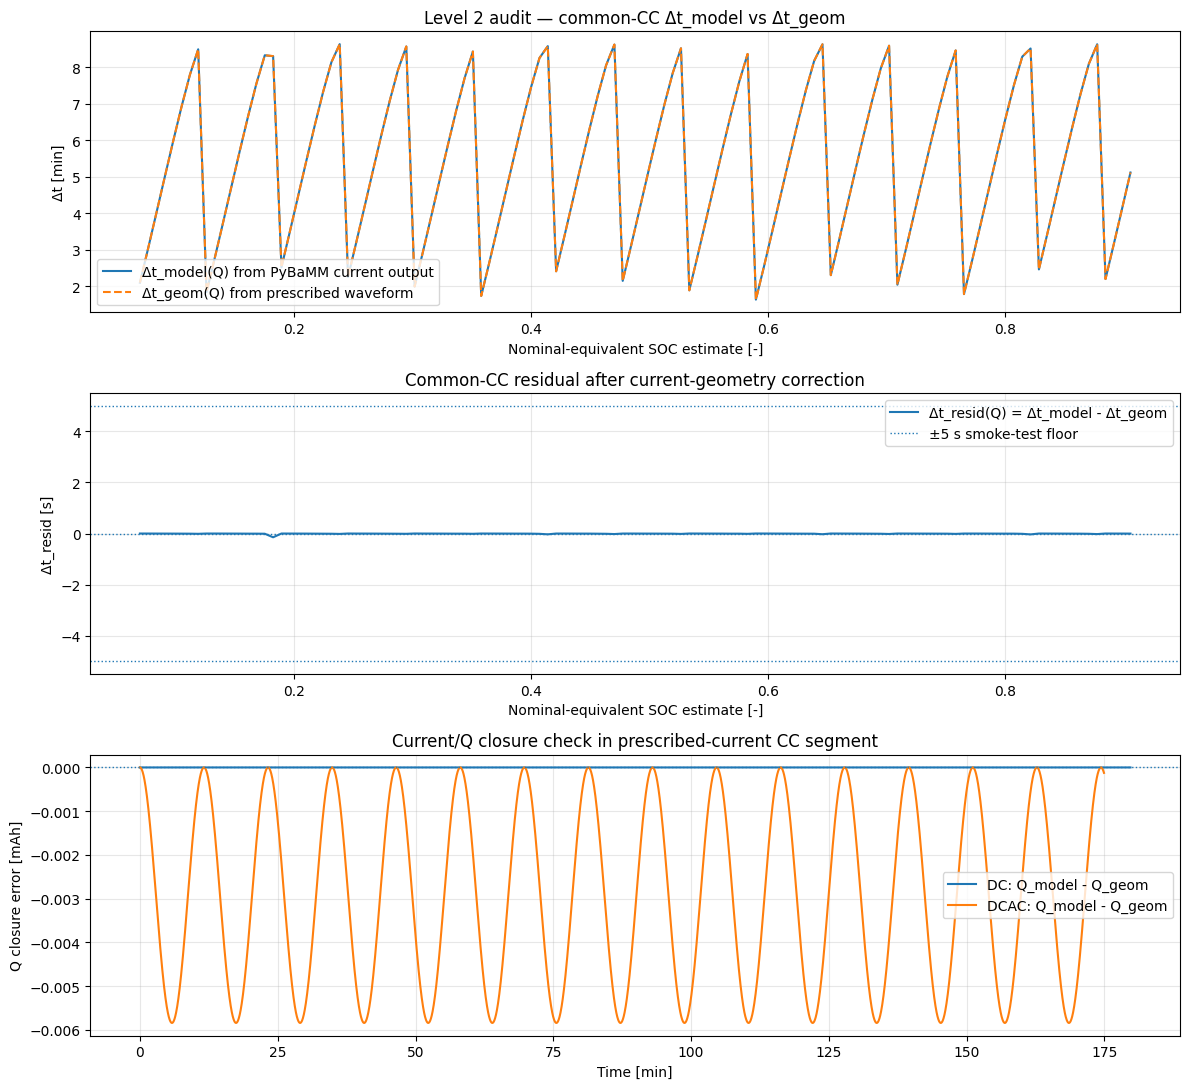

[Level 2 verdict] PASS: common-CC Δt is geometry-dominated within smoke-test floor.
[max |Δt_resid| s] 0.1472256464453494
[OK] Common-CC geometry/residual Level 2 audit completed.


In [16]:
# Cell 8 — Common-CC geometry/residual audit / Level 2（共同CC区几何项与残差审计）

def exact_q_geom_dc(t_s, dc_c, i_1c_a):
    """
    Exact geometry Q(t) for DC charging-positive current.
    Q in Ah.
    """
    t_s = np.asarray(t_s, dtype=float)
    i_dc = float(dc_c) * float(i_1c_a)
    return i_dc * t_s / 3600.0


def exact_q_geom_dcac(t_s, dc_c, ac_c, frequency_hz, i_1c_a):
    """
    Exact geometry Q(t) for charge-first DC–AC charging-positive current:

        I_chg(t) = I_DC + I_AC sin(2*pi*f*t)

    Integral:
        Q(t) = [I_DC*t + I_AC/(2*pi*f)*(1 - cos(2*pi*f*t))] / 3600
    """
    t_s = np.asarray(t_s, dtype=float)
    i_dc = float(dc_c) * float(i_1c_a)
    i_ac = float(ac_c) * float(i_1c_a)
    f = float(frequency_hz)
    omega = 2 * math.pi * f

    return (i_dc * t_s + (i_ac / omega) * (1.0 - np.cos(omega * t_s))) / 3600.0


def build_geometry_df(branch, dc_c, ac_c, frequency_hz, i_1c_a, t_end_s, dt_s=0.25):
    """
    Build high-resolution geometry-only trajectory.
    No voltage, no PyBaMM state, no event logic.
    """
    t_s = np.arange(0.0, float(t_end_s) + float(dt_s), float(dt_s))

    if branch == "DC":
        q_ah = exact_q_geom_dc(t_s, dc_c=dc_c, i_1c_a=i_1c_a)
        i_chg = dc_c * i_1c_a * np.ones_like(t_s)
    elif branch == "DCAC":
        q_ah = exact_q_geom_dcac(
            t_s,
            dc_c=dc_c,
            ac_c=ac_c,
            frequency_hz=frequency_hz,
            i_1c_a=i_1c_a,
        )
        i_chg = dcac_current_chg_positive(
            t_s,
            dc_c=dc_c,
            ac_c=ac_c,
            frequency_hz=frequency_hz,
            i_1c_a=i_1c_a,
        )
    else:
        raise ValueError(branch)

    return pd.DataFrame({
        "branch": branch,
        "t_s": t_s,
        "t_min": t_s / 60.0,
        "I_chg_A": i_chg,
        "Q_Ah": q_ah,
    })


def compute_cc_geometry_residual(
    df_dc_cc,
    df_dcac_cc,
    q_nom_ah,
    initial_soc,
    q_vmax_dc_ah,
    q_vmax_dcac_ah,
    dc_ref_c,
    dcac_dc_c,
    dcac_ac_c,
    frequency_hz,
    i_1c_a,
    n_grid=120,
    q_margin_frac=0.02,
    dt_geom_grid_s=0.25,
):
    """
    Compute Level 2 common-CC decomposition:

        Δt_model(Q) = t_DC_model(Q) - t_DCAC_model(Q)
        Δt_geom(Q)  = t_DC_geom(Q)  - t_DCAC_geom(Q)
        Δt_resid(Q) = Δt_model(Q) - Δt_geom(Q)

    Valid only for:
        Q <= min(Q_Vmax_DC, Q_Vmax_DCAC) - margin
    """
    q_margin_ah = q_margin_frac * q_nom_ah
    q_hi = min(q_vmax_dc_ah, q_vmax_dcac_ah) - q_margin_ah
    q_lo = max(0.02 * q_nom_ah, 0.02 * q_hi)

    if q_hi <= q_lo:
        raise ValueError(f"Invalid common-CC Q window: q_lo={q_lo}, q_hi={q_hi}")

    # Geometry trajectories need to extend beyond the last target first-passage.
    # Use CC stop times plus a small margin.
    t_end_geom = max(
        float(df_dc_cc["t_s"].iloc[-1]),
        float(df_dcac_cc["t_s"].iloc[-1]),
    ) + 60.0

    df_geom_dc = build_geometry_df(
        branch="DC",
        dc_c=dc_ref_c,
        ac_c=0.0,
        frequency_hz=frequency_hz,
        i_1c_a=i_1c_a,
        t_end_s=t_end_geom,
        dt_s=dt_geom_grid_s,
    )

    df_geom_dcac = build_geometry_df(
        branch="DCAC",
        dc_c=dcac_dc_c,
        ac_c=dcac_ac_c,
        frequency_hz=frequency_hz,
        i_1c_a=i_1c_a,
        t_end_s=t_end_geom,
        dt_s=dt_geom_grid_s,
    )

    q_grid = np.linspace(q_lo, q_hi, n_grid)

    rows = []
    for q_target in q_grid:
        t_dc_model = first_passage_time_from_Q(df_dc_cc, q_target)
        t_dcac_model = first_passage_time_from_Q(df_dcac_cc, q_target)

        t_dc_geom = first_passage_time_from_Q(df_geom_dc, q_target)
        t_dcac_geom = first_passage_time_from_Q(df_geom_dcac, q_target)

        dt_model_s = t_dc_model - t_dcac_model
        delta_t_geom_s = t_dc_geom - t_dcac_geom
        dt_resid_s = dt_model_s - delta_t_geom_s

        rows.append({
            "parameter_set": smoke_param,
            "pair_id": smoke_case["pair_id"],
            "Q_Ah": q_target,
            "Q_frac_nominal_increment": q_target / q_nom_ah,
            "SOC_nominal_est": initial_soc + q_target / q_nom_ah,
            "t_DC_model_s": t_dc_model,
            "t_DCAC_model_s": t_dcac_model,
            "delta_t_model_s": dt_model_s,
            "delta_t_model_min": dt_model_s / 60.0,
            "t_DC_geom_s": t_dc_geom,
            "t_DCAC_geom_s": t_dcac_geom,
            "delta_t_geom_s": delta_t_geom_s,
            "delta_t_geom_min": delta_t_geom_s / 60.0,
            "delta_t_resid_s": dt_resid_s,
            "delta_t_resid_min": dt_resid_s / 60.0,
            "q_window_lo_Ah": q_lo,
            "q_window_hi_Ah": q_hi,
            "q_margin_Ah": q_margin_ah,
            "dt_geom_resolution_s": dt_geom_grid_s,
        })

    return pd.DataFrame(rows), df_geom_dc, df_geom_dcac


# Inputs
i_1c_smoke = float(summary_dc["I_1C_A"])

df_cc_resid_smoke, df_geom_dc_smoke, df_geom_dcac_smoke = compute_cc_geometry_residual(
    df_dc_cc=df_dc_cc,
    df_dcac_cc=df_dcac_cc,
    q_nom_ah=q_nom_smoke,
    initial_soc=initial_soc_smoke,
    q_vmax_dc_ah=q_vmax_dc,
    q_vmax_dcac_ah=q_vmax_dcac,
    dc_ref_c=smoke_case["dc_ref_c"],
    dcac_dc_c=smoke_case["dcac_dc_c"],
    dcac_ac_c=smoke_case["dcac_ac_c"],
    frequency_hz=smoke_case["frequency_hz"],
    i_1c_a=i_1c_smoke,
    n_grid=120,
    q_margin_frac=0.02,
    dt_geom_grid_s=0.25,
)

display(df_cc_resid_smoke.head())
display(df_cc_resid_smoke.tail())

# Current / Q closure check between PyBaMM output-integrated Q and exact prescribed geometry at same times
q_dc_exact_at_model_t = exact_q_geom_dc(
    df_dc_cc["t_s"].values,
    dc_c=smoke_case["dc_ref_c"],
    i_1c_a=i_1c_smoke,
)

q_dcac_exact_at_model_t = exact_q_geom_dcac(
    df_dcac_cc["t_s"].values,
    dc_c=smoke_case["dcac_dc_c"],
    ac_c=smoke_case["dcac_ac_c"],
    frequency_hz=smoke_case["frequency_hz"],
    i_1c_a=i_1c_smoke,
)

dc_q_closure_Ah = df_dc_cc["Q_Ah"].values - q_dc_exact_at_model_t
dcac_q_closure_Ah = df_dcac_cc["Q_Ah"].values - q_dcac_exact_at_model_t

closure_summary = {
    "parameter_set": smoke_param,
    "pair_id": smoke_case["pair_id"],
    "dc_max_abs_Q_closure_mAh": float(np.max(np.abs(dc_q_closure_Ah)) * 1000),
    "dcac_max_abs_Q_closure_mAh": float(np.max(np.abs(dcac_q_closure_Ah)) * 1000),
    "dc_final_Q_closure_mAh": float(dc_q_closure_Ah[-1] * 1000),
    "dcac_final_Q_closure_mAh": float(dcac_q_closure_Ah[-1] * 1000),
}

df_closure_summary = pd.DataFrame([closure_summary])
display(df_closure_summary)

# Residual summary
df_cc_resid_summary = pd.DataFrame([{
    "parameter_set": smoke_param,
    "pair_id": smoke_case["pair_id"],
    "Q_window_lo_Ah": float(df_cc_resid_smoke["q_window_lo_Ah"].iloc[0]),
    "Q_window_hi_Ah": float(df_cc_resid_smoke["q_window_hi_Ah"].iloc[0]),
    "SOC_lo_nominal_est": float(df_cc_resid_smoke["SOC_nominal_est"].min()),
    "SOC_hi_nominal_est": float(df_cc_resid_smoke["SOC_nominal_est"].max()),
    "delta_t_model_min_min": float(df_cc_resid_smoke["delta_t_model_min"].min()),
    "delta_t_model_mean_min": float(df_cc_resid_smoke["delta_t_model_min"].mean()),
    "delta_t_model_max_min": float(df_cc_resid_smoke["delta_t_model_min"].max()),
    "delta_t_geom_min_min": float(df_cc_resid_smoke["delta_t_geom_min"].min()),
    "delta_t_geom_mean_min": float(df_cc_resid_smoke["delta_t_geom_min"].mean()),
    "delta_t_geom_max_min": float(df_cc_resid_smoke["delta_t_geom_min"].max()),
    "delta_t_resid_min_s": float(df_cc_resid_smoke["delta_t_resid_s"].min()),
    "delta_t_resid_mean_s": float(df_cc_resid_smoke["delta_t_resid_s"].mean()),
    "delta_t_resid_max_s": float(df_cc_resid_smoke["delta_t_resid_s"].max()),
    "delta_t_resid_max_abs_s": float(np.max(np.abs(df_cc_resid_smoke["delta_t_resid_s"]))),
}])

display(df_cc_resid_summary)

# Plot Level 2 audit
fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=False)

axes[0].plot(
    df_cc_resid_smoke["SOC_nominal_est"],
    df_cc_resid_smoke["delta_t_model_min"],
    label="Δt_model(Q) from PyBaMM current output",
)

axes[0].plot(
    df_cc_resid_smoke["SOC_nominal_est"],
    df_cc_resid_smoke["delta_t_geom_min"],
    linestyle="--",
    label="Δt_geom(Q) from prescribed waveform",
)

axes[0].set_title("Level 2 audit — common-CC Δt_model vs Δt_geom")
axes[0].set_xlabel("Nominal-equivalent SOC estimate [-]")
axes[0].set_ylabel("Δt [min]")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="best")

axes[1].plot(
    df_cc_resid_smoke["SOC_nominal_est"],
    df_cc_resid_smoke["delta_t_resid_s"],
    label="Δt_resid(Q) = Δt_model - Δt_geom",
)

axes[1].axhline(0.0, linestyle=":", linewidth=1.0)
axes[1].axhline(5.0, linestyle=":", linewidth=1.0, label="±5 s smoke-test floor")
axes[1].axhline(-5.0, linestyle=":", linewidth=1.0)
axes[1].set_title("Common-CC residual after current-geometry correction")
axes[1].set_xlabel("Nominal-equivalent SOC estimate [-]")
axes[1].set_ylabel("Δt_resid [s]")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="best")

axes[2].plot(
    df_dc_cc["t_min"],
    dc_q_closure_Ah * 1000,
    label="DC: Q_model - Q_geom",
)

axes[2].plot(
    df_dcac_cc["t_min"],
    dcac_q_closure_Ah * 1000,
    label="DCAC: Q_model - Q_geom",
)

axes[2].axhline(0.0, linestyle=":", linewidth=1.0)
axes[2].set_title("Current/Q closure check in prescribed-current CC segment")
axes[2].set_xlabel("Time [min]")
axes[2].set_ylabel("Q closure error [mAh]")
axes[2].grid(True, alpha=0.3)
axes[2].legend(loc="best")

plt.tight_layout()
plt.show()

# Soft verdict
resid_max_abs_s = float(np.max(np.abs(df_cc_resid_smoke["delta_t_resid_s"])))
if resid_max_abs_s <= 5.0:
    verdict = "PASS: common-CC Δt is geometry-dominated within smoke-test floor."
else:
    verdict = "CHECK: residual exceeds smoke-test floor; inspect Q closure, time grid, and interpolation."

print("[Level 2 verdict]", verdict)
print("[max |Δt_resid| s]", resid_max_abs_s)
print("[OK] Common-CC geometry/residual Level 2 audit completed.")

,parameter_set,pair_id,Q_Ah,Q_frac_nominal_increment,SOC_est,t_DC_s,t_DCAC_s,t_DC_min,t_DCAC_min,delta_t_full_s,delta_t_full_min,control_state_DC,control_state_DCAC,segment_label,control_state_DC_timebased,control_state_DCAC_timebased,segment_label_timebased,segment_label_old_Qbased,control_state_DC_old_Qbased,control_state_DCAC_old_Qbased
0,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,0.100000,0.020000,0.070000,240.000000,114.332832,4.000000,1.905547,125.667168,2.094453,CC,AC_on_CC,A_common_CC,CC,AC_on_CC,A_common_prescribed_CC,A_common_CC,CC,AC_on_CC
1,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,0.134295,0.026859,0.076859,322.308335,140.684093,5.371806,2.344735,181.624242,3.027071,CC,AC_on_CC,A_common_CC,CC,AC_on_CC,A_common_prescribed_CC,A_common_CC,CC,AC_on_CC
2,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,0.168590,0.033718,0.083718,404.616670,165.731617,6.743611,2.762194,238.885053,3.981418,CC,AC_on_CC,A_common_CC,CC,AC_on_CC,A_common_prescribed_CC,A_common_CC,CC,AC_on_CC
3,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,0.202885,0.040577,0.090577,486.925005,190.470683,8.115417,3.174511,296.454322,4.940905,CC,AC_on_CC,A_common_CC,CC,AC_on_CC,A_common_prescribed_CC,A_common_CC,CC,AC_on_CC
4,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,0.237181,0.047436,0.097436,569.233339,215.793075,9.487222,3.596551,353.440265,5.890671,CC,AC_on_CC,A_common_CC,CC,AC_on_CC,A_common_prescribed_CC,A_common_CC,CC,AC_on_CC


,parameter_set,pair_id,Q_Ah,Q_frac_nominal_increment,SOC_est,t_DC_s,t_DCAC_s,t_DC_min,t_DCAC_min,delta_t_full_s,delta_t_full_min,control_state_DC,control_state_DCAC,segment_label,control_state_DC_timebased,control_state_DCAC_timebased,segment_label_timebased,segment_label_old_Qbased,control_state_DC_old_Qbased,control_state_DCAC_old_Qbased
135,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,4.729844,0.945969,0.995969,11721.992016,11662.301039,195.366534,194.371684,59.690977,0.994850,CV,AC_off_CV,D_common_CV,CV,AC_off_CV,D_common_CV,D_common_CV,CV,AC_off_CV
136,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,4.764139,0.952828,1.002828,11976.832017,11922.717253,199.613867,198.711954,54.114764,0.901913,CV,AC_off_CV,D_common_CV,CV,AC_off_CV,D_common_CV,D_common_CV,CV,AC_off_CV
137,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,4.798434,0.959687,1.009687,12311.217373,12265.174221,205.186956,204.419570,46.043152,0.767386,CV,AC_off_CV,D_common_CV,CV,AC_off_CV,D_common_CV,D_common_CV,CV,AC_off_CV
138,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,4.832729,0.966546,1.016546,12795.402626,12761.871489,213.256710,212.697858,33.531137,0.558852,CV,AC_off_CV,D_common_CV,CV,AC_off_CV,D_common_CV,D_common_CV,CV,AC_off_CV
139,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,4.867024,0.973405,1.023405,13677.192369,13667.687471,227.953206,227.794791,9.504899,0.158415,CV,AC_off_CV,D_common_CV,CV,AC_off_CV,D_common_CV,D_common_CV,CV,AC_off_CV


,branch,t_vmax_min,Q_at_Vmax_Ah,Q_frontier_pre_Vmax_Ah,Q_frontier_minus_Q_at_Vmax_mAh,t_frontier_min,frontier_before_or_at_Vmax
0,DC,179.713618,4.492840,4.49284,0.00000,179.713618,True
1,DCAC,174.909054,4.377472,4.43956,62.08878,169.366667,True


segment_label_timebased,A_common_prescribed_CC,B_DCAC_CV__DC_CC,D_common_CV
segment_label_old_Qbased,,,
A_common_CC,125,0,0
B_boundary_transition,2,2,0
D_common_CV,0,0,11


,segment_label_timebased,n,Q_min_Ah,Q_max_Ah,SOC_min,SOC_max,t_DC_min_min,t_DC_min_max,t_DCAC_min_min,t_DCAC_min_max,dt_min_min,dt_mean_min,dt_max_min
0,A_common_prescribed_CC,127,0.100000,4.421188,0.070000,0.934238,4.000000,176.847503,1.905547,168.264484,1.667160,5.490234,8.632525
1,B_DCAC_CV__DC_CC,2,4.455483,4.489778,0.941097,0.947956,178.219309,179.591114,177.244091,178.511148,0.975218,1.027592,1.079967
2,D_common_CV,11,4.524073,4.867024,0.954815,1.023405,181.045701,227.953206,179.943121,227.794791,0.158415,0.911124,1.130821


,parameter_set,pair_id,Q_Ah,Q_frac_nominal_increment,SOC_est,t_DC_s,t_DCAC_s,t_DC_min,t_DCAC_min,delta_t_full_s,...,control_state_DCAC_timebased,segment_label_timebased,segment_label_old_Qbased,control_state_DC_old_Qbased,control_state_DCAC_old_Qbased,segment_start_Q_Ah,segment_start_SOC_est,segment_start_delta_t_min,delta_t_incremental_min,delta_t_incremental_s
0,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,0.100000,0.020000,0.070000,240.000000,114.332832,4.000000,1.905547,125.667168,...,AC_on_CC,A_common_prescribed_CC,A_common_CC,CC,AC_on_CC,0.1,0.07,2.094453,0.000000,0.000000
1,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,0.134295,0.026859,0.076859,322.308335,140.684093,5.371806,2.344735,181.624242,...,AC_on_CC,A_common_prescribed_CC,A_common_CC,CC,AC_on_CC,0.1,0.07,2.094453,0.932618,55.957074
2,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,0.168590,0.033718,0.083718,404.616670,165.731617,6.743611,2.762194,238.885053,...,AC_on_CC,A_common_prescribed_CC,A_common_CC,CC,AC_on_CC,0.1,0.07,2.094453,1.886965,113.217885
3,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,0.202885,0.040577,0.090577,486.925005,190.470683,8.115417,3.174511,296.454322,...,AC_on_CC,A_common_prescribed_CC,A_common_CC,CC,AC_on_CC,0.1,0.07,2.094453,2.846453,170.787154
4,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,0.237181,0.047436,0.097436,569.233339,215.793075,9.487222,3.596551,353.440265,...,AC_on_CC,A_common_prescribed_CC,A_common_CC,CC,AC_on_CC,0.1,0.07,2.094453,3.796218,227.773097


,parameter_set,pair_id,Q_Ah,Q_frac_nominal_increment,SOC_est,t_DC_s,t_DCAC_s,t_DC_min,t_DCAC_min,delta_t_full_s,...,control_state_DCAC_timebased,segment_label_timebased,segment_label_old_Qbased,control_state_DC_old_Qbased,control_state_DCAC_old_Qbased,segment_start_Q_Ah,segment_start_SOC_est,segment_start_delta_t_min,delta_t_incremental_min,delta_t_incremental_s
135,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,4.729844,0.945969,0.995969,11721.992016,11662.301039,195.366534,194.371684,59.690977,...,AC_off_CV,D_common_CV,D_common_CV,CV,AC_off_CV,4.524073,0.954815,1.10258,-0.107731,-6.463833
136,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,4.764139,0.952828,1.002828,11976.832017,11922.717253,199.613867,198.711954,54.114764,...,AC_off_CV,D_common_CV,D_common_CV,CV,AC_off_CV,4.524073,0.954815,1.10258,-0.200667,-12.040047
137,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,4.798434,0.959687,1.009687,12311.217373,12265.174221,205.186956,204.419570,46.043152,...,AC_off_CV,D_common_CV,D_common_CV,CV,AC_off_CV,4.524073,0.954815,1.10258,-0.335194,-20.111659
138,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,4.832729,0.966546,1.016546,12795.402626,12761.871489,213.256710,212.697858,33.531137,...,AC_off_CV,D_common_CV,D_common_CV,CV,AC_off_CV,4.524073,0.954815,1.10258,-0.543728,-32.623674
139,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,4.867024,0.973405,1.023405,13677.192369,13667.687471,227.953206,227.794791,9.504899,...,AC_off_CV,D_common_CV,D_common_CV,CV,AC_off_CV,4.524073,0.954815,1.10258,-0.944165,-56.649912


,segment_label_timebased,n,Q_start_Ah,Q_end_Ah,SOC_start,SOC_end,delta_t_start_min,delta_t_end_min,segment_incremental_delta_t_min,segment_incremental_delta_t_s,verdict
0,A_common_prescribed_CC,127,0.100000,4.421188,0.070000,0.934238,2.094453,8.583019,6.488566,389.313978,adds_or_amplifies_time_lead
1,B_DCAC_CV__DC_CC,2,4.455483,4.489778,0.941097,0.947956,0.975218,1.079967,0.104749,6.284940,approximately_preserves_time_lead
2,D_common_CV,11,4.524073,4.867024,0.954815,1.023405,1.102580,0.158415,-0.944165,-56.649912,consumes_time_lead


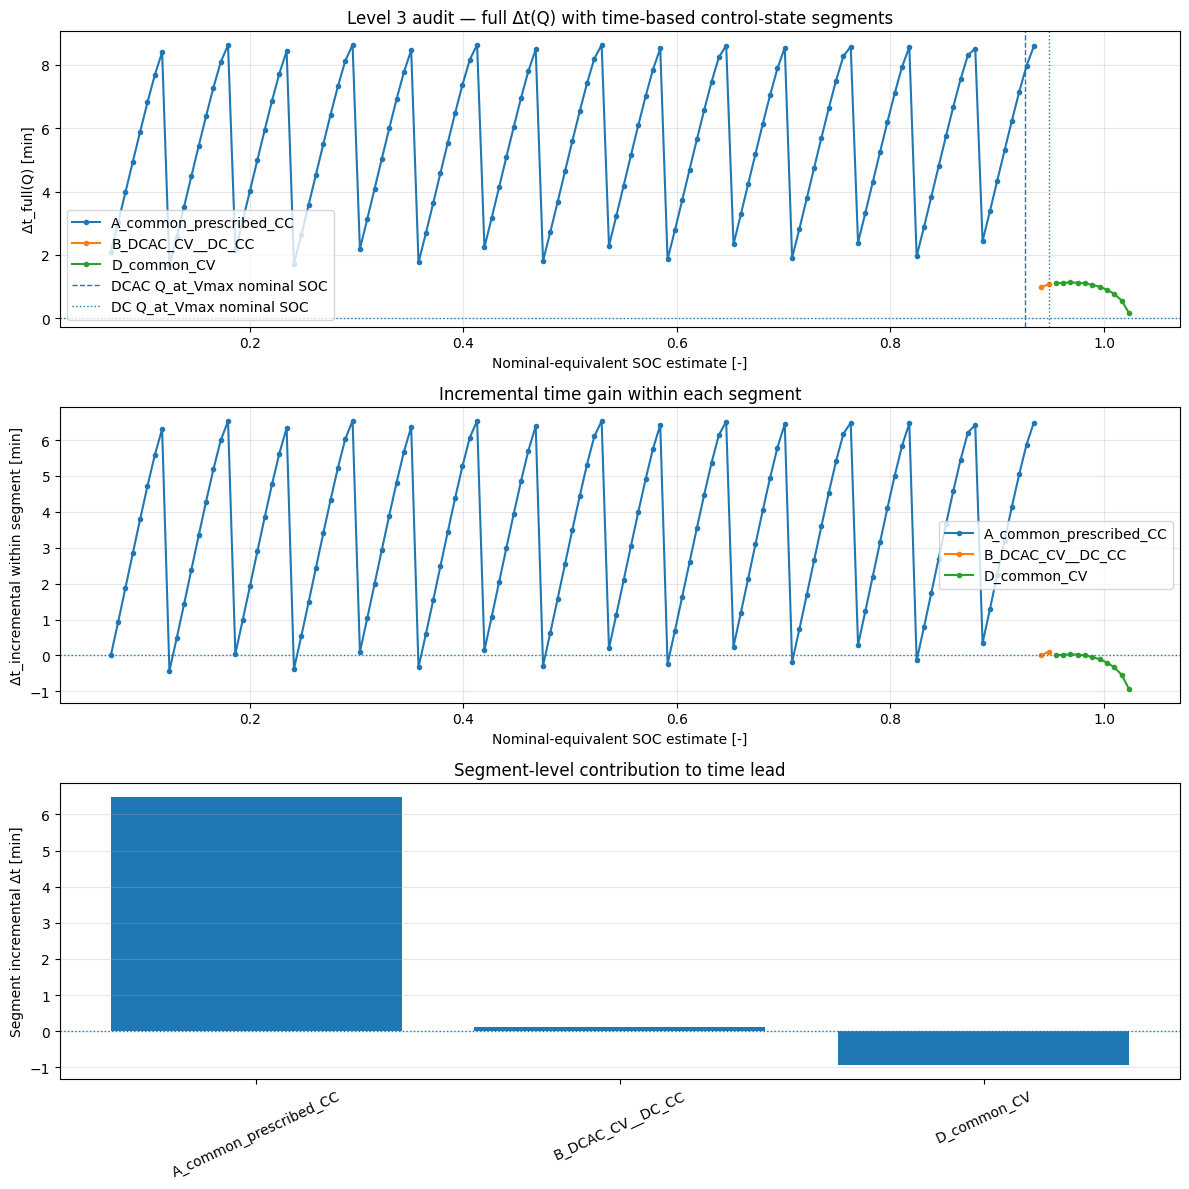

[Level 3 notes]
- Segment labels are now assigned by first-passage time, not by Q_at_Vmax.
- This is required because DC–AC Q(t) can be non-monotonic.
- Positive full Δt(Q) remains a protocol-level time-to-Q gain.
- Segment incremental gain indicates whether later control states preserve or consume earlier lead.
[OK] Time-based segment reassignment and Level 3 incremental audit completed.


In [17]:
# Cell 9 — Time-based segment reassignment + Level 3 incremental audit
# （基于first-passage时间的控制状态重分配与Level 3增量审计）

def control_state_from_first_passage_time(t_fp_s, t_vmax_s, branch):
    """
    Assign control state using first-passage time, not Q boundary.

    This is essential for DC–AC because Q(t) can be non-monotonic.
    """
    if branch == "DC":
        return "CC" if t_fp_s <= t_vmax_s + 1e-9 else "CV"

    if branch == "DCAC":
        return "AC_on_CC" if t_fp_s <= t_vmax_s + 1e-9 else "AC_off_CV"

    raise ValueError(branch)


def segment_label_from_time_states(state_dc, state_dcac):
    """
    Segment classification based on actual first-passage control states.
    """
    if state_dc == "CC" and state_dcac == "AC_on_CC":
        return "A_common_prescribed_CC"

    if state_dc == "CC" and state_dcac == "AC_off_CV":
        return "B_DCAC_CV__DC_CC"

    if state_dc == "CV" and state_dcac == "AC_on_CC":
        return "B_DC_CV__DCAC_CC"

    if state_dc == "CV" and state_dcac == "AC_off_CV":
        return "D_common_CV"

    return "unclassified"


def add_time_based_segments(df_dt, t_vmax_dc_s, t_vmax_dcac_s):
    """
    Recompute control states and segment labels using first-passage times.
    """
    out = df_dt.copy()

    state_dc_list = []
    state_dcac_list = []
    seg_list = []

    for _, row in out.iterrows():
        state_dc = control_state_from_first_passage_time(
            row["t_DC_s"],
            t_vmax_dc_s,
            branch="DC",
        )

        state_dcac = control_state_from_first_passage_time(
            row["t_DCAC_s"],
            t_vmax_dcac_s,
            branch="DCAC",
        )

        seg = segment_label_from_time_states(state_dc, state_dcac)

        state_dc_list.append(state_dc)
        state_dcac_list.append(state_dcac)
        seg_list.append(seg)

    out["control_state_DC_timebased"] = state_dc_list
    out["control_state_DCAC_timebased"] = state_dcac_list
    out["segment_label_timebased"] = seg_list

    out["segment_label_old_Qbased"] = out["segment_label"]
    out["control_state_DC_old_Qbased"] = out["control_state_DC"]
    out["control_state_DCAC_old_Qbased"] = out["control_state_DCAC"]

    return out


# Reassign segments based on first-passage times
df_dt_full_tb = add_time_based_segments(
    df_dt=df_dt_full,
    t_vmax_dc_s=summary_dc["t_stop_s"],
    t_vmax_dcac_s=summary_dcac["t_stop_s"],
)

display(df_dt_full_tb.head())
display(df_dt_full_tb.tail())

# Boundary/frontier audit:
# Q_at_Vmax is the instantaneous Q at voltage event.
# Q_frontier_pre_Vmax is the maximum Q ever reached before voltage event.
# For non-monotonic Q(t), these can differ.
frontier_records = []

for branch, df_cc, summary in [
    ("DC", df_dc_cc, summary_dc),
    ("DCAC", df_dcac_cc, summary_dcac),
]:
    q_at_vmax = float(summary["Q_stop_Ah"])
    q_frontier = float(df_cc["Q_Ah"].max())
    t_at_frontier = float(df_cc.loc[df_cc["Q_Ah"].idxmax(), "t_s"])

    frontier_records.append({
        "branch": branch,
        "t_vmax_min": float(summary["t_stop_min"]),
        "Q_at_Vmax_Ah": q_at_vmax,
        "Q_frontier_pre_Vmax_Ah": q_frontier,
        "Q_frontier_minus_Q_at_Vmax_mAh": (q_frontier - q_at_vmax) * 1000,
        "t_frontier_min": t_at_frontier / 60.0,
        "frontier_before_or_at_Vmax": t_at_frontier <= summary["t_stop_s"] + 1e-9,
    })

df_frontier = pd.DataFrame(frontier_records)
display(df_frontier)

# Compare old Q-based labels vs corrected time-based labels
df_label_crosstab = pd.crosstab(
    df_dt_full_tb["segment_label_old_Qbased"],
    df_dt_full_tb["segment_label_timebased"],
)

display(df_label_crosstab)

# Time-based segment summary
df_segment_summary_timebased = (
    df_dt_full_tb
    .groupby("segment_label_timebased")
    .agg(
        n=("Q_Ah", "size"),
        Q_min_Ah=("Q_Ah", "min"),
        Q_max_Ah=("Q_Ah", "max"),
        SOC_min=("SOC_est", "min"),
        SOC_max=("SOC_est", "max"),
        t_DC_min_min=("t_DC_min", "min"),
        t_DC_min_max=("t_DC_min", "max"),
        t_DCAC_min_min=("t_DCAC_min", "min"),
        t_DCAC_min_max=("t_DCAC_min", "max"),
        dt_min_min=("delta_t_full_min", "min"),
        dt_mean_min=("delta_t_full_min", "mean"),
        dt_max_min=("delta_t_full_min", "max"),
    )
    .reset_index()
)

display(df_segment_summary_timebased)

# Compute incremental gain within each time-based segment.
# Definition:
#   Δt_incremental(Q) = Δt_full(Q) - Δt_full(Q_segment_start)
#
# Interpretation:
#   positive   -> this segment adds extra time lead relative to its own start
#   negative   -> this segment consumes previous time lead
#   near zero  -> this segment preserves the incoming lead
df_inc = df_dt_full_tb.copy()
df_inc["segment_start_Q_Ah"] = np.nan
df_inc["segment_start_SOC_est"] = np.nan
df_inc["segment_start_delta_t_min"] = np.nan
df_inc["delta_t_incremental_min"] = np.nan
df_inc["delta_t_incremental_s"] = np.nan

for seg, g in df_inc.groupby("segment_label_timebased", sort=False):
    idx = g.index
    first_idx = idx[0]

    q0 = float(df_inc.loc[first_idx, "Q_Ah"])
    soc0 = float(df_inc.loc[first_idx, "SOC_est"])
    dt0 = float(df_inc.loc[first_idx, "delta_t_full_min"])

    df_inc.loc[idx, "segment_start_Q_Ah"] = q0
    df_inc.loc[idx, "segment_start_SOC_est"] = soc0
    df_inc.loc[idx, "segment_start_delta_t_min"] = dt0
    df_inc.loc[idx, "delta_t_incremental_min"] = df_inc.loc[idx, "delta_t_full_min"] - dt0
    df_inc.loc[idx, "delta_t_incremental_s"] = 60.0 * df_inc.loc[idx, "delta_t_incremental_min"]

display(df_inc.head())
display(df_inc.tail())

# Segment contribution summary
contrib_rows = []
floor_min = 0.5  # 30 s engineering floor for segment-level smoke interpretation

for seg, g in df_inc.groupby("segment_label_timebased", sort=False):
    start = g.iloc[0]
    end = g.iloc[-1]

    start_dt = float(start["delta_t_full_min"])
    end_dt = float(end["delta_t_full_min"])
    inc_dt = end_dt - start_dt

    if inc_dt > floor_min:
        verdict = "adds_or_amplifies_time_lead"
    elif inc_dt < -floor_min:
        verdict = "consumes_time_lead"
    else:
        verdict = "approximately_preserves_time_lead"

    contrib_rows.append({
        "segment_label_timebased": seg,
        "n": len(g),
        "Q_start_Ah": float(start["Q_Ah"]),
        "Q_end_Ah": float(end["Q_Ah"]),
        "SOC_start": float(start["SOC_est"]),
        "SOC_end": float(end["SOC_est"]),
        "delta_t_start_min": start_dt,
        "delta_t_end_min": end_dt,
        "segment_incremental_delta_t_min": inc_dt,
        "segment_incremental_delta_t_s": inc_dt * 60.0,
        "verdict": verdict,
    })

df_segment_contrib = pd.DataFrame(contrib_rows)
display(df_segment_contrib)

# Plot corrected Level 3 view
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=False)

# Panel 1: Full Δt(Q), colored by time-based segment via separate lines
for seg, g in df_dt_full_tb.groupby("segment_label_timebased", sort=False):
    axes[0].plot(
        g["SOC_est"],
        g["delta_t_full_min"],
        marker=".",
        linewidth=1.5,
        label=seg,
    )

axes[0].axhline(0.0, linestyle=":", linewidth=1.0)
axes[0].axvline(
    initial_soc_smoke + df_frontier.loc[df_frontier["branch"] == "DCAC", "Q_at_Vmax_Ah"].iloc[0] / q_nom_smoke,
    linestyle="--",
    linewidth=1.0,
    label="DCAC Q_at_Vmax nominal SOC",
)
axes[0].axvline(
    initial_soc_smoke + df_frontier.loc[df_frontier["branch"] == "DC", "Q_at_Vmax_Ah"].iloc[0] / q_nom_smoke,
    linestyle=":",
    linewidth=1.0,
    label="DC Q_at_Vmax nominal SOC",
)
axes[0].set_title("Level 3 audit — full Δt(Q) with time-based control-state segments")
axes[0].set_xlabel("Nominal-equivalent SOC estimate [-]")
axes[0].set_ylabel("Δt_full(Q) [min]")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="best")

# Panel 2: Segment incremental gain
for seg, g in df_inc.groupby("segment_label_timebased", sort=False):
    axes[1].plot(
        g["SOC_est"],
        g["delta_t_incremental_min"],
        marker=".",
        linewidth=1.5,
        label=seg,
    )

axes[1].axhline(0.0, linestyle=":", linewidth=1.0)
axes[1].set_title("Incremental time gain within each segment")
axes[1].set_xlabel("Nominal-equivalent SOC estimate [-]")
axes[1].set_ylabel("Δt_incremental within segment [min]")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="best")

# Panel 3: Segment contribution bar plot
axes[2].bar(
    df_segment_contrib["segment_label_timebased"],
    df_segment_contrib["segment_incremental_delta_t_min"],
)

axes[2].axhline(0.0, linestyle=":", linewidth=1.0)
axes[2].set_title("Segment-level contribution to time lead")
axes[2].set_ylabel("Segment incremental Δt [min]")
axes[2].tick_params(axis="x", rotation=25)
axes[2].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Final Level 3 smoke verdict
print("[Level 3 notes]")
print("- Segment labels are now assigned by first-passage time, not by Q_at_Vmax.")
print("- This is required because DC–AC Q(t) can be non-monotonic.")
print("- Positive full Δt(Q) remains a protocol-level time-to-Q gain.")
print("- Segment incremental gain indicates whether later control states preserve or consume earlier lead.")

print("[OK] Time-based segment reassignment and Level 3 incremental audit completed.")

,segment,n,Q_start_Ah,Q_end_Ah,SOC_start,SOC_end,delta_t_start_min,delta_t_end_min,within_segment_delta_min,within_segment_delta_s,handover_from_previous_segment,handover_to_this_segment,handover_delta_min,handover_delta_s,prev_segment_end_delta_t_min,prev_segment_end_Q_Ah,prev_segment_end_SOC
0,A_common_prescribed_CC,127,0.100000,4.421188,0.070000,0.934238,2.094453,8.583019,6.488566,389.313978,NaN,A_common_prescribed_CC,NaN,NaN,NaN,NaN,NaN
1,B_DCAC_CV__DC_CC,2,4.455483,4.489778,0.941097,0.947956,0.975218,1.079967,0.104749,6.284940,A_common_prescribed_CC,B_DCAC_CV__DC_CC,-7.607801,-456.468076,8.583019,4.421188,0.934238
2,D_common_CV,11,4.524073,4.867024,0.954815,1.023405,1.102580,0.158415,-0.944165,-56.649912,B_DCAC_CV__DC_CC,D_common_CV,0.022613,1.356801,1.079967,4.489778,0.947956


,event,delta_min,description,cumulative_delta_t_min
0,initial_grid_lead,2.094453,Initial Δt at first evaluated Q-grid point,2.094453
1,within_A_common_prescribed_CC,6.488566,Within-segment lead change in A_common_prescri...,8.583019
2,handover_to_B_DCAC_CV__DC_CC,-7.607801,Lead jump from previous segment into B_DCAC_CV...,0.975218
3,within_B_DCAC_CV__DC_CC,0.104749,Within-segment lead change in B_DCAC_CV__DC_CC,1.079967
4,handover_to_D_common_CV,0.022613,Lead jump from previous segment into D_common_CV,1.102580
5,within_D_common_CV,-0.944165,Within-segment lead change in D_common_CV,0.158415


,actual_final_delta_t_min,reconstructed_final_delta_t_min,reconstruction_error_s
0,0.158415,0.158415,0.0


,event,delta_min,description,cumulative_delta_t_min,verdict
0,initial_grid_lead,2.094453,Initial Δt at first evaluated Q-grid point,2.094453,adds_lead
1,within_A_common_prescribed_CC,6.488566,Within-segment lead change in A_common_prescri...,8.583019,adds_lead
2,handover_to_B_DCAC_CV__DC_CC,-7.607801,Lead jump from previous segment into B_DCAC_CV...,0.975218,consumes_lead
3,within_B_DCAC_CV__DC_CC,0.104749,Within-segment lead change in B_DCAC_CV__DC_CC,1.079967,near_preserve
4,handover_to_D_common_CV,0.022613,Lead jump from previous segment into D_common_CV,1.102580,near_preserve
5,within_D_common_CV,-0.944165,Within-segment lead change in D_common_CV,0.158415,consumes_lead


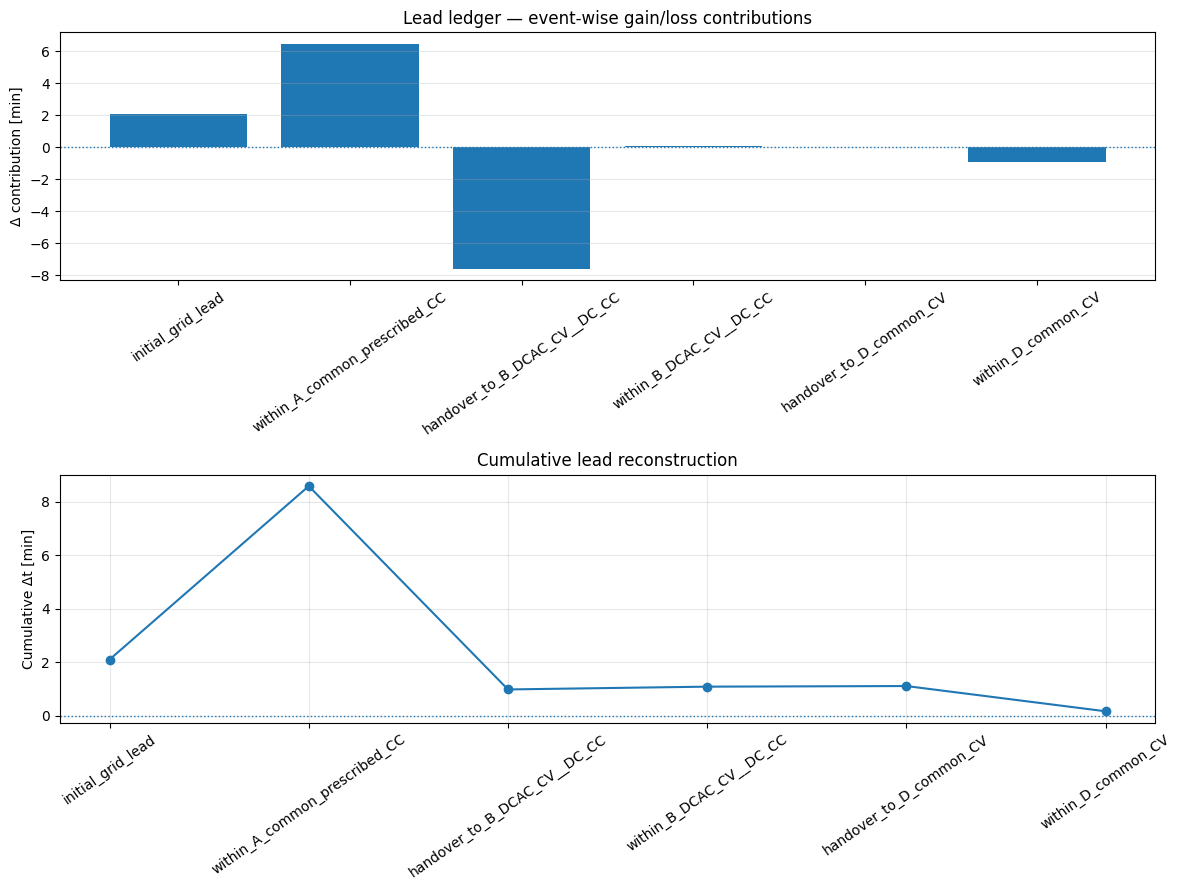

[Lead ledger summary]
initial_grid_lead: +2.094 min -> cumulative +2.094 min (adds_lead)
within_A_common_prescribed_CC: +6.489 min -> cumulative +8.583 min (adds_lead)
handover_to_B_DCAC_CV__DC_CC: -7.608 min -> cumulative +0.975 min (consumes_lead)
within_B_DCAC_CV__DC_CC: +0.105 min -> cumulative +1.080 min (near_preserve)
handover_to_D_common_CV: +0.023 min -> cumulative +1.103 min (near_preserve)
within_D_common_CV: -0.944 min -> cumulative +0.158 min (consumes_lead)
[OK] Lead ledger and handover audit completed.


In [18]:
# Cell 10 — Lead ledger and handover audit（时间领先账本与segment交接审计）

def build_lead_ledger(df_inc, segment_col="segment_label_timebased"):
    """
    Build a lead ledger separating:
    1. within-segment incremental change
    2. handover jump between consecutive segments

    This is necessary because segment-wise incremental curves reset at the
    beginning of each segment and therefore do not show discontinuous lead
    changes across segment boundaries.
    """
    ordered_segments = []
    for seg in df_inc[segment_col].tolist():
        if seg not in ordered_segments:
            ordered_segments.append(seg)

    rows = []
    prev_seg = None
    prev_end_dt = None
    prev_end_q = None
    prev_end_soc = None

    for seg in ordered_segments:
        g = df_inc[df_inc[segment_col] == seg].copy()
        if g.empty:
            continue

        start = g.iloc[0]
        end = g.iloc[-1]

        start_dt = float(start["delta_t_full_min"])
        end_dt = float(end["delta_t_full_min"])
        within_delta = end_dt - start_dt

        if prev_seg is None:
            handover_delta = np.nan
            handover_from = None
            handover_to = seg
        else:
            handover_delta = start_dt - prev_end_dt
            handover_from = prev_seg
            handover_to = seg

        rows.append({
            "segment": seg,
            "n": len(g),
            "Q_start_Ah": float(start["Q_Ah"]),
            "Q_end_Ah": float(end["Q_Ah"]),
            "SOC_start": float(start["SOC_est"]),
            "SOC_end": float(end["SOC_est"]),
            "delta_t_start_min": start_dt,
            "delta_t_end_min": end_dt,
            "within_segment_delta_min": within_delta,
            "within_segment_delta_s": within_delta * 60.0,
            "handover_from_previous_segment": handover_from,
            "handover_to_this_segment": handover_to,
            "handover_delta_min": handover_delta,
            "handover_delta_s": handover_delta * 60.0 if np.isfinite(handover_delta) else np.nan,
            "prev_segment_end_delta_t_min": prev_end_dt,
            "prev_segment_end_Q_Ah": prev_end_q,
            "prev_segment_end_SOC": prev_end_soc,
        })

        prev_seg = seg
        prev_end_dt = end_dt
        prev_end_q = float(end["Q_Ah"])
        prev_end_soc = float(end["SOC_est"])

    return pd.DataFrame(rows)


df_lead_ledger = build_lead_ledger(df_inc)
display(df_lead_ledger)

# Convert ledger into waterfall-style event table
waterfall_rows = []

# Initial lead at first Q-grid point
first_row = df_inc.iloc[0]
waterfall_rows.append({
    "event": "initial_grid_lead",
    "delta_min": float(first_row["delta_t_full_min"]),
    "description": "Initial Δt at first evaluated Q-grid point",
})

for _, row in df_lead_ledger.iterrows():
    seg = row["segment"]

    if pd.notna(row["handover_delta_min"]):
        waterfall_rows.append({
            "event": f"handover_to_{seg}",
            "delta_min": float(row["handover_delta_min"]),
            "description": f"Lead jump from previous segment into {seg}",
        })

    waterfall_rows.append({
        "event": f"within_{seg}",
        "delta_min": float(row["within_segment_delta_min"]),
        "description": f"Within-segment lead change in {seg}",
    })

df_waterfall = pd.DataFrame(waterfall_rows)

# Compute cumulative lead reconstruction
df_waterfall["cumulative_delta_t_min"] = df_waterfall["delta_min"].cumsum()
display(df_waterfall)

# Compare reconstructed final lead with actual final lead
actual_final_dt = float(df_inc.iloc[-1]["delta_t_full_min"])
reconstructed_final_dt = float(df_waterfall["cumulative_delta_t_min"].iloc[-1])

df_ledger_check = pd.DataFrame([{
    "actual_final_delta_t_min": actual_final_dt,
    "reconstructed_final_delta_t_min": reconstructed_final_dt,
    "reconstruction_error_s": (reconstructed_final_dt - actual_final_dt) * 60.0,
}])
display(df_ledger_check)

assert abs((reconstructed_final_dt - actual_final_dt) * 60.0) < 1e-6

# Classify ledger events
def classify_delta(delta_min, floor_min=0.5):
    if delta_min > floor_min:
        return "adds_lead"
    if delta_min < -floor_min:
        return "consumes_lead"
    return "near_preserve"

df_waterfall["verdict"] = df_waterfall["delta_min"].apply(classify_delta)
display(df_waterfall)

# Plot ledger
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=False)

axes[0].bar(
    df_waterfall["event"],
    df_waterfall["delta_min"],
)

axes[0].axhline(0.0, linestyle=":", linewidth=1.0)
axes[0].set_title("Lead ledger — event-wise gain/loss contributions")
axes[0].set_ylabel("Δ contribution [min]")
axes[0].tick_params(axis="x", rotation=35)
axes[0].grid(True, axis="y", alpha=0.3)

axes[1].plot(
    df_waterfall["event"],
    df_waterfall["cumulative_delta_t_min"],
    marker="o",
)

axes[1].axhline(0.0, linestyle=":", linewidth=1.0)
axes[1].set_title("Cumulative lead reconstruction")
axes[1].set_ylabel("Cumulative Δt [min]")
axes[1].tick_params(axis="x", rotation=35)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("[Lead ledger summary]")
for _, row in df_waterfall.iterrows():
    print(
        f"{row['event']}: "
        f"{row['delta_min']:+.3f} min -> cumulative {row['cumulative_delta_t_min']:+.3f} min "
        f"({row['verdict']})"
    )

print("[OK] Lead ledger and handover audit completed.")

In [20]:
# Cell 11 — Smoke-test verdict summary + CSV export（单工况审计结论汇总与CSV导出）

# Output files for the single-case smoke audit.
OUT_SMOKE_FULL_SUMMARY = DATA_DIR / "day29_smoke_full_protocol_summary.csv"
OUT_SMOKE_DTQ = DATA_DIR / "day29_smoke_full_delta_tQ_curves.csv"
OUT_SMOKE_CC_RESID = DATA_DIR / "day29_smoke_cc_geometry_residual.csv"
OUT_SMOKE_LEAD_LEDGER = DATA_DIR / "day29_smoke_lead_ledger.csv"
OUT_SMOKE_WATERFALL = DATA_DIR / "day29_smoke_lead_waterfall.csv"
OUT_SMOKE_VERDICT = DATA_DIR / "day29_smoke_verdict_summary.csv"
OUT_SMOKE_FRONTIER = DATA_DIR / "day29_smoke_frontier_audit.csv"
OUT_SMOKE_KEY_TARGETS = DATA_DIR / "day29_smoke_key_targets.csv"


def safe_get_target_delta(df_targets, target_name):
    row = df_targets[df_targets["target"] == target_name]
    if row.empty:
        return np.nan
    return float(row["delta_t_full_min"].iloc[0])


def make_smoke_verdict_summary():
    """
    Build a compact one-row verdict for the Chen2020 / P01 smoke test.
    """
    soc80_dt = safe_get_target_delta(df_key_targets, "SOC80")
    soc90_dt = safe_get_target_delta(df_key_targets, "SOC90")
    soc95_dt = safe_get_target_delta(df_key_targets, "SOC95")
    common_end_dt = safe_get_target_delta(df_key_targets, "common_Q_end")

    cc_resid_max_abs_s = float(np.max(np.abs(df_cc_resid_smoke["delta_t_resid_s"])))
    cc_resid_mean_s = float(df_cc_resid_smoke["delta_t_resid_s"].mean())

    q_closure_dc_mAh = float(df_closure_summary["dc_max_abs_Q_closure_mAh"].iloc[0])
    q_closure_dcac_mAh = float(df_closure_summary["dcac_max_abs_Q_closure_mAh"].iloc[0])

    dcac_frontier_row = df_frontier[df_frontier["branch"] == "DCAC"].iloc[0]
    dc_frontier_row = df_frontier[df_frontier["branch"] == "DC"].iloc[0]

    # Key ledger values
    def get_waterfall_event(event_name):
        row = df_waterfall[df_waterfall["event"] == event_name]
        if row.empty:
            return np.nan
        return float(row["delta_min"].iloc[0])

    initial_grid_lead = get_waterfall_event("initial_grid_lead")
    within_A = get_waterfall_event("within_A_common_prescribed_CC")
    handover_to_B = get_waterfall_event("handover_to_B_DCAC_CV__DC_CC")
    within_B = get_waterfall_event("within_B_DCAC_CV__DC_CC")
    handover_to_D = get_waterfall_event("handover_to_D_common_CV")
    within_D = get_waterfall_event("within_D_common_CV")

    final_reconstructed = float(df_waterfall["cumulative_delta_t_min"].iloc[-1])
    final_actual = float(df_inc["delta_t_full_min"].iloc[-1])

    # Verdict classification
    operational_effective_mid = (
        np.isfinite(soc80_dt)
        and np.isfinite(soc90_dt)
        and soc80_dt > 0.5
        and soc90_dt > 0.5
    )

    full_endpoint_preserved = (
        np.isfinite(common_end_dt)
        and common_end_dt > 0.5
    )

    cc_resid_supported = cc_resid_max_abs_s > 5.0

    if operational_effective_mid and not full_endpoint_preserved:
        level1_verdict = "mid_trajectory_gain_but_endpoint_gain_nearly_consumed"
    elif operational_effective_mid and full_endpoint_preserved:
        level1_verdict = "mid_and_endpoint_gain_preserved"
    else:
        level1_verdict = "no_clear_operational_gain"

    if cc_resid_supported:
        level2_verdict = "CHECK_residual_exceeds_floor"
    else:
        level2_verdict = "PASS_common_CC_geometry_dominated"

    # Level 3 interpretation from ledger
    if handover_to_B < -0.5 and within_D < -0.5:
        level3_verdict = "major_lead_loss_at_A_to_B_handover_then_common_CV_consumes_remaining_lead"
    elif handover_to_B < -0.5:
        level3_verdict = "major_lead_loss_at_A_to_B_handover"
    elif within_D < -0.5:
        level3_verdict = "common_CV_consumes_remaining_lead"
    else:
        level3_verdict = "later_segments_preserve_lead"

    mechanism_verdict = (
        "Protocol-level mid-trajectory time-to-Q gain is present, "
        "but common-CC gain is explained by current geometry within numerical floor; "
        "no CC-only non-geometric electrochemical acceleration is supported in this smoke test."
    )

    return pd.DataFrame([{
        "parameter_set": smoke_param,
        "pair_id": smoke_case["pair_id"],
        "dc_ref_c": smoke_case["dc_ref_c"],
        "dcac_dc_c": smoke_case["dcac_dc_c"],
        "dcac_ac_c": smoke_case["dcac_ac_c"],
        "freq_label": smoke_case["freq_label"],
        "frequency_hz": smoke_case["frequency_hz"],
        "tau_label_s": smoke_case["tau_label_s"],
        "kappa": smoke_case["dcac_kappa"],

        # Boundary events
        "t_vmax_DC_min": float(summary_dc["t_stop_min"]),
        "t_vmax_DCAC_min": float(summary_dcac["t_stop_min"]),
        "delta_t_vmax_min": float(summary_dc["t_stop_min"] - summary_dcac["t_stop_min"]),
        "Q_vmax_DC_Ah": float(summary_dc["Q_stop_Ah"]),
        "Q_vmax_DCAC_Ah": float(summary_dcac["Q_stop_Ah"]),
        "Q_vmax_DCAC_minus_DC_Ah": float(summary_dcac["Q_stop_Ah"] - summary_dc["Q_stop_Ah"]),

        # Frontier audit
        "Q_frontier_preVmax_DC_Ah": float(dc_frontier_row["Q_frontier_pre_Vmax_Ah"]),
        "Q_frontier_preVmax_DCAC_Ah": float(dcac_frontier_row["Q_frontier_pre_Vmax_Ah"]),
        "Q_frontier_minus_Q_at_Vmax_DCAC_mAh": float(dcac_frontier_row["Q_frontier_minus_Q_at_Vmax_mAh"]),

        # Full protocol endpoint
        "t_end_DC_min": float(df_full_smoke_summary.loc[df_full_smoke_summary["branch"] == "DC", "t_end_min"].iloc[0]),
        "t_end_DCAC_min": float(df_full_smoke_summary.loc[df_full_smoke_summary["branch"] == "DCAC", "t_end_min"].iloc[0]),
        "Q_end_DC_Ah": float(df_full_smoke_summary.loc[df_full_smoke_summary["branch"] == "DC", "Q_end_Ah"].iloc[0]),
        "Q_end_DCAC_Ah": float(df_full_smoke_summary.loc[df_full_smoke_summary["branch"] == "DCAC", "Q_end_Ah"].iloc[0]),

        # Key state-equivalent targets
        "delta_t_SOC80_min": soc80_dt,
        "delta_t_SOC90_min": soc90_dt,
        "delta_t_SOC95_min": soc95_dt,
        "delta_t_common_Q_end_min": common_end_dt,

        # Level 2 residual
        "cc_resid_mean_s": cc_resid_mean_s,
        "cc_resid_max_abs_s": cc_resid_max_abs_s,
        "dc_q_closure_max_abs_mAh": q_closure_dc_mAh,
        "dcac_q_closure_max_abs_mAh": q_closure_dcac_mAh,

        # Lead ledger
        "lead_initial_grid_min": initial_grid_lead,
        "lead_within_A_common_prescribed_CC_min": within_A,
        "lead_handover_to_B_min": handover_to_B,
        "lead_within_B_min": within_B,
        "lead_handover_to_D_min": handover_to_D,
        "lead_within_D_common_CV_min": within_D,
        "lead_final_grid_reconstructed_min": final_reconstructed,
        "lead_final_grid_actual_min": final_actual,
        "lead_grid_end_Q_Ah": float(df_inc.iloc[-1]["Q_Ah"]),
        "lead_grid_end_SOC_est": float(df_inc.iloc[-1]["SOC_est"]),

        # Verdicts
        "level1_verdict": level1_verdict,
        "level2_verdict": level2_verdict,
        "level3_verdict": level3_verdict,
        "mechanism_verdict": mechanism_verdict,
    }])


df_smoke_verdict = make_smoke_verdict_summary()
display(df_smoke_verdict.T)

# Export smoke-test files
df_full_smoke_summary.to_csv(OUT_SMOKE_FULL_SUMMARY, index=False)
df_dt_full_tb.to_csv(OUT_SMOKE_DTQ, index=False)
df_cc_resid_smoke.to_csv(OUT_SMOKE_CC_RESID, index=False)
df_lead_ledger.to_csv(OUT_SMOKE_LEAD_LEDGER, index=False)
df_waterfall.to_csv(OUT_SMOKE_WATERFALL, index=False)
df_smoke_verdict.to_csv(OUT_SMOKE_VERDICT, index=False)
df_frontier.to_csv(OUT_SMOKE_FRONTIER, index=False)
df_key_targets.to_csv(OUT_SMOKE_KEY_TARGETS, index=False)

saved_files = [
    OUT_SMOKE_FULL_SUMMARY,
    OUT_SMOKE_DTQ,
    OUT_SMOKE_CC_RESID,
    OUT_SMOKE_LEAD_LEDGER,
    OUT_SMOKE_WATERFALL,
    OUT_SMOKE_VERDICT,
    OUT_SMOKE_FRONTIER,
    OUT_SMOKE_KEY_TARGETS,
]

for p in saved_files:
    assert p.exists(), f"Missing output file: {p}"
    print("[saved]", p.relative_to(REPO), f"({p.stat().st_size} bytes)")

print("[OK] Smoke-test verdict summary and CSV exports completed.")

,0
parameter_set,Chen2020
pair_id,P01_0p3DC_vs_0p3p0p7_10tau
dc_ref_c,0.3
dcac_dc_c,0.3
dcac_ac_c,0.7
freq_label,10tau
frequency_hz,0.001434
tau_label_s,11.1
kappa,2.333333
t_vmax_DC_min,179.713618


[saved] data/day29_smoke_full_protocol_summary.csv (410 bytes)
[saved] data/day29_smoke_full_delta_tQ_curves.csv (40268 bytes)
[saved] data/day29_smoke_cc_geometry_residual.csv (38190 bytes)
[saved] data/day29_smoke_lead_ledger.csv (1062 bytes)
[saved] data/day29_smoke_lead_waterfall.csv (798 bytes)
[saved] data/day29_smoke_verdict_summary.csv (1877 bytes)
[saved] data/day29_smoke_frontier_audit.csv (313 bytes)
[saved] data/day29_smoke_key_targets.csv (529 bytes)
[OK] Smoke-test verdict summary and CSV exports completed.


In [21]:
# Cell 12 — Batch helper functions for Day29 pilot sweep（Day29小批量审计封装函数）

BATCH_OUT_SUMMARY = DATA_DIR / "day29_batch_pilot_full_protocol_summary.csv"
BATCH_OUT_DTQ = DATA_DIR / "day29_batch_pilot_delta_tQ_curves.csv"
BATCH_OUT_CC_RESID = DATA_DIR / "day29_batch_pilot_cc_geometry_residual.csv"
BATCH_OUT_FRONTIER = DATA_DIR / "day29_batch_pilot_frontier_audit.csv"
BATCH_OUT_LEDGER = DATA_DIR / "day29_batch_pilot_lead_ledger.csv"
BATCH_OUT_WATERFALL = DATA_DIR / "day29_batch_pilot_lead_waterfall.csv"
BATCH_OUT_VERDICT = DATA_DIR / "day29_batch_pilot_verdict_summary.csv"
BATCH_OUT_ERRORS = DATA_DIR / "day29_batch_pilot_errors.csv"


def compute_full_delta_t_curve_v2(
    parameter_set,
    pair_id,
    df_dc,
    df_dcac,
    q_nom_ah,
    initial_soc,
    q_vmax_dc_ah,
    q_vmax_dcac_ah,
    n_grid=140,
):
    """
    Batch-safe full-protocol Δt(Q):

        Δt_full(Q) = t_DC(Q) - t_DCAC(Q)

    Positive Δt means DC–AC reaches the same net-charge target earlier.
    """
    q_end_dc = float(df_dc["Q_Ah"].iloc[-1])
    q_end_dcac = float(df_dcac["Q_Ah"].iloc[-1])
    q_common_end = min(q_end_dc, q_end_dcac)

    q_lo = max(0.02 * q_nom_ah, 0.02 * q_common_end)
    q_hi = q_common_end - 0.001 * q_nom_ah

    if q_hi <= q_lo:
        raise ValueError(f"Invalid Q grid: q_lo={q_lo}, q_hi={q_hi}")

    q_grid = np.linspace(q_lo, q_hi, n_grid)

    rows = []
    for q_target in q_grid:
        t_dc = first_passage_time_from_Q(df_dc, q_target)
        t_dcac = first_passage_time_from_Q(df_dcac, q_target)
        dt_s = t_dc - t_dcac

        rows.append({
            "parameter_set": parameter_set,
            "pair_id": pair_id,
            "Q_Ah": q_target,
            "Q_frac_nominal_increment": q_target / q_nom_ah,
            "SOC_nominal_est": initial_soc + q_target / q_nom_ah,
            "t_DC_s": t_dc,
            "t_DCAC_s": t_dcac,
            "t_DC_min": t_dc / 60.0,
            "t_DCAC_min": t_dcac / 60.0,
            "delta_t_full_s": dt_s,
            "delta_t_full_min": dt_s / 60.0,
            "control_state_DC_Qbased": branch_control_state(q_target, q_vmax_dc_ah, "DC"),
            "control_state_DCAC_Qbased": branch_control_state(q_target, q_vmax_dcac_ah, "DCAC"),
            "segment_label_Qbased": segment_label_from_Q(q_target, q_vmax_dc_ah, q_vmax_dcac_ah),
        })

    return pd.DataFrame(rows)


def add_time_based_segments_v2(df_dt, t_vmax_dc_s, t_vmax_dcac_s):
    """
    Batch-safe time-based segment assignment.
    Segment assignment is based on first-passage time, not Q_at_Vmax.
    """
    out = df_dt.copy()

    state_dc_list = []
    state_dcac_list = []
    seg_list = []

    for _, row in out.iterrows():
        state_dc = control_state_from_first_passage_time(
            row["t_DC_s"],
            t_vmax_dc_s,
            branch="DC",
        )
        state_dcac = control_state_from_first_passage_time(
            row["t_DCAC_s"],
            t_vmax_dcac_s,
            branch="DCAC",
        )
        seg = segment_label_from_time_states(state_dc, state_dcac)

        state_dc_list.append(state_dc)
        state_dcac_list.append(state_dcac)
        seg_list.append(seg)

    out["control_state_DC_timebased"] = state_dc_list
    out["control_state_DCAC_timebased"] = state_dcac_list
    out["segment_label_timebased"] = seg_list

    return out


def compute_cc_geometry_residual_v2(
    parameter_set,
    pair_id,
    df_dc_cc,
    df_dcac_cc,
    q_nom_ah,
    initial_soc,
    q_vmax_dc_ah,
    q_vmax_dcac_ah,
    dc_ref_c,
    dcac_dc_c,
    dcac_ac_c,
    frequency_hz,
    i_1c_a,
    n_grid=120,
    q_margin_frac=0.02,
    dt_geom_grid_s=0.25,
):
    """
    Batch-safe Level 2 common-CC geometry/residual audit.
    """
    q_margin_ah = q_margin_frac * q_nom_ah
    q_hi = min(q_vmax_dc_ah, q_vmax_dcac_ah) - q_margin_ah
    q_lo = max(0.02 * q_nom_ah, 0.02 * q_hi)

    if q_hi <= q_lo:
        raise ValueError(f"Invalid common-CC Q window: q_lo={q_lo}, q_hi={q_hi}")

    t_end_geom = max(
        float(df_dc_cc["t_s"].iloc[-1]),
        float(df_dcac_cc["t_s"].iloc[-1]),
    ) + 60.0

    df_geom_dc = build_geometry_df(
        branch="DC",
        dc_c=dc_ref_c,
        ac_c=0.0,
        frequency_hz=frequency_hz,
        i_1c_a=i_1c_a,
        t_end_s=t_end_geom,
        dt_s=dt_geom_grid_s,
    )

    df_geom_dcac = build_geometry_df(
        branch="DCAC",
        dc_c=dcac_dc_c,
        ac_c=dcac_ac_c,
        frequency_hz=frequency_hz,
        i_1c_a=i_1c_a,
        t_end_s=t_end_geom,
        dt_s=dt_geom_grid_s,
    )

    q_grid = np.linspace(q_lo, q_hi, n_grid)

    rows = []
    for q_target in q_grid:
        t_dc_model = first_passage_time_from_Q(df_dc_cc, q_target)
        t_dcac_model = first_passage_time_from_Q(df_dcac_cc, q_target)

        t_dc_geom = first_passage_time_from_Q(df_geom_dc, q_target)
        t_dcac_geom = first_passage_time_from_Q(df_geom_dcac, q_target)

        dt_model_s = t_dc_model - t_dcac_model
        delta_t_geom_s = t_dc_geom - t_dcac_geom
        dt_resid_s = dt_model_s - delta_t_geom_s

        rows.append({
            "parameter_set": parameter_set,
            "pair_id": pair_id,
            "Q_Ah": q_target,
            "Q_frac_nominal_increment": q_target / q_nom_ah,
            "SOC_nominal_est": initial_soc + q_target / q_nom_ah,
            "delta_t_model_s": dt_model_s,
            "delta_t_model_min": dt_model_s / 60.0,
            "delta_t_geom_s": delta_t_geom_s,
            "delta_t_geom_min": delta_t_geom_s / 60.0,
            "delta_t_resid_s": dt_resid_s,
            "delta_t_resid_min": dt_resid_s / 60.0,
            "q_window_lo_Ah": q_lo,
            "q_window_hi_Ah": q_hi,
            "q_margin_Ah": q_margin_ah,
            "dt_geom_resolution_s": dt_geom_grid_s,
        })

    df_resid = pd.DataFrame(rows)

    # Q closure at PyBaMM output times
    q_dc_exact = exact_q_geom_dc(
        df_dc_cc["t_s"].values,
        dc_c=dc_ref_c,
        i_1c_a=i_1c_a,
    )
    q_dcac_exact = exact_q_geom_dcac(
        df_dcac_cc["t_s"].values,
        dc_c=dcac_dc_c,
        ac_c=dcac_ac_c,
        frequency_hz=frequency_hz,
        i_1c_a=i_1c_a,
    )

    dc_closure = df_dc_cc["Q_Ah"].values - q_dc_exact
    dcac_closure = df_dcac_cc["Q_Ah"].values - q_dcac_exact

    closure = {
        "dc_max_abs_Q_closure_mAh": float(np.max(np.abs(dc_closure)) * 1000),
        "dcac_max_abs_Q_closure_mAh": float(np.max(np.abs(dcac_closure)) * 1000),
        "dc_final_Q_closure_mAh": float(dc_closure[-1] * 1000),
        "dcac_final_Q_closure_mAh": float(dcac_closure[-1] * 1000),
    }

    return df_resid, closure


def compute_key_targets_v2(
    parameter_set,
    pair_id,
    df_dc_full,
    df_dcac_full,
    q_nom_ah,
    initial_soc,
    q_vmax_dc_ah,
    q_vmax_dcac_ah,
):
    """
    Compute SOC80/SOC90/SOC95/common-Q endpoint Δt.
    """
    rows = []
    q_common_end = min(float(df_dc_full["Q_Ah"].iloc[-1]), float(df_dcac_full["Q_Ah"].iloc[-1]))

    for soc_target in [0.80, 0.90, 0.95]:
        q_target = (soc_target - initial_soc) * q_nom_ah

        if q_target <= 0 or q_target > q_common_end:
            rows.append({
                "parameter_set": parameter_set,
                "pair_id": pair_id,
                "target": f"SOC{int(soc_target*100)}",
                "SOC_target": soc_target,
                "Q_target_Ah": q_target,
                "status": "outside_common_Q_window",
            })
            continue

        t_dc = first_passage_time_from_Q(df_dc_full, q_target)
        t_dcac = first_passage_time_from_Q(df_dcac_full, q_target)

        rows.append({
            "parameter_set": parameter_set,
            "pair_id": pair_id,
            "target": f"SOC{int(soc_target*100)}",
            "SOC_target": soc_target,
            "Q_target_Ah": q_target,
            "t_DC_min": t_dc / 60.0,
            "t_DCAC_min": t_dcac / 60.0,
            "delta_t_full_min": (t_dc - t_dcac) / 60.0,
            "status": "ok",
        })

    t_dc_end = first_passage_time_from_Q(df_dc_full, q_common_end)
    t_dcac_end = first_passage_time_from_Q(df_dcac_full, q_common_end)

    rows.append({
        "parameter_set": parameter_set,
        "pair_id": pair_id,
        "target": "common_Q_end",
        "SOC_target": initial_soc + q_common_end / q_nom_ah,
        "Q_target_Ah": q_common_end,
        "t_DC_min": t_dc_end / 60.0,
        "t_DCAC_min": t_dcac_end / 60.0,
        "delta_t_full_min": (t_dc_end - t_dcac_end) / 60.0,
        "status": "ok",
    })

    return pd.DataFrame(rows)


def build_frontier_audit_v2(parameter_set, pair_id, df_dc_cc, df_dcac_cc, summary_dc, summary_dcac):
    """
    Audit Q frontier before Vmax.
    """
    rows = []
    for branch, df_cc, summary in [
        ("DC", df_dc_cc, summary_dc),
        ("DCAC", df_dcac_cc, summary_dcac),
    ]:
        q_at_vmax = float(summary["Q_stop_Ah"])
        q_frontier = float(df_cc["Q_Ah"].max())
        t_frontier = float(df_cc.loc[df_cc["Q_Ah"].idxmax(), "t_s"])

        rows.append({
            "parameter_set": parameter_set,
            "pair_id": pair_id,
            "branch": branch,
            "t_vmax_min": float(summary["t_stop_min"]),
            "Q_at_Vmax_Ah": q_at_vmax,
            "Q_frontier_pre_Vmax_Ah": q_frontier,
            "Q_frontier_minus_Q_at_Vmax_mAh": (q_frontier - q_at_vmax) * 1000,
            "t_frontier_min": t_frontier / 60.0,
        })

    return pd.DataFrame(rows)


def build_verdict_v2(
    parameter_set,
    condition,
    summary_dc,
    summary_dcac,
    df_full_summary,
    df_key_targets,
    df_cc_resid,
    closure,
    df_frontier,
    df_waterfall,
    df_inc,
):
    """
    One-row verdict summary for one parameter_set × condition pair.
    """
    def target_dt(name):
        row = df_key_targets[df_key_targets["target"] == name]
        if row.empty or row["status"].iloc[0] != "ok":
            return np.nan
        return float(row["delta_t_full_min"].iloc[0])

    def wf_event(name):
        row = df_waterfall[df_waterfall["event"] == name]
        if row.empty:
            return np.nan
        return float(row["delta_min"].iloc[0])

    soc80 = target_dt("SOC80")
    soc90 = target_dt("SOC90")
    soc95 = target_dt("SOC95")
    common_end = target_dt("common_Q_end")

    cc_resid_max_abs_s = float(np.max(np.abs(df_cc_resid["delta_t_resid_s"])))
    cc_resid_mean_s = float(df_cc_resid["delta_t_resid_s"].mean())

    dcac_front = df_frontier[df_frontier["branch"] == "DCAC"].iloc[0]
    dc_front = df_frontier[df_frontier["branch"] == "DC"].iloc[0]

    within_A = wf_event("within_A_common_prescribed_CC")
    handover_to_B = wf_event("handover_to_B_DCAC_CV__DC_CC")
    within_B = wf_event("within_B_DCAC_CV__DC_CC")
    handover_to_D = wf_event("handover_to_D_common_CV")
    within_D = wf_event("within_D_common_CV")

    final_grid = float(df_inc["delta_t_full_min"].iloc[-1])

    level1_mid = (
        np.isfinite(soc80)
        and np.isfinite(soc90)
        and soc80 > 0.5
        and soc90 > 0.5
    )
    endpoint_preserved = np.isfinite(common_end) and common_end > 0.5
    level2_pass = cc_resid_max_abs_s <= 5.0

    if level1_mid and not endpoint_preserved:
        level1_verdict = "mid_trajectory_gain_but_endpoint_gain_nearly_consumed"
    elif level1_mid and endpoint_preserved:
        level1_verdict = "mid_and_endpoint_gain_preserved"
    else:
        level1_verdict = "no_clear_operational_gain"

    level2_verdict = (
        "PASS_common_CC_geometry_dominated"
        if level2_pass
        else "CHECK_residual_exceeds_floor"
    )

    if np.isfinite(handover_to_B) and handover_to_B < -0.5 and np.isfinite(within_D) and within_D < -0.5:
        level3_verdict = "major_lead_loss_at_A_to_B_handover_then_common_CV_consumes_remaining_lead"
    elif np.isfinite(handover_to_B) and handover_to_B < -0.5:
        level3_verdict = "major_lead_loss_at_A_to_B_handover"
    elif np.isfinite(within_D) and within_D < -0.5:
        level3_verdict = "common_CV_consumes_remaining_lead"
    else:
        level3_verdict = "later_segments_preserve_or_no_major_loss"

    return {
        "parameter_set": parameter_set,
        "pair_id": condition["pair_id"],
        "dc_ref_c": condition["dc_ref_c"],
        "dcac_dc_c": condition["dcac_dc_c"],
        "dcac_ac_c": condition["dcac_ac_c"],
        "freq_label": condition["freq_label"],
        "frequency_hz": condition["frequency_hz"],
        "tau_label_s": condition["tau_label_s"],
        "kappa": condition["dcac_kappa"],

        "t_vmax_DC_min": float(summary_dc["t_stop_min"]),
        "t_vmax_DCAC_min": float(summary_dcac["t_stop_min"]),
        "delta_t_vmax_min": float(summary_dc["t_stop_min"] - summary_dcac["t_stop_min"]),
        "Q_vmax_DC_Ah": float(summary_dc["Q_stop_Ah"]),
        "Q_vmax_DCAC_Ah": float(summary_dcac["Q_stop_Ah"]),
        "Q_vmax_DCAC_minus_DC_Ah": float(summary_dcac["Q_stop_Ah"] - summary_dc["Q_stop_Ah"]),
        "Q_frontier_minus_Q_at_Vmax_DCAC_mAh": float(dcac_front["Q_frontier_minus_Q_at_Vmax_mAh"]),

        "t_end_DC_min": float(df_full_summary.loc[df_full_summary["branch"] == "DC", "t_end_min"].iloc[0]),
        "t_end_DCAC_min": float(df_full_summary.loc[df_full_summary["branch"] == "DCAC", "t_end_min"].iloc[0]),

        "delta_t_SOC80_min": soc80,
        "delta_t_SOC90_min": soc90,
        "delta_t_SOC95_min": soc95,
        "delta_t_common_Q_end_min": common_end,

        "cc_resid_mean_s": cc_resid_mean_s,
        "cc_resid_max_abs_s": cc_resid_max_abs_s,
        "dc_q_closure_max_abs_mAh": closure["dc_max_abs_Q_closure_mAh"],
        "dcac_q_closure_max_abs_mAh": closure["dcac_max_abs_Q_closure_mAh"],

        "lead_within_A_common_prescribed_CC_min": within_A,
        "lead_handover_to_B_min": handover_to_B,
        "lead_within_B_min": within_B,
        "lead_handover_to_D_min": handover_to_D,
        "lead_within_D_common_CV_min": within_D,
        "lead_final_grid_actual_min": final_grid,

        "level1_verdict": level1_verdict,
        "level2_verdict": level2_verdict,
        "level3_verdict": level3_verdict,
    }


print("[OK] Batch helper functions defined.")

[OK] Batch helper functions defined.


In [23]:
# Cell 12A — Patch batch bugs: SOC column compatibility + zero-duration CV handling
# （修复batch列名兼容与CV起点已满足cutoff的情况）

def get_soc_col(df):
    """
    Return the available nominal SOC estimate column.
    """
    if "SOC_est" in df.columns:
        return "SOC_est"
    if "SOC_nominal_est" in df.columns:
        return "SOC_nominal_est"
    raise KeyError("Neither SOC_est nor SOC_nominal_est found.")


def build_lead_ledger(df_inc, segment_col="segment_label_timebased"):
    """
    Build a lead ledger separating:
    1. within-segment incremental change
    2. handover jump between consecutive segments

    Compatible with both SOC_est and SOC_nominal_est.
    """
    soc_col = get_soc_col(df_inc)

    ordered_segments = []
    for seg in df_inc[segment_col].tolist():
        if seg not in ordered_segments:
            ordered_segments.append(seg)

    rows = []
    prev_seg = None
    prev_end_dt = None
    prev_end_q = None
    prev_end_soc = None

    for seg in ordered_segments:
        g = df_inc[df_inc[segment_col] == seg].copy()
        if g.empty:
            continue

        start = g.iloc[0]
        end = g.iloc[-1]

        start_dt = float(start["delta_t_full_min"])
        end_dt = float(end["delta_t_full_min"])
        within_delta = end_dt - start_dt

        if prev_seg is None:
            handover_delta = np.nan
            handover_from = None
            handover_to = seg
        else:
            handover_delta = start_dt - prev_end_dt
            handover_from = prev_seg
            handover_to = seg

        rows.append({
            "segment": seg,
            "n": len(g),
            "Q_start_Ah": float(start["Q_Ah"]),
            "Q_end_Ah": float(end["Q_Ah"]),
            "SOC_start": float(start[soc_col]),
            "SOC_end": float(end[soc_col]),
            "delta_t_start_min": start_dt,
            "delta_t_end_min": end_dt,
            "within_segment_delta_min": within_delta,
            "within_segment_delta_s": within_delta * 60.0,
            "handover_from_previous_segment": handover_from,
            "handover_to_this_segment": handover_to,
            "handover_delta_min": handover_delta,
            "handover_delta_s": handover_delta * 60.0 if np.isfinite(handover_delta) else np.nan,
            "prev_segment_end_delta_t_min": prev_end_dt,
            "prev_segment_end_Q_Ah": prev_end_q,
            "prev_segment_end_SOC": prev_end_soc,
        })

        prev_seg = seg
        prev_end_dt = end_dt
        prev_end_q = float(end["Q_Ah"])
        prev_end_soc = float(end[soc_col])

    return pd.DataFrame(rows)


def make_voltage_mode_model_from_solution(parameter_set, sol_cc, voltage_hold_v=4.2, cutoff_current_a=None):
    """
    Build a voltage-mode DFN initialized from the final state of a CC solution.
    Optionally attach charge-current cutoff event.
    """
    pv_base = PARAM_VALUES[parameter_set]
    pv = pv_base.copy()
    pv.update({"Voltage function [V]": float(voltage_hold_v)})

    model = pybamm.lithium_ion.DFN(options={"operating mode": "voltage"})
    model = apply_initial_conditions_from_solution(model, sol_cc)

    # Remove Vmax event because CV starts at the voltage boundary.
    removed_events = remove_events_containing(
        model,
        substrings=["Maximum voltage"],
    )

    if cutoff_current_a is not None:
        current_py = model.variables["Current [A]"]
        cutoff_expr = -current_py - float(cutoff_current_a)
        model.events.append(
            pybamm.Event(
                "Charge current cutoff [A]",
                cutoff_expr,
                pybamm.EventType.TERMINATION,
            )
        )

    return model, pv, removed_events


def run_cv_from_vmax(
    parameter_set,
    protocol_label,
    sol_cc,
    t_cc_stop_s,
    q_cc_stop_ah,
    voltage_hold_v=4.2,
    cutoff_current_a=None,
    t_cv_max_s=4 * 3600,
    dt_out_s=2.0,
):
    """
    Continue from current-controlled CC into voltage-controlled CV.

    Patch behavior:
    If the voltage-mode current at CV start is already below cutoff,
    return a valid zero-duration CV result instead of letting PyBaMM
    fail on an initially non-positive termination event.
    """
    pv_base = PARAM_VALUES[parameter_set]
    q_nom_ah = float(pv_base["Nominal cell capacity [A.h]"])
    i_1c_a = q_nom_ah

    if cutoff_current_a is None:
        cutoff_current_a = cutoff_current_a_for_parameter_set(parameter_set)

    cutoff_current_a = float(cutoff_current_a)
    cutoff_c = cutoff_current_a / i_1c_a

    solver = pybamm.CasadiSolver(
        mode="safe",
        rtol=1e-6,
        atol=1e-8,
    )

    # First solve a tiny voltage-mode precheck without cutoff event.
    try:
        model_pre, pv_pre, removed_events = make_voltage_mode_model_from_solution(
            parameter_set=parameter_set,
            sol_cc=sol_cc,
            voltage_hold_v=voltage_hold_v,
            cutoff_current_a=None,
        )

        sim_pre = pybamm.Simulation(
            model_pre,
            parameter_values=pv_pre,
            solver=solver,
        )

        # Very short solve only to obtain consistent algebraic current at CV start.
        t_pre = np.array([0.0, float(min(dt_out_s, 0.5))])
        sol_pre = sim_pre.solve(t_eval=t_pre)

        t_rel_pre = np.asarray(sol_pre.t, dtype=float)
        V_pre = np.asarray(sol_pre["Terminal voltage [V]"](t_rel_pre), dtype=float).reshape(-1)
        I_py_pre = np.asarray(sol_pre["Current [A]"](t_rel_pre), dtype=float).reshape(-1)
        I_chg_pre = -I_py_pre

        I_chg0 = float(I_chg_pre[0])
        V0 = float(V_pre[0])

    except Exception as e:
        return (
            {
                "parameter_set": parameter_set,
                "protocol_label": protocol_label,
                "status": "failed",
                "error_msg": "CV precheck failed: " + repr(e),
            },
            pd.DataFrame(),
            None,
        )

    # If current is already below cutoff at CV start, CV duration is zero.
    if I_chg0 <= cutoff_current_a * 1.0001:
        t_abs = np.array([float(t_cc_stop_s)])
        df_cv = pd.DataFrame({
            "parameter_set": parameter_set,
            "protocol_label": protocol_label,
            "stage": "CV",
            "t_rel_s": [0.0],
            "t_s": t_abs,
            "t_min": t_abs / 60.0,
            "V_terminal_V": [V0],
            "I_py_A": [-I_chg0],
            "I_chg_A": [I_chg0],
            "I_chg_C": [I_chg0 / i_1c_a],
            "Q_Ah": [float(q_cc_stop_ah)],
            "Q_frac_nominal": [float(q_cc_stop_ah) / q_nom_ah],
        })

        summary = {
            "parameter_set": parameter_set,
            "protocol_label": protocol_label,
            "stage": "CV",
            "status": "ok",
            "error_msg": "",
            "removed_events": "; ".join(removed_events),
            "cutoff_current_A": cutoff_current_a,
            "cutoff_C": cutoff_c,
            "t_cv_start_s": float(t_cc_stop_s),
            "t_cv_start_min": float(t_cc_stop_s / 60.0),
            "t_end_s": float(t_cc_stop_s),
            "t_end_min": float(t_cc_stop_s / 60.0),
            "V_end_V": V0,
            "I_chg_end_A": I_chg0,
            "I_chg_end_C": I_chg0 / i_1c_a,
            "Q_end_Ah": float(q_cc_stop_ah),
            "Q_end_frac_nominal": float(q_cc_stop_ah) / q_nom_ah,
            "termination": "already_below_cutoff_at_CV_start",
        }

        return summary, df_cv, sol_pre

    # Otherwise run full CV with cutoff event.
    try:
        model, pv, removed_events = make_voltage_mode_model_from_solution(
            parameter_set=parameter_set,
            sol_cc=sol_cc,
            voltage_hold_v=voltage_hold_v,
            cutoff_current_a=cutoff_current_a,
        )

        sim = pybamm.Simulation(
            model,
            parameter_values=pv,
            solver=solver,
        )

        t_eval_rel = np.arange(
            0.0,
            float(t_cv_max_s + dt_out_s),
            float(dt_out_s),
        )

        sol_cv = sim.solve(t_eval=t_eval_rel)
        status = "ok"
        error_msg = ""

    except Exception as e:
        return (
            {
                "parameter_set": parameter_set,
                "protocol_label": protocol_label,
                "status": "failed",
                "error_msg": repr(e),
                "removed_events": "; ".join(removed_events) if "removed_events" in locals() else "",
                "cutoff_current_A": cutoff_current_a,
                "cutoff_C": cutoff_c,
            },
            pd.DataFrame(),
            None,
        )

    t_rel_s = np.asarray(sol_cv.t, dtype=float)
    t_abs_s = float(t_cc_stop_s) + t_rel_s

    V = np.asarray(sol_cv["Terminal voltage [V]"](t_rel_s), dtype=float).reshape(-1)
    I_py = np.asarray(sol_cv["Current [A]"](t_rel_s), dtype=float).reshape(-1)
    I_chg = -I_py

    Q_cv_inc_Ah = cumtrapz_np(I_chg, t_rel_s) / 3600.0
    Q_Ah = float(q_cc_stop_ah) + (Q_cv_inc_Ah - Q_cv_inc_Ah[0])

    df_cv = pd.DataFrame({
        "parameter_set": parameter_set,
        "protocol_label": protocol_label,
        "stage": "CV",
        "t_rel_s": t_rel_s,
        "t_s": t_abs_s,
        "t_min": t_abs_s / 60.0,
        "V_terminal_V": V,
        "I_py_A": I_py,
        "I_chg_A": I_chg,
        "I_chg_C": I_chg / i_1c_a,
        "Q_Ah": Q_Ah,
        "Q_frac_nominal": Q_Ah / q_nom_ah,
    })

    summary = {
        "parameter_set": parameter_set,
        "protocol_label": protocol_label,
        "stage": "CV",
        "status": status,
        "error_msg": error_msg,
        "removed_events": "; ".join(removed_events),
        "cutoff_current_A": cutoff_current_a,
        "cutoff_C": cutoff_c,
        "t_cv_start_s": float(t_cc_stop_s),
        "t_cv_start_min": float(t_cc_stop_s / 60.0),
        "t_end_s": float(t_abs_s[-1]),
        "t_end_min": float(t_abs_s[-1] / 60.0),
        "V_end_V": float(V[-1]),
        "I_chg_end_A": float(I_chg[-1]),
        "I_chg_end_C": float(I_chg[-1] / i_1c_a),
        "Q_end_Ah": float(Q_Ah[-1]),
        "Q_end_frac_nominal": float(Q_Ah[-1] / q_nom_ah),
        "termination": str(getattr(sol_cv, "termination", "")),
    }

    return summary, df_cv, sol_cv


print("[OK] Patch applied: build_lead_ledger SOC compatibility + zero-duration CV handling.")

[OK] Patch applied: build_lead_ledger SOC compatibility + zero-duration CV handling.


In [24]:
# Cell 13 — Run Day29 pilot batch: 3 parameter sets × P01/P02/P03
# （运行Day29小批量审计：3个参数集 × 3个频率条件）

BATCH_PARAMETER_SETS = ["Chen2020", "Ecker2015", "ORegan2022"]
BATCH_PAIR_IDS = [
    "P01_0p3DC_vs_0p3p0p7_10tau",
    "P02_0p3DC_vs_0p3p0p7_1tau",
    "P03_0p3DC_vs_0p3p0p7_0p1tau",
]

df_batch_conditions = df_cfg[df_cfg["pair_id"].isin(BATCH_PAIR_IDS)].copy()
display(df_batch_conditions)

batch_full_summary_rows = []
batch_dtq_rows = []
batch_cc_resid_rows = []
batch_frontier_rows = []
batch_ledger_rows = []
batch_waterfall_rows = []
batch_verdict_rows = []
batch_error_rows = []

for parameter_set in BATCH_PARAMETER_SETS:
    for _, cond_row in df_batch_conditions.iterrows():
        cond = cond_row.to_dict()
        pair_id = cond["pair_id"]
        frequency_hz = cond["frequency_hz"]
        period_s = 1.0 / frequency_hz

        # Use finer output for high-frequency 0.1tau.
        dt_cc_s = max(0.5, min(2.0, period_s / 20.0))
        dt_cv_s = 2.0

        print("\n" + "=" * 90)
        print(f"[RUN] parameter_set={parameter_set} | pair_id={pair_id} | dt_cc_s={dt_cc_s:.3f}")
        print("=" * 90)

        try:
            # CC to Vmax
            summary_dc_b, df_dc_cc_b, sol_dc_cc_b = run_cc_to_vmax(
                parameter_set=parameter_set,
                protocol_label=f"{pair_id}__DC_ref_CC_to_Vmax",
                dc_c=cond["dc_ref_c"],
                ac_c=0.0,
                frequency_hz=frequency_hz,
                initial_soc=0.05,
                t_max_s=8 * 3600,
                dt_out_s=dt_cc_s,
            )

            summary_dcac_b, df_dcac_cc_b, sol_dcac_cc_b = run_cc_to_vmax(
                parameter_set=parameter_set,
                protocol_label=f"{pair_id}__DCAC_CC_to_Vmax",
                dc_c=cond["dcac_dc_c"],
                ac_c=cond["dcac_ac_c"],
                frequency_hz=frequency_hz,
                initial_soc=0.05,
                t_max_s=8 * 3600,
                dt_out_s=dt_cc_s,
            )

            if summary_dc_b["status"] != "ok":
                raise RuntimeError("DC CC failed: " + summary_dc_b.get("error_msg", ""))
            if summary_dcac_b["status"] != "ok":
                raise RuntimeError("DCAC CC failed: " + summary_dcac_b.get("error_msg", ""))

            # CV continuation
            summary_dc_cv_b, df_dc_cv_b, sol_dc_cv_b = run_cv_from_vmax(
                parameter_set=parameter_set,
                protocol_label=f"{pair_id}__DC_ref_CV",
                sol_cc=sol_dc_cc_b,
                t_cc_stop_s=summary_dc_b["t_stop_s"],
                q_cc_stop_ah=summary_dc_b["Q_stop_Ah"],
                cutoff_current_a=None,
                t_cv_max_s=4 * 3600,
                dt_out_s=dt_cv_s,
            )

            summary_dcac_cv_b, df_dcac_cv_b, sol_dcac_cv_b = run_cv_from_vmax(
                parameter_set=parameter_set,
                protocol_label=f"{pair_id}__DCAC_CV_after_ACoff",
                sol_cc=sol_dcac_cc_b,
                t_cc_stop_s=summary_dcac_b["t_stop_s"],
                q_cc_stop_ah=summary_dcac_b["Q_stop_Ah"],
                cutoff_current_a=None,
                t_cv_max_s=4 * 3600,
                dt_out_s=dt_cv_s,
            )

            if summary_dc_cv_b["status"] != "ok":
                raise RuntimeError("DC CV failed: " + summary_dc_cv_b.get("error_msg", ""))
            if summary_dcac_cv_b["status"] != "ok":
                raise RuntimeError("DCAC CV failed: " + summary_dcac_cv_b.get("error_msg", ""))

            # Combine full trajectories
            df_dc_full_b = combine_cc_cv(df_dc_cc_b, df_dc_cv_b)
            df_dcac_full_b = combine_cc_cv(df_dcac_cc_b, df_dcac_cv_b)

            q_nom_b = float(summary_dc_b["Q_nom_Ah"])
            i_1c_b = float(summary_dc_b["I_1C_A"])
            initial_soc_b = float(summary_dc_b["initial_soc"])

            q_vmax_dc_b = float(summary_dc_b["Q_stop_Ah"])
            q_vmax_dcac_b = float(summary_dcac_b["Q_stop_Ah"])

            # Full branch summary
            df_full_summary_b = pd.DataFrame([
                {
                    "parameter_set": parameter_set,
                    "pair_id": pair_id,
                    "branch": "DC",
                    "t_vmax_min": summary_dc_b["t_stop_min"],
                    "Q_vmax_Ah": summary_dc_b["Q_stop_Ah"],
                    "t_end_min": summary_dc_cv_b["t_end_min"],
                    "Q_end_Ah": summary_dc_cv_b["Q_end_Ah"],
                    "I_end_A": summary_dc_cv_b["I_chg_end_A"],
                    "I_end_C": summary_dc_cv_b["I_chg_end_C"],
                    "termination": summary_dc_cv_b["termination"],
                },
                {
                    "parameter_set": parameter_set,
                    "pair_id": pair_id,
                    "branch": "DCAC",
                    "t_vmax_min": summary_dcac_b["t_stop_min"],
                    "Q_vmax_Ah": summary_dcac_b["Q_stop_Ah"],
                    "t_end_min": summary_dcac_cv_b["t_end_min"],
                    "Q_end_Ah": summary_dcac_cv_b["Q_end_Ah"],
                    "I_end_A": summary_dcac_cv_b["I_chg_end_A"],
                    "I_end_C": summary_dcac_cv_b["I_chg_end_C"],
                    "termination": summary_dcac_cv_b["termination"],
                },
            ])
            batch_full_summary_rows.append(df_full_summary_b)

            # Level 1 curve
            df_dtq_b = compute_full_delta_t_curve_v2(
                parameter_set=parameter_set,
                pair_id=pair_id,
                df_dc=df_dc_full_b,
                df_dcac=df_dcac_full_b,
                q_nom_ah=q_nom_b,
                initial_soc=initial_soc_b,
                q_vmax_dc_ah=q_vmax_dc_b,
                q_vmax_dcac_ah=q_vmax_dcac_b,
                n_grid=140,
            )

            df_dtq_b = add_time_based_segments_v2(
                df_dtq_b,
                t_vmax_dc_s=summary_dc_b["t_stop_s"],
                t_vmax_dcac_s=summary_dcac_b["t_stop_s"],
            )
            batch_dtq_rows.append(df_dtq_b)

            # Level 2 residual
            df_resid_b, closure_b = compute_cc_geometry_residual_v2(
                parameter_set=parameter_set,
                pair_id=pair_id,
                df_dc_cc=df_dc_cc_b,
                df_dcac_cc=df_dcac_cc_b,
                q_nom_ah=q_nom_b,
                initial_soc=initial_soc_b,
                q_vmax_dc_ah=q_vmax_dc_b,
                q_vmax_dcac_ah=q_vmax_dcac_b,
                dc_ref_c=cond["dc_ref_c"],
                dcac_dc_c=cond["dcac_dc_c"],
                dcac_ac_c=cond["dcac_ac_c"],
                frequency_hz=frequency_hz,
                i_1c_a=i_1c_b,
                n_grid=120,
                q_margin_frac=0.02,
                dt_geom_grid_s=0.25,
            )
            batch_cc_resid_rows.append(df_resid_b)

            # Frontier
            df_frontier_b = build_frontier_audit_v2(
                parameter_set=parameter_set,
                pair_id=pair_id,
                df_dc_cc=df_dc_cc_b,
                df_dcac_cc=df_dcac_cc_b,
                summary_dc=summary_dc_b,
                summary_dcac=summary_dcac_b,
            )
            batch_frontier_rows.append(df_frontier_b)

            # Lead ledger
            df_inc_b = df_dtq_b.copy()
            df_inc_b["segment_start_delta_t_min"] = np.nan
            df_inc_b["delta_t_incremental_min"] = np.nan
            df_inc_b["delta_t_incremental_s"] = np.nan

            for seg, g in df_inc_b.groupby("segment_label_timebased", sort=False):
                idx = g.index
                first_idx = idx[0]
                dt0 = float(df_inc_b.loc[first_idx, "delta_t_full_min"])

                df_inc_b.loc[idx, "segment_start_delta_t_min"] = dt0
                df_inc_b.loc[idx, "delta_t_incremental_min"] = df_inc_b.loc[idx, "delta_t_full_min"] - dt0
                df_inc_b.loc[idx, "delta_t_incremental_s"] = 60.0 * df_inc_b.loc[idx, "delta_t_incremental_min"]

            df_ledger_b = build_lead_ledger(df_inc_b)
            df_ledger_b.insert(0, "pair_id", pair_id)
            df_ledger_b.insert(0, "parameter_set", parameter_set)
            batch_ledger_rows.append(df_ledger_b)

            # Waterfall from ledger
            waterfall_rows = []
            first_row = df_inc_b.iloc[0]
            waterfall_rows.append({
                "parameter_set": parameter_set,
                "pair_id": pair_id,
                "event": "initial_grid_lead",
                "delta_min": float(first_row["delta_t_full_min"]),
                "description": "Initial Δt at first evaluated Q-grid point",
            })

            for _, ledger_row in df_ledger_b.iterrows():
                seg = ledger_row["segment"]

                if pd.notna(ledger_row["handover_delta_min"]):
                    waterfall_rows.append({
                        "parameter_set": parameter_set,
                        "pair_id": pair_id,
                        "event": f"handover_to_{seg}",
                        "delta_min": float(ledger_row["handover_delta_min"]),
                        "description": f"Lead jump into {seg}",
                    })

                waterfall_rows.append({
                    "parameter_set": parameter_set,
                    "pair_id": pair_id,
                    "event": f"within_{seg}",
                    "delta_min": float(ledger_row["within_segment_delta_min"]),
                    "description": f"Within-segment lead change in {seg}",
                })

            df_waterfall_b = pd.DataFrame(waterfall_rows)
            df_waterfall_b["cumulative_delta_t_min"] = (
                df_waterfall_b
                .groupby(["parameter_set", "pair_id"])["delta_min"]
                .cumsum()
            )
            batch_waterfall_rows.append(df_waterfall_b)

            # Key targets
            df_key_targets_b = compute_key_targets_v2(
                parameter_set=parameter_set,
                pair_id=pair_id,
                df_dc_full=df_dc_full_b,
                df_dcac_full=df_dcac_full_b,
                q_nom_ah=q_nom_b,
                initial_soc=initial_soc_b,
                q_vmax_dc_ah=q_vmax_dc_b,
                q_vmax_dcac_ah=q_vmax_dcac_b,
            )

            # Verdict
            verdict_b = build_verdict_v2(
                parameter_set=parameter_set,
                condition=cond,
                summary_dc=summary_dc_b,
                summary_dcac=summary_dcac_b,
                df_full_summary=df_full_summary_b,
                df_key_targets=df_key_targets_b,
                df_cc_resid=df_resid_b,
                closure=closure_b,
                df_frontier=df_frontier_b,
                df_waterfall=df_waterfall_b,
                df_inc=df_inc_b,
            )
            batch_verdict_rows.append(verdict_b)

            print(
                "[OK]",
                parameter_set,
                pair_id,
                "| SOC80",
                f"{verdict_b['delta_t_SOC80_min']:.3f} min",
                "| SOC90",
                f"{verdict_b['delta_t_SOC90_min']:.3f} min",
                "| endpoint",
                f"{verdict_b['delta_t_common_Q_end_min']:.3f} min",
                "| cc_resid_max_abs_s",
                f"{verdict_b['cc_resid_max_abs_s']:.3f}",
            )

        except Exception as e:
            err = {
                "parameter_set": parameter_set,
                "pair_id": pair_id,
                "error": repr(e),
            }
            batch_error_rows.append(err)
            print("[FAILED]", err)


# Consolidate batch outputs
df_batch_full_summary = pd.concat(batch_full_summary_rows, ignore_index=True) if batch_full_summary_rows else pd.DataFrame()
df_batch_dtq = pd.concat(batch_dtq_rows, ignore_index=True) if batch_dtq_rows else pd.DataFrame()
df_batch_cc_resid = pd.concat(batch_cc_resid_rows, ignore_index=True) if batch_cc_resid_rows else pd.DataFrame()
df_batch_frontier = pd.concat(batch_frontier_rows, ignore_index=True) if batch_frontier_rows else pd.DataFrame()
df_batch_ledger = pd.concat(batch_ledger_rows, ignore_index=True) if batch_ledger_rows else pd.DataFrame()
df_batch_waterfall = pd.concat(batch_waterfall_rows, ignore_index=True) if batch_waterfall_rows else pd.DataFrame()
df_batch_verdict = pd.DataFrame(batch_verdict_rows)
df_batch_errors = pd.DataFrame(batch_error_rows)

display(df_batch_verdict)
display(df_batch_errors)

# Save
df_batch_full_summary.to_csv(BATCH_OUT_SUMMARY, index=False)
df_batch_dtq.to_csv(BATCH_OUT_DTQ, index=False)
df_batch_cc_resid.to_csv(BATCH_OUT_CC_RESID, index=False)
df_batch_frontier.to_csv(BATCH_OUT_FRONTIER, index=False)
df_batch_ledger.to_csv(BATCH_OUT_LEDGER, index=False)
df_batch_waterfall.to_csv(BATCH_OUT_WATERFALL, index=False)
df_batch_verdict.to_csv(BATCH_OUT_VERDICT, index=False)
df_batch_errors.to_csv(BATCH_OUT_ERRORS, index=False)

for p in [
    BATCH_OUT_SUMMARY,
    BATCH_OUT_DTQ,
    BATCH_OUT_CC_RESID,
    BATCH_OUT_FRONTIER,
    BATCH_OUT_LEDGER,
    BATCH_OUT_WATERFALL,
    BATCH_OUT_VERDICT,
    BATCH_OUT_ERRORS,
]:
    print("[saved]", p.relative_to(REPO), f"({p.stat().st_size} bytes)")

print("[OK] Day29 pilot batch completed.")

,pair_id,dc_ref_c,dcac_dc_c,dcac_ac_c,freq_label,role,dcac_kappa,frequency_hz,tau_label_s,amp_sum_c
0,P01_0p3DC_vs_0p3p0p7_10tau,0.3,0.3,0.7,10tau,MJ1-main-effect analogue,2.333333,0.001434,11.1,1.0
1,P02_0p3DC_vs_0p3p0p7_1tau,0.3,0.3,0.7,1tau,frequency contrast,2.333333,0.014338,11.1,1.0
2,P03_0p3DC_vs_0p3p0p7_0p1tau,0.3,0.3,0.7,0.1tau,event-dominant / misleading contrast,2.333333,0.143383,11.1,1.0



[RUN] parameter_set=Chen2020 | pair_id=P01_0p3DC_vs_0p3p0p7_10tau | dt_cc_s=2.000
[OK] Chen2020 P01_0p3DC_vs_0p3p0p7_10tau | SOC80 6.584 min | SOC90 4.347 min | endpoint 0.088 min | cc_resid_max_abs_s 0.147

[RUN] parameter_set=Chen2020 | pair_id=P02_0p3DC_vs_0p3p0p7_1tau | dt_cc_s=2.000
[OK] Chen2020 P02_0p3DC_vs_0p3p0p7_1tau | SOC80 0.761 min | SOC90 4.712 min | endpoint 5.700 min | cc_resid_max_abs_s 0.518

[RUN] parameter_set=Chen2020 | pair_id=P03_0p3DC_vs_0p3p0p7_0p1tau | dt_cc_s=0.500
[OK] Chen2020 P03_0p3DC_vs_0p3p0p7_0p1tau | SOC80 0.029 min | SOC90 6.853 min | endpoint 7.823 min | cc_resid_max_abs_s 4.215

[RUN] parameter_set=Ecker2015 | pair_id=P01_0p3DC_vs_0p3p0p7_10tau | dt_cc_s=2.000
[OK] Ecker2015 P01_0p3DC_vs_0p3p0p7_10tau | SOC80 6.584 min | SOC90 4.347 min | endpoint 3.118 min | cc_resid_max_abs_s 0.050

[RUN] parameter_set=Ecker2015 | pair_id=P02_0p3DC_vs_0p3p0p7_1tau | dt_cc_s=2.000
[OK] Ecker2015 P02_0p3DC_vs_0p3p0p7_1tau | SOC80 0.761 min | SOC90 0.859 min | endp

At t = 314.676, , mxstep steps taken before reaching tout.
At t = 16.6761, , mxstep steps taken before reaching tout.
At t = 16.6761, , mxstep steps taken before reaching tout.
At t = 16.6761, , mxstep steps taken before reaching tout.
At t = 16.6761, , mxstep steps taken before reaching tout.
At t = 16.6761, , mxstep steps taken before reaching tout.
At t = 24.5842, , mxstep steps taken before reaching tout.
At t = 24.5842, , mxstep steps taken before reaching tout.
At t = 24.5842, , mxstep steps taken before reaching tout.
At t = 24.5842, , mxstep steps taken before reaching tout.
At t = 24.5842, , mxstep steps taken before reaching tout.
At t = 6.58471, , mxstep steps taken before reaching tout.
At t = 6.58471, , mxstep steps taken before reaching tout.
At t = 2.58473, , mxstep steps taken before reaching tout.
At t = 0.584725, , mxstep steps taken before reaching tout.
At t = 0.584725, , mxstep steps taken before reaching tout.
At t = 0.584725, , mxstep steps taken before reaching 

[OK] ORegan2022 P01_0p3DC_vs_0p3p0p7_10tau | SOC80 nan min | SOC90 nan min | endpoint 6.250 min | cc_resid_max_abs_s 0.166

[RUN] parameter_set=ORegan2022 | pair_id=P02_0p3DC_vs_0p3p0p7_1tau | dt_cc_s=2.000


At t = 314.676, , mxstep steps taken before reaching tout.
At t = 16.6771, , mxstep steps taken before reaching tout.
At t = 16.6771, , mxstep steps taken before reaching tout.
At t = 16.6771, , mxstep steps taken before reaching tout.
At t = 16.6771, , mxstep steps taken before reaching tout.
At t = 16.6771, , mxstep steps taken before reaching tout.
At t = 218.487, , mxstep steps taken before reaching tout.
At t = 218.483, , mxstep steps taken before reaching tout.
At t = 70.4819, , mxstep steps taken before reaching tout.
At t = 70.4819, , mxstep steps taken before reaching tout.
At t = 34.4804, , mxstep steps taken before reaching tout.
At t = 16.4809, , mxstep steps taken before reaching tout.


...

At t = 287.676, , mxstep steps taken before reaching tout.
At t = 287.676, , mxstep steps taken before reaching tout.
At t = 138.176, , mxstep steps taken before reaching tout.
At t = 63.6768, , mxstep steps taken before reaching tout.
At t = 26.6764, , mxstep steps taken before reaching tout.
At t = 8.17637, , mxstep steps taken before reaching tout.
At t = 8.17637, , mxstep steps taken before reaching tout.
At t = 265.891, , mxstep steps taken before reaching tout.
At t = 265.891, , mxstep steps taken before reaching tout.
At t = 116.393, , mxstep steps taken before reaching tout.
At t = 41.89, , mxstep steps taken before reaching tout.
At t = 4.88962, , mxstep steps taken before reaching tout.
At t = 4.88962, , mxstep steps taken before reaching tout.
At t = 4.88962, , mxstep steps taken before reaching tout.


[OK] ORegan2022 P03_0p3DC_vs_0p3p0p7_0p1tau | SOC80 0.029 min | SOC90 0.034 min | endpoint 0.022 min | cc_resid_max_abs_s 4.233


,parameter_set,pair_id,dc_ref_c,dcac_dc_c,dcac_ac_c,freq_label,frequency_hz,tau_label_s,kappa,t_vmax_DC_min,...,dcac_q_closure_max_abs_mAh,lead_within_A_common_prescribed_CC_min,lead_handover_to_B_min,lead_within_B_min,lead_handover_to_D_min,lead_within_D_common_CV_min,lead_final_grid_actual_min,level1_verdict,level2_verdict,level3_verdict
0,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,0.3,0.3,0.7,10tau,0.001434,11.1,2.333333,179.713618,...,0.005839,6.488549,-7.607801,0.104750,0.022606,-0.945236,0.157322,mid_trajectory_gain_but_endpoint_gain_nearly_c...,PASS_common_CC_geometry_dominated,major_lead_loss_at_A_to_B_handover_then_common...
1,Chen2020,P02_0p3DC_vs_0p3p0p7_1tau,0.3,0.3,0.7,1tau,0.014338,11.1,2.333333,179.713618,...,0.058423,0.301066,0.042620,5.671102,-0.104116,-0.510566,5.685980,mid_and_endpoint_gain_preserved,PASS_common_CC_geometry_dominated,common_CV_consumes_remaining_lead
2,Chen2020,P03_0p3DC_vs_0p3p0p7_0p1tau,0.3,0.3,0.7,0.1tau,0.143383,11.1,2.333333,179.713622,...,0.036619,0.042977,-0.016361,8.318514,-0.109510,-0.446352,7.815469,no_clear_operational_gain,PASS_common_CC_geometry_dominated,later_segments_preserve_or_no_major_loss
3,Ecker2015,P01_0p3DC_vs_0p3p0p7_10tau,0.3,0.3,0.7,10tau,0.001434,11.1,2.333333,204.727827,...,0.000182,6.415786,-6.572976,0.885754,0.002301,0.111460,3.040413,mid_and_endpoint_gain_preserved,PASS_common_CC_geometry_dominated,major_lead_loss_at_A_to_B_handover
4,Ecker2015,P02_0p3DC_vs_0p3p0p7_1tau,0.3,0.3,0.7,1tau,0.014338,11.1,2.333333,204.727827,...,0.001826,0.361082,NaN,NaN,0.820052,0.000000,1.445543,mid_and_endpoint_gain_preserved,PASS_common_CC_geometry_dominated,later_segments_preserve_or_no_major_loss
5,Ecker2015,P03_0p3DC_vs_0p3p0p7_0p1tau,0.3,0.3,0.7,0.1tau,0.143383,11.1,2.333333,204.727826,...,0.001144,0.002901,0.136257,0.000000,-0.017665,-0.018603,0.155756,no_clear_operational_gain,PASS_common_CC_geometry_dominated,later_segments_preserve_or_no_major_loss
6,ORegan2022,P01_0p3DC_vs_0p3p0p7_10tau,0.3,0.3,0.7,10tau,0.001434,11.1,2.333333,184.543601,...,0.005839,4.020389,NaN,NaN,NaN,NaN,6.114842,no_clear_operational_gain,PASS_common_CC_geometry_dominated,later_segments_preserve_or_no_major_loss
7,ORegan2022,P02_0p3DC_vs_0p3p0p7_1tau,0.3,0.3,0.7,1tau,0.014338,11.1,2.333333,184.543608,...,0.058423,0.277317,NaN,NaN,NaN,NaN,0.563191,mid_and_endpoint_gain_preserved,PASS_common_CC_geometry_dominated,later_segments_preserve_or_no_major_loss
8,ORegan2022,P03_0p3DC_vs_0p3p0p7_0p1tau,0.3,0.3,0.7,0.1tau,0.143383,11.1,2.333333,184.543608,...,0.036619,0.018578,NaN,NaN,NaN,NaN,0.044778,no_clear_operational_gain,PASS_common_CC_geometry_dominated,later_segments_preserve_or_no_major_loss


""


[saved] data/day29_batch_pilot_full_protocol_summary.csv (3510 bytes)
[saved] data/day29_batch_pilot_delta_tQ_curves.csv (332814 bytes)
[saved] data/day29_batch_pilot_cc_geometry_residual.csv (270805 bytes)
[saved] data/day29_batch_pilot_frontier_audit.csv (2330 bytes)
[saved] data/day29_batch_pilot_lead_ledger.csv (6295 bytes)
[saved] data/day29_batch_pilot_lead_waterfall.csv (5955 bytes)
[saved] data/day29_batch_pilot_verdict_summary.csv (5961 bytes)
[saved] data/day29_batch_pilot_errors.csv (1 bytes)
[OK] Day29 pilot batch completed.


,parameter_set,freq_label,pair_id,delta_t_SOC80_min,delta_t_SOC90_min,delta_t_SOC95_min,delta_t_common_Q_end_min,cc_resid_max_abs_s,lead_handover_to_B_min,lead_within_B_min,lead_within_D_common_CV_min,level1_verdict_corrected,level2_verdict,level3_verdict_corrected
0,Chen2020,10tau,P01_0p3DC_vs_0p3p0p7_10tau,6.584072,4.346633,1.085225,0.088303,0.147257,-7.607801,0.104750,-0.945236,mid_trajectory_gain_but_endpoint_consumed,PASS_common_CC_geometry_dominated,A_to_B_handover_consumes_lead + D_common_CV_co...
1,Chen2020,1tau,P02_0p3DC_vs_0p3p0p7_1tau,0.761077,4.712095,6.266877,5.700024,0.517577,0.042620,5.671102,-0.510566,broad_trajectory_and_endpoint_gain,PASS_common_CC_geometry_dominated,B_segment_adds_lead + D_common_CV_consumes_lead
2,Chen2020,0.1tau,P03_0p3DC_vs_0p3p0p7_0p1tau,0.028896,6.853433,8.336158,7.823475,4.214534,-0.016361,8.318514,-0.446352,late_trajectory_and_endpoint_gain,PASS_common_CC_geometry_dominated,B_segment_adds_lead
3,Ecker2015,10tau,P01_0p3DC_vs_0p3p0p7_10tau,6.584072,4.346633,3.213642,3.118144,0.050058,-6.572976,0.885754,0.111460,broad_trajectory_and_endpoint_gain,PASS_common_CC_geometry_dominated,A_to_B_handover_consumes_lead + B_segment_adds...
4,Ecker2015,1tau,P02_0p3DC_vs_0p3p0p7_1tau,0.761077,0.858506,0.617809,1.394133,0.584060,NaN,NaN,0.000000,broad_trajectory_and_endpoint_gain,PASS_common_CC_geometry_dominated,handover_to_D_adds_lead
5,Ecker2015,0.1tau,P03_0p3DC_vs_0p3p0p7_0p1tau,0.028896,0.033547,0.035987,0.157656,4.085635,0.136257,0.000000,-0.018603,weak_or_no_operational_gain,PASS_common_CC_geometry_dominated,no_resolved_major_boundary_or_CV_contribution
6,ORegan2022,10tau,P01_0p3DC_vs_0p3p0p7_10tau,NaN,NaN,NaN,6.250419,0.165625,NaN,NaN,NaN,endpoint_only_or_sparse_target_gain,PASS_common_CC_geometry_dominated,no_resolved_major_boundary_or_CV_contribution
7,ORegan2022,1tau,P02_0p3DC_vs_0p3p0p7_1tau,0.761077,0.858506,0.617809,0.697590,0.644911,NaN,NaN,NaN,broad_trajectory_and_endpoint_gain,PASS_common_CC_geometry_dominated,no_resolved_major_boundary_or_CV_contribution
8,ORegan2022,0.1tau,P03_0p3DC_vs_0p3p0p7_0p1tau,0.028896,0.033547,0.035987,0.022445,4.233167,NaN,NaN,NaN,weak_or_no_operational_gain,PASS_common_CC_geometry_dominated,no_resolved_major_boundary_or_CV_contribution


[saved] data/day29_batch_pilot_verdict_summary_corrected.csv (6705 bytes)


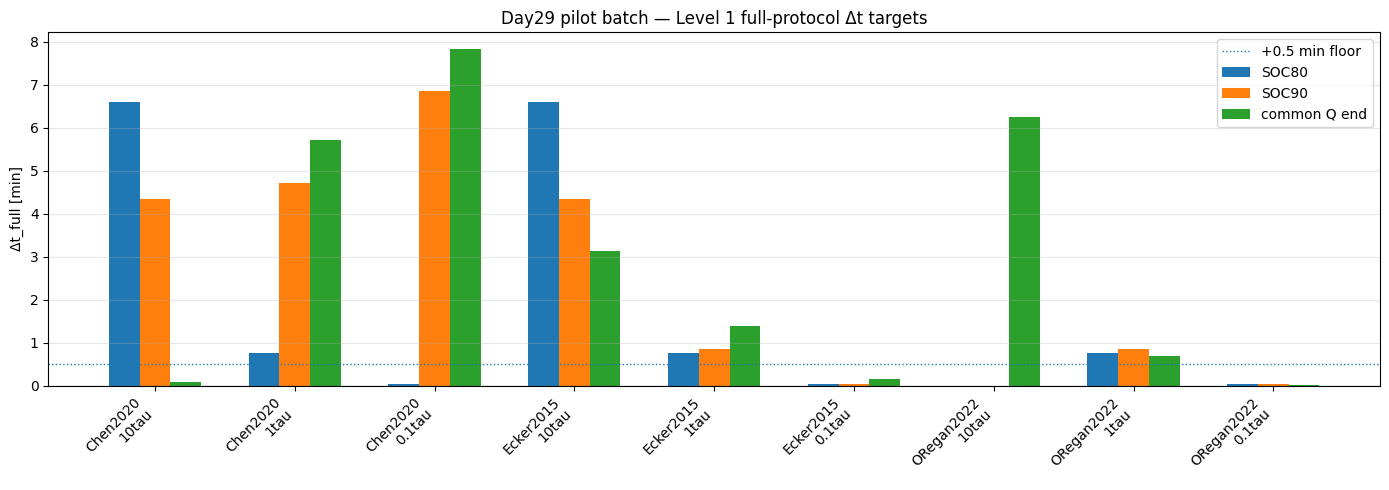

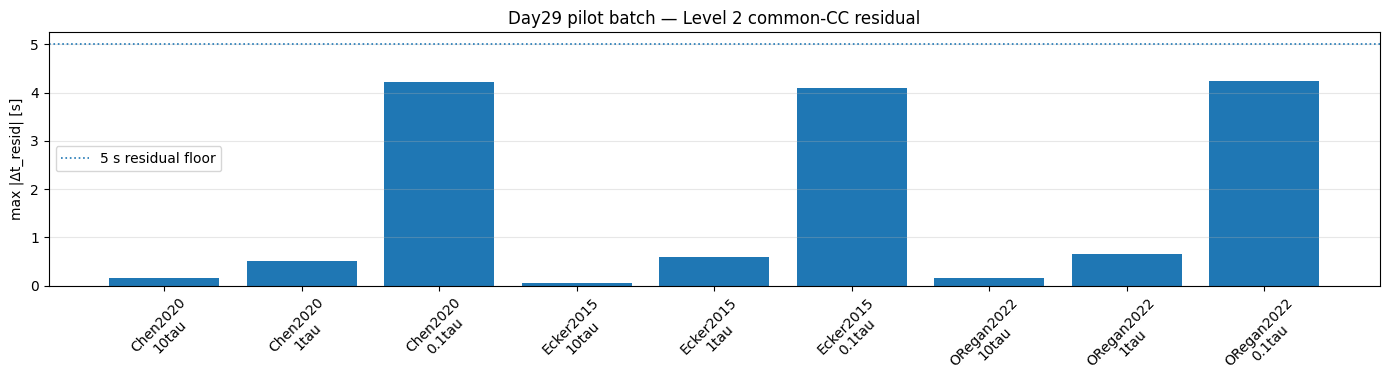

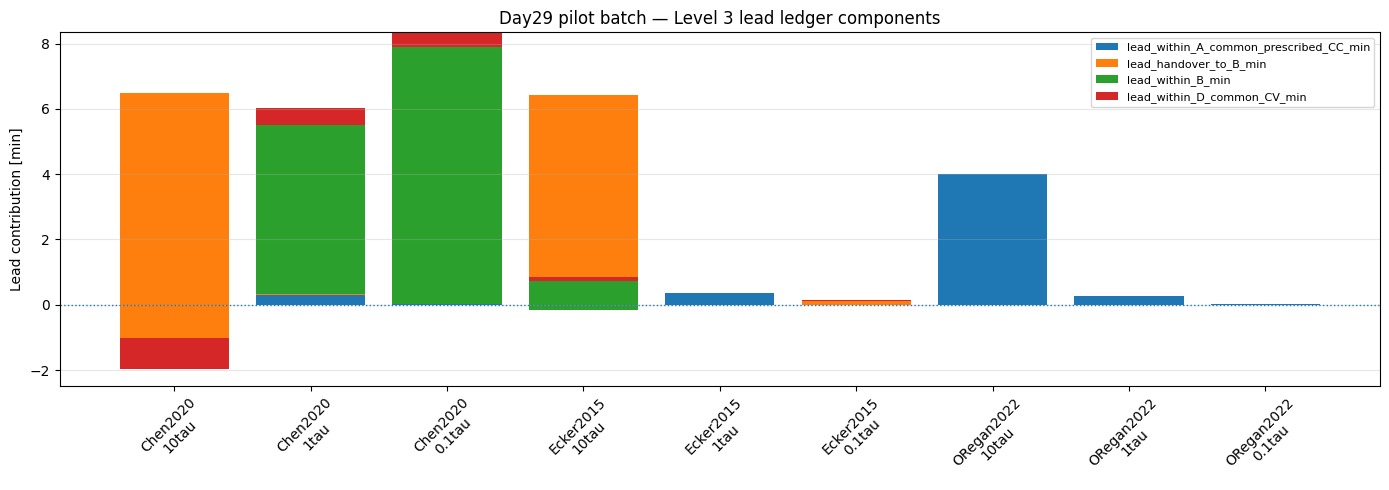

[OK] Corrected batch verdict classification and summary plots completed.


In [25]:
# Cell 14 — Corrected batch verdict classification and summary plots
# （修正batch判据分类并生成汇总图）

def classify_level1_corrected(row, floor_min=0.5):
    """
    More nuanced Level 1 classification.

    Uses:
    - SOC80: early/mid trajectory
    - SOC90: late-mid trajectory
    - SOC95: late trajectory
    - common_Q_end: true common endpoint
    """
    soc80 = row.get("delta_t_SOC80_min", np.nan)
    soc90 = row.get("delta_t_SOC90_min", np.nan)
    soc95 = row.get("delta_t_SOC95_min", np.nan)
    end = row.get("delta_t_common_Q_end_min", np.nan)

    early = np.isfinite(soc80) and soc80 > floor_min
    midlate = np.isfinite(soc90) and soc90 > floor_min
    late = np.isfinite(soc95) and soc95 > floor_min
    endpoint = np.isfinite(end) and end > floor_min

    available_targets = [
        np.isfinite(soc80),
        np.isfinite(soc90),
        np.isfinite(soc95),
        np.isfinite(end),
    ]

    if not any(available_targets):
        return "invalid_no_common_targets"

    if early and midlate and late and endpoint:
        return "broad_trajectory_and_endpoint_gain"

    if early and midlate and not endpoint:
        return "mid_trajectory_gain_but_endpoint_consumed"

    if (not early) and midlate and endpoint:
        return "late_trajectory_and_endpoint_gain"

    if (not early) and (not midlate) and late and endpoint:
        return "late_only_endpoint_gain"

    if endpoint and not early and not midlate and not late:
        return "endpoint_only_or_sparse_target_gain"

    if early or midlate or late:
        return "partial_trajectory_gain_without_endpoint_preservation"

    return "weak_or_no_operational_gain"


def classify_level3_corrected(row, floor_min=0.5):
    """
    More explicit Level 3 classification based on lead ledger components.
    """
    hB = row.get("lead_handover_to_B_min", np.nan)
    wB = row.get("lead_within_B_min", np.nan)
    hD = row.get("lead_handover_to_D_min", np.nan)
    wD = row.get("lead_within_D_common_CV_min", np.nan)

    components = []

    if np.isfinite(hB):
        if hB < -floor_min:
            components.append("A_to_B_handover_consumes_lead")
        elif hB > floor_min:
            components.append("A_to_B_handover_adds_lead")

    if np.isfinite(wB):
        if wB < -floor_min:
            components.append("B_segment_consumes_lead")
        elif wB > floor_min:
            components.append("B_segment_adds_lead")

    if np.isfinite(hD):
        if hD < -floor_min:
            components.append("handover_to_D_consumes_lead")
        elif hD > floor_min:
            components.append("handover_to_D_adds_lead")

    if np.isfinite(wD):
        if wD < -floor_min:
            components.append("D_common_CV_consumes_lead")
        elif wD > floor_min:
            components.append("D_common_CV_adds_lead")

    if not components:
        return "no_resolved_major_boundary_or_CV_contribution"

    return " + ".join(components)


df_batch_verdict_corrected = df_batch_verdict.copy()

df_batch_verdict_corrected["level1_verdict_corrected"] = df_batch_verdict_corrected.apply(
    classify_level1_corrected,
    axis=1,
)

df_batch_verdict_corrected["level3_verdict_corrected"] = df_batch_verdict_corrected.apply(
    classify_level3_corrected,
    axis=1,
)

# Compact display table
cols_compact = [
    "parameter_set",
    "freq_label",
    "pair_id",
    "delta_t_SOC80_min",
    "delta_t_SOC90_min",
    "delta_t_SOC95_min",
    "delta_t_common_Q_end_min",
    "cc_resid_max_abs_s",
    "lead_handover_to_B_min",
    "lead_within_B_min",
    "lead_within_D_common_CV_min",
    "level1_verdict_corrected",
    "level2_verdict",
    "level3_verdict_corrected",
]

display(df_batch_verdict_corrected[cols_compact])

# Save corrected verdict table
BATCH_OUT_VERDICT_CORRECTED = DATA_DIR / "day29_batch_pilot_verdict_summary_corrected.csv"
df_batch_verdict_corrected.to_csv(BATCH_OUT_VERDICT_CORRECTED, index=False)
print("[saved]", BATCH_OUT_VERDICT_CORRECTED.relative_to(REPO), f"({BATCH_OUT_VERDICT_CORRECTED.stat().st_size} bytes)")

# Plot 1 — Level 1 Δt targets
df_plot = df_batch_verdict_corrected.copy()
df_plot["case_label"] = df_plot["parameter_set"] + "\n" + df_plot["freq_label"]

x = np.arange(len(df_plot))
width = 0.22

fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(x - width, df_plot["delta_t_SOC80_min"], width, label="SOC80")
ax.bar(x, df_plot["delta_t_SOC90_min"], width, label="SOC90")
ax.bar(x + width, df_plot["delta_t_common_Q_end_min"], width, label="common Q end")

ax.axhline(0.0, linestyle=":", linewidth=1.0)
ax.axhline(0.5, linestyle=":", linewidth=1.0, label="+0.5 min floor")

ax.set_title("Day29 pilot batch — Level 1 full-protocol Δt targets")
ax.set_ylabel("Δt_full [min]")
ax.set_xticks(x)
ax.set_xticklabels(df_plot["case_label"], rotation=45, ha="right")
ax.grid(True, axis="y", alpha=0.3)
ax.legend(loc="best")

plt.tight_layout()
plt.show()

# Plot 2 — Level 2 residual
fig, ax = plt.subplots(figsize=(14, 4))

ax.bar(df_plot["case_label"], df_plot["cc_resid_max_abs_s"])
ax.axhline(5.0, linestyle=":", linewidth=1.2, label="5 s residual floor")

ax.set_title("Day29 pilot batch — Level 2 common-CC residual")
ax.set_ylabel("max |Δt_resid| [s]")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, axis="y", alpha=0.3)
ax.legend(loc="best")

plt.tight_layout()
plt.show()

# Plot 3 — Lead ledger components
lead_cols = [
    "lead_within_A_common_prescribed_CC_min",
    "lead_handover_to_B_min",
    "lead_within_B_min",
    "lead_within_D_common_CV_min",
]

fig, ax = plt.subplots(figsize=(14, 5))

bottom = np.zeros(len(df_plot))
for col in lead_cols:
    values = df_plot[col].fillna(0.0).values
    ax.bar(df_plot["case_label"], values, bottom=bottom, label=col)
    bottom += values

ax.axhline(0.0, linestyle=":", linewidth=1.0)
ax.set_title("Day29 pilot batch — Level 3 lead ledger components")
ax.set_ylabel("Lead contribution [min]")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, axis="y", alpha=0.3)
ax.legend(loc="best", fontsize=8)

plt.tight_layout()
plt.show()

print("[OK] Corrected batch verdict classification and summary plots completed.")

,parameter_set,freq_label,delta_t_SOC80_min,delta_t_SOC90_min,delta_t_SOC95_min,delta_t_common_Q_end_min,cc_resid_max_abs_s,level1_verdict_corrected,level2_verdict,level3_verdict_corrected
0,Chen2020,10tau,6.584072,4.346633,1.085225,0.088303,0.147257,mid_trajectory_gain_but_endpoint_consumed,PASS_common_CC_geometry_dominated,A_to_B_handover_consumes_lead + D_common_CV_co...
1,Chen2020,1tau,0.761077,4.712095,6.266877,5.700024,0.517577,broad_trajectory_and_endpoint_gain,PASS_common_CC_geometry_dominated,B_segment_adds_lead + D_common_CV_consumes_lead
2,Chen2020,0.1tau,0.028896,6.853433,8.336158,7.823475,4.214534,late_trajectory_and_endpoint_gain,PASS_common_CC_geometry_dominated,B_segment_adds_lead
3,Ecker2015,10tau,6.584072,4.346633,3.213642,3.118144,0.050058,broad_trajectory_and_endpoint_gain,PASS_common_CC_geometry_dominated,A_to_B_handover_consumes_lead + B_segment_adds...
4,Ecker2015,1tau,0.761077,0.858506,0.617809,1.394133,0.584060,broad_trajectory_and_endpoint_gain,PASS_common_CC_geometry_dominated,handover_to_D_adds_lead
5,Ecker2015,0.1tau,0.028896,0.033547,0.035987,0.157656,4.085635,weak_or_no_operational_gain,PASS_common_CC_geometry_dominated,no_resolved_major_boundary_or_CV_contribution
6,ORegan2022,10tau,NaN,NaN,NaN,6.250419,0.165625,endpoint_only_or_sparse_target_gain,PASS_common_CC_geometry_dominated,no_resolved_major_boundary_or_CV_contribution
7,ORegan2022,1tau,0.761077,0.858506,0.617809,0.697590,0.644911,broad_trajectory_and_endpoint_gain,PASS_common_CC_geometry_dominated,no_resolved_major_boundary_or_CV_contribution
8,ORegan2022,0.1tau,0.028896,0.033547,0.035987,0.022445,4.233167,weak_or_no_operational_gain,PASS_common_CC_geometry_dominated,no_resolved_major_boundary_or_CV_contribution


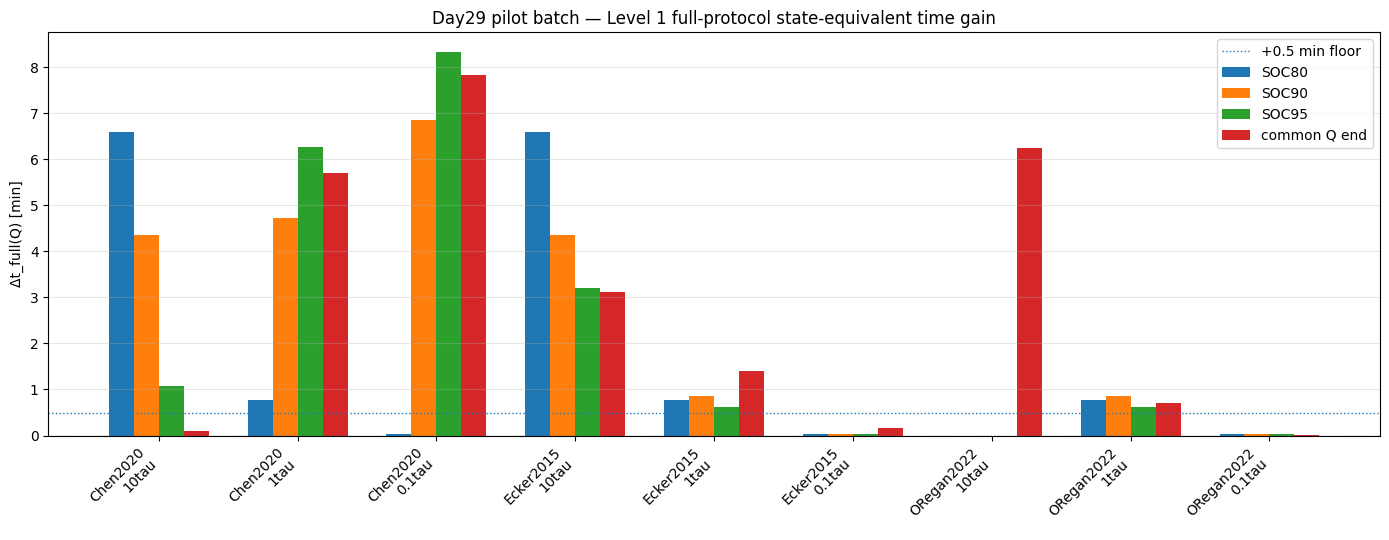

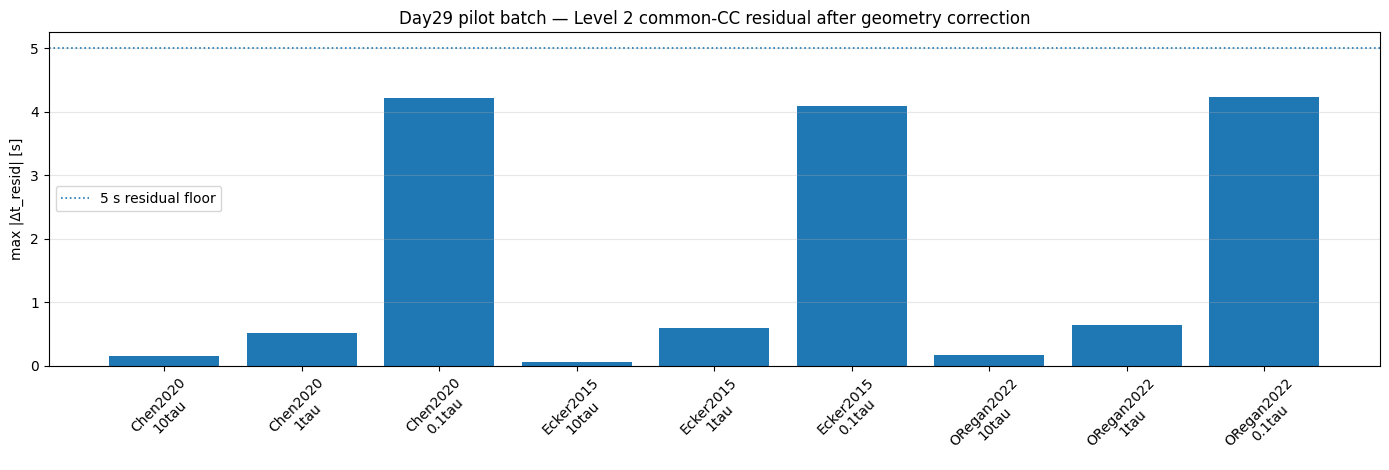

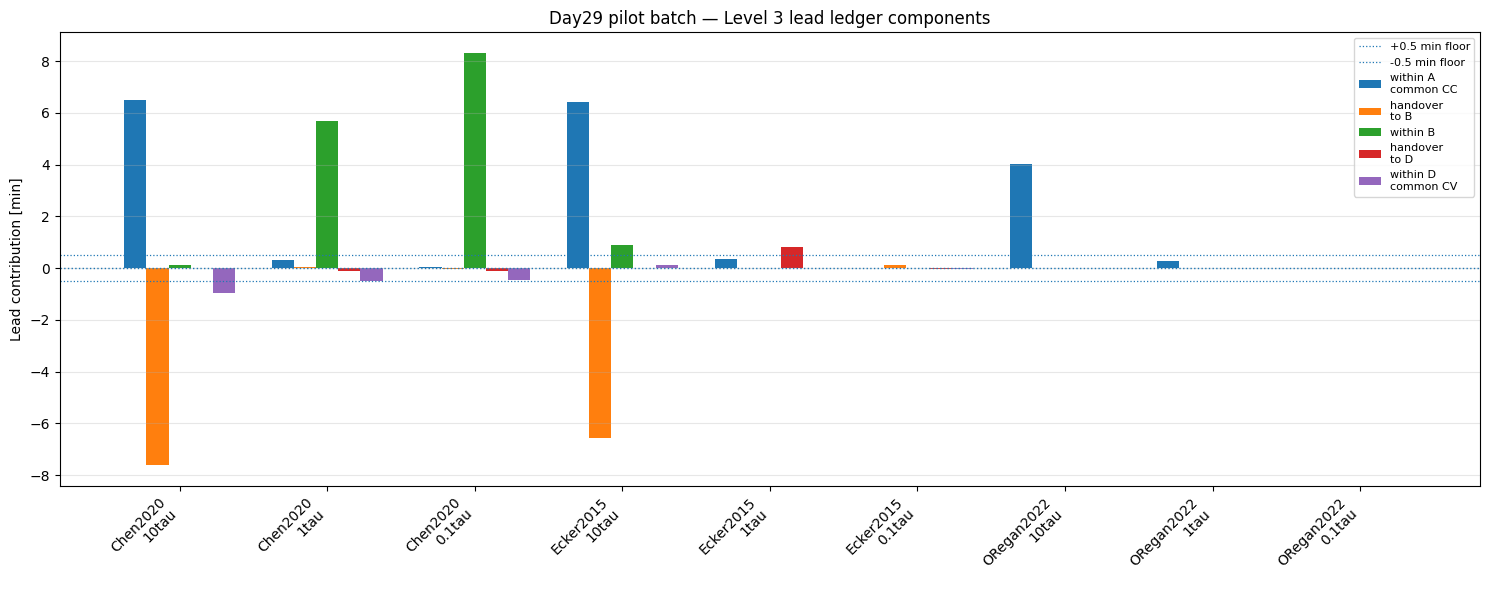

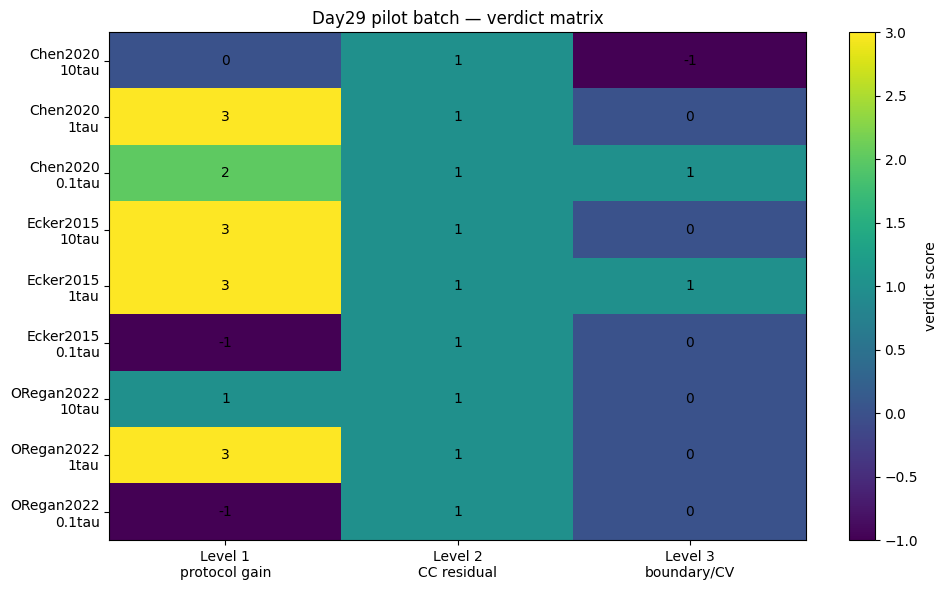

,case_label,level1_verdict_corrected,level1_score,level2_verdict,level2_score,level3_verdict_corrected,level3_score
0,Chen2020\n10tau,mid_trajectory_gain_but_endpoint_consumed,0,PASS_common_CC_geometry_dominated,1,A_to_B_handover_consumes_lead + D_common_CV_co...,-1
1,Chen2020\n1tau,broad_trajectory_and_endpoint_gain,3,PASS_common_CC_geometry_dominated,1,B_segment_adds_lead + D_common_CV_consumes_lead,0
2,Chen2020\n0.1tau,late_trajectory_and_endpoint_gain,2,PASS_common_CC_geometry_dominated,1,B_segment_adds_lead,1
3,Ecker2015\n10tau,broad_trajectory_and_endpoint_gain,3,PASS_common_CC_geometry_dominated,1,A_to_B_handover_consumes_lead + B_segment_adds...,0
4,Ecker2015\n1tau,broad_trajectory_and_endpoint_gain,3,PASS_common_CC_geometry_dominated,1,handover_to_D_adds_lead,1
5,Ecker2015\n0.1tau,weak_or_no_operational_gain,-1,PASS_common_CC_geometry_dominated,1,no_resolved_major_boundary_or_CV_contribution,0
6,ORegan2022\n10tau,endpoint_only_or_sparse_target_gain,1,PASS_common_CC_geometry_dominated,1,no_resolved_major_boundary_or_CV_contribution,0
7,ORegan2022\n1tau,broad_trajectory_and_endpoint_gain,3,PASS_common_CC_geometry_dominated,1,no_resolved_major_boundary_or_CV_contribution,0
8,ORegan2022\n0.1tau,weak_or_no_operational_gain,-1,PASS_common_CC_geometry_dominated,1,no_resolved_major_boundary_or_CV_contribution,0


[saved] data/day29_batch_pilot_level1_targets_v2.png (92826 bytes)
[saved] data/day29_batch_pilot_level2_residual_v2.png (80309 bytes)
[saved] data/day29_batch_pilot_level3_grouped_ledger_v2.png (106417 bytes)
[saved] data/day29_batch_pilot_verdict_matrix_v2.png (105018 bytes)
[OK] Batch summary figure v2 completed.


In [26]:
# Cell 15 — Batch summary figure v2（小批量审计汇总图 v2：分组柱状图 + 判据矩阵）

FIG_LEVEL1 = DATA_DIR / "day29_batch_pilot_level1_targets_v2.png"
FIG_LEVEL2 = DATA_DIR / "day29_batch_pilot_level2_residual_v2.png"
FIG_LEVEL3 = DATA_DIR / "day29_batch_pilot_level3_grouped_ledger_v2.png"
FIG_VERDICT = DATA_DIR / "day29_batch_pilot_verdict_matrix_v2.png"

df_plot = df_batch_verdict_corrected.copy()
df_plot["case_label"] = df_plot["parameter_set"] + "\n" + df_plot["freq_label"]

# Ensure plotting order: parameter set × frequency order
param_order = ["Chen2020", "Ecker2015", "ORegan2022"]
freq_order = ["10tau", "1tau", "0.1tau"]

df_plot["parameter_set"] = pd.Categorical(
    df_plot["parameter_set"],
    categories=param_order,
    ordered=True,
)
df_plot["freq_label"] = pd.Categorical(
    df_plot["freq_label"],
    categories=freq_order,
    ordered=True,
)

df_plot = df_plot.sort_values(["parameter_set", "freq_label"]).reset_index(drop=True)
df_plot["case_label"] = df_plot["parameter_set"].astype(str) + "\n" + df_plot["freq_label"].astype(str)

display(df_plot[
    [
        "parameter_set",
        "freq_label",
        "delta_t_SOC80_min",
        "delta_t_SOC90_min",
        "delta_t_SOC95_min",
        "delta_t_common_Q_end_min",
        "cc_resid_max_abs_s",
        "level1_verdict_corrected",
        "level2_verdict",
        "level3_verdict_corrected",
    ]
])


# -------------------------
# Figure 1 — Level 1 grouped targets
# -------------------------
x = np.arange(len(df_plot))
width = 0.18

fig, ax = plt.subplots(figsize=(14, 5.5))

ax.bar(x - 1.5 * width, df_plot["delta_t_SOC80_min"], width, label="SOC80")
ax.bar(x - 0.5 * width, df_plot["delta_t_SOC90_min"], width, label="SOC90")
ax.bar(x + 0.5 * width, df_plot["delta_t_SOC95_min"], width, label="SOC95")
ax.bar(x + 1.5 * width, df_plot["delta_t_common_Q_end_min"], width, label="common Q end")

ax.axhline(0.0, linestyle=":", linewidth=1.0)
ax.axhline(0.5, linestyle=":", linewidth=1.0, label="+0.5 min floor")

ax.set_title("Day29 pilot batch — Level 1 full-protocol state-equivalent time gain")
ax.set_ylabel("Δt_full(Q) [min]")
ax.set_xticks(x)
ax.set_xticklabels(df_plot["case_label"], rotation=45, ha="right")
ax.grid(True, axis="y", alpha=0.3)
ax.legend(loc="best")

plt.tight_layout()
plt.savefig(FIG_LEVEL1, dpi=200)
plt.show()


# -------------------------
# Figure 2 — Level 2 residual
# -------------------------
fig, ax = plt.subplots(figsize=(14, 4.8))

ax.bar(df_plot["case_label"], df_plot["cc_resid_max_abs_s"])
ax.axhline(5.0, linestyle=":", linewidth=1.2, label="5 s residual floor")

ax.set_title("Day29 pilot batch — Level 2 common-CC residual after geometry correction")
ax.set_ylabel("max |Δt_resid| [s]")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, axis="y", alpha=0.3)
ax.legend(loc="best")

plt.tight_layout()
plt.savefig(FIG_LEVEL2, dpi=200)
plt.show()


# -------------------------
# Figure 3 — Level 3 grouped ledger components
# -------------------------
ledger_cols = [
    "lead_within_A_common_prescribed_CC_min",
    "lead_handover_to_B_min",
    "lead_within_B_min",
    "lead_handover_to_D_min",
    "lead_within_D_common_CV_min",
]

ledger_labels = [
    "within A\ncommon CC",
    "handover\nto B",
    "within B",
    "handover\nto D",
    "within D\ncommon CV",
]

x = np.arange(len(df_plot))
width = 0.15

fig, ax = plt.subplots(figsize=(15, 6))

for i, (col, lab) in enumerate(zip(ledger_cols, ledger_labels)):
    values = df_plot[col].fillna(0.0).values
    ax.bar(
        x + (i - 2) * width,
        values,
        width,
        label=lab,
    )

ax.axhline(0.0, linestyle=":", linewidth=1.0)
ax.axhline(0.5, linestyle=":", linewidth=0.9, label="+0.5 min floor")
ax.axhline(-0.5, linestyle=":", linewidth=0.9, label="-0.5 min floor")

ax.set_title("Day29 pilot batch — Level 3 lead ledger components")
ax.set_ylabel("Lead contribution [min]")
ax.set_xticks(x)
ax.set_xticklabels(df_plot["case_label"], rotation=45, ha="right")
ax.grid(True, axis="y", alpha=0.3)
ax.legend(loc="best", fontsize=8)

plt.tight_layout()
plt.savefig(FIG_LEVEL3, dpi=200)
plt.show()


# -------------------------
# Figure 4 — Verdict matrix
# -------------------------
# Convert text verdicts into compact numeric classes for visualization.
level1_map = {
    "broad_trajectory_and_endpoint_gain": 3,
    "late_trajectory_and_endpoint_gain": 2,
    "endpoint_only_or_sparse_target_gain": 1,
    "mid_trajectory_gain_but_endpoint_consumed": 0,
    "partial_trajectory_gain_without_endpoint_preservation": 0,
    "weak_or_no_operational_gain": -1,
    "invalid_no_common_targets": -2,
}

level2_map = {
    "PASS_common_CC_geometry_dominated": 1,
    "CHECK_residual_exceeds_floor": -1,
}

def level3_score(text):
    if not isinstance(text, str):
        return 0
    score = 0
    if "adds_lead" in text or "adds" in text:
        score += 1
    if "consumes" in text:
        score -= 1
    if "no_resolved" in text:
        score = 0
    return score

df_verdict_matrix = df_plot.copy()
df_verdict_matrix["level1_score"] = df_verdict_matrix["level1_verdict_corrected"].map(level1_map).fillna(0)
df_verdict_matrix["level2_score"] = df_verdict_matrix["level2_verdict"].map(level2_map).fillna(0)
df_verdict_matrix["level3_score"] = df_verdict_matrix["level3_verdict_corrected"].apply(level3_score)

matrix = df_verdict_matrix[["level1_score", "level2_score", "level3_score"]].to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(matrix, aspect="auto")
ax.set_title("Day29 pilot batch — verdict matrix")
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["Level 1\nprotocol gain", "Level 2\nCC residual", "Level 3\nboundary/CV"])
ax.set_yticks(np.arange(len(df_verdict_matrix)))
ax.set_yticklabels(df_verdict_matrix["case_label"])

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        ax.text(j, i, f"{matrix[i, j]:.0f}", ha="center", va="center")

plt.colorbar(im, ax=ax, label="verdict score")
plt.tight_layout()
plt.savefig(FIG_VERDICT, dpi=200)
plt.show()

display(df_verdict_matrix[
    [
        "case_label",
        "level1_verdict_corrected",
        "level1_score",
        "level2_verdict",
        "level2_score",
        "level3_verdict_corrected",
        "level3_score",
    ]
])

for p in [FIG_LEVEL1, FIG_LEVEL2, FIG_LEVEL3, FIG_VERDICT]:
    assert p.exists(), f"Missing figure: {p}"
    print("[saved]", p.relative_to(REPO), f"({p.stat().st_size} bytes)")

print("[OK] Batch summary figure v2 completed.")

,parameter_set,freq_label,pair_id,t_vmax_DC_min,t_vmax_DCAC_min,Q_vmax_DC_Ah,Q_vmax_DCAC_Ah,delta_t_SOC80_min,delta_t_SOC90_min,delta_t_SOC95_min,delta_t_common_Q_end_min,level1_verdict_corrected
6,ORegan2022,10tau,P01_0p3DC_vs_0p3p0p7_10tau,184.543601,120.004303,4.61359,3.156368,NaN,NaN,NaN,6.250419,endpoint_only_or_sparse_target_gain
7,ORegan2022,1tau,P02_0p3DC_vs_0p3p0p7_1tau,184.543608,182.909508,4.61359,4.590177,0.761077,0.858506,0.617809,0.697590,broad_trajectory_and_endpoint_gain
8,ORegan2022,0.1tau,P03_0p3DC_vs_0p3p0p7_0p1tau,184.543608,184.258681,4.61359,4.607028,0.028896,0.033547,0.035987,0.022445,weak_or_no_operational_gain


,parameter_set,pair_id,branch,t_vmax_min,Q_vmax_Ah,t_end_min,Q_end_Ah,I_end_A,I_end_C,termination
12,ORegan2022,P01_0p3DC_vs_0p3p0p7_10tau,DC,184.543601,4.613590,184.543601,4.613590,-5.084350,-1.016870,already_below_cutoff_at_CV_start
13,ORegan2022,P01_0p3DC_vs_0p3p0p7_10tau,DCAC,120.004303,3.156368,120.004303,3.156368,-0.636135,-0.127227,already_below_cutoff_at_CV_start
14,ORegan2022,P02_0p3DC_vs_0p3p0p7_1tau,DC,184.543608,4.613590,184.543608,4.613590,-5.084399,-1.016880,already_below_cutoff_at_CV_start
15,ORegan2022,P02_0p3DC_vs_0p3p0p7_1tau,DCAC,182.909508,4.590177,182.909508,4.590177,-4.530127,-0.906025,already_below_cutoff_at_CV_start
16,ORegan2022,P03_0p3DC_vs_0p3p0p7_0p1tau,DC,184.543608,4.613590,184.543608,4.613590,-5.084421,-1.016884,already_below_cutoff_at_CV_start
17,ORegan2022,P03_0p3DC_vs_0p3p0p7_0p1tau,DCAC,184.258681,4.607028,184.258681,4.607028,-2.811273,-0.562255,already_below_cutoff_at_CV_start


,pair_id,Q_nom_Ah,Q_end_DC_Ah,Q_end_DCAC_Ah,Q_common_end_Ah,SOC_common_end_nominal_est,Q_SOC80_target_Ah,Q_SOC90_target_Ah,Q_SOC95_target_Ah,SOC80_inside_common_window,SOC90_inside_common_window,SOC95_inside_common_window
0,P01_0p3DC_vs_0p3p0p7_10tau,5.0,4.61359,3.156368,3.156368,0.681274,3.75,4.25,4.5,False,False,False
1,P02_0p3DC_vs_0p3p0p7_1tau,5.0,4.61359,4.590177,4.590177,0.968035,3.75,4.25,4.5,True,True,True
2,P03_0p3DC_vs_0p3p0p7_0p1tau,5.0,4.61359,4.607028,4.607028,0.971406,3.75,4.25,4.5,True,True,True


,parameter_set,pair_id,Q_Ah,Q_frac_nominal_increment,SOC_nominal_est,t_DC_s,t_DCAC_s,t_DC_min,t_DCAC_min,delta_t_full_s,delta_t_full_min,control_state_DC_Qbased,control_state_DCAC_Qbased,segment_label_Qbased,control_state_DC_timebased,control_state_DCAC_timebased,segment_label_timebased
840,ORegan2022,P01_0p3DC_vs_0p3p0p7_10tau,0.100000,0.020000,0.070000,240.000000,114.332832,4.000000,1.905547,125.667168,2.094453,CC,AC_on_CC,A_common_CC,CC,AC_on_CC,A_common_prescribed_CC
841,ORegan2022,P01_0p3DC_vs_0p3p0p7_10tau,0.121952,0.024390,0.074390,292.685491,131.412419,4.878092,2.190207,161.273072,2.687885,CC,AC_on_CC,A_common_CC,CC,AC_on_CC,A_common_prescribed_CC
842,ORegan2022,P01_0p3DC_vs_0p3p0p7_10tau,0.143905,0.028781,0.078781,345.370983,147.786336,5.756183,2.463106,197.584647,3.293077,CC,AC_on_CC,A_common_CC,CC,AC_on_CC,A_common_prescribed_CC
843,ORegan2022,P01_0p3DC_vs_0p3p0p7_10tau,0.165857,0.033171,0.083171,398.056474,163.758312,6.634275,2.729305,234.298162,3.904969,CC,AC_on_CC,A_common_CC,CC,AC_on_CC,A_common_prescribed_CC
844,ORegan2022,P01_0p3DC_vs_0p3p0p7_10tau,0.187809,0.037562,0.087562,450.741966,179.577102,7.512366,2.992952,271.164863,4.519414,CC,AC_on_CC,A_common_CC,CC,AC_on_CC,A_common_prescribed_CC


,parameter_set,pair_id,Q_Ah,Q_frac_nominal_increment,SOC_nominal_est,t_DC_s,t_DCAC_s,t_DC_min,t_DCAC_min,delta_t_full_s,delta_t_full_min,control_state_DC_Qbased,control_state_DCAC_Qbased,segment_label_Qbased,control_state_DC_timebased,control_state_DCAC_timebased,segment_label_timebased
975,ORegan2022,P01_0p3DC_vs_0p3p0p7_10tau,3.063559,0.612712,0.662712,7352.541341,7132.106792,122.542356,118.868447,220.434549,3.673909,CC,AC_on_CC,A_common_CC,CC,AC_on_CC,A_common_prescribed_CC
976,ORegan2022,P01_0p3DC_vs_0p3p0p7_10tau,3.085511,0.617102,0.667102,7405.226833,7147.955989,123.420447,119.132600,257.270844,4.287847,CC,AC_on_CC,A_common_CC,CC,AC_on_CC,A_common_prescribed_CC
977,ORegan2022,P01_0p3DC_vs_0p3p0p7_10tau,3.107463,0.621493,0.671493,7457.912324,7163.794669,124.298539,119.396578,294.117655,4.901961,CC,AC_on_CC,A_common_CC,CC,AC_on_CC,A_common_prescribed_CC
978,ORegan2022,P01_0p3DC_vs_0p3p0p7_10tau,3.129416,0.625883,0.675883,7510.597815,7179.853456,125.176630,119.664224,330.744360,5.512406,CC,AC_on_CC,A_common_CC,CC,AC_on_CC,A_common_prescribed_CC
979,ORegan2022,P01_0p3DC_vs_0p3p0p7_10tau,3.151368,0.630274,0.680274,7563.283307,7196.392811,126.054722,119.939880,366.890496,6.114842,CC,AC_on_CC,A_common_CC,CC,AC_on_CC,A_common_prescribed_CC


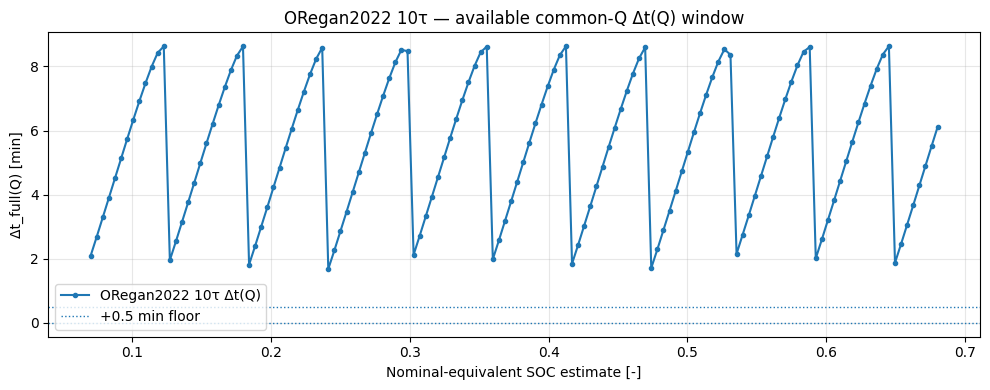

[OK] ORegan2022 sparse-window diagnostic completed.


In [27]:
# Cell 16 — ORegan2022 sparse-window diagnostic（ORegan2022共同Q窗口诊断）

diagnostic_cases = df_batch_verdict_corrected[
    df_batch_verdict_corrected["parameter_set"].astype(str).eq("ORegan2022")
].copy()

display(diagnostic_cases[
    [
        "parameter_set",
        "freq_label",
        "pair_id",
        "t_vmax_DC_min",
        "t_vmax_DCAC_min",
        "Q_vmax_DC_Ah",
        "Q_vmax_DCAC_Ah",
        "delta_t_SOC80_min",
        "delta_t_SOC90_min",
        "delta_t_SOC95_min",
        "delta_t_common_Q_end_min",
        "level1_verdict_corrected",
    ]
])

# Pull full protocol branch summary for ORegan2022
df_oregan_full = df_batch_full_summary[
    df_batch_full_summary["parameter_set"].eq("ORegan2022")
].copy()

display(df_oregan_full)

# Compute common Q end and corresponding nominal SOC estimate
rows = []
for pair_id, g in df_oregan_full.groupby("pair_id"):
    if set(g["branch"]) != {"DC", "DCAC"}:
        continue

    q_end_dc = float(g.loc[g["branch"] == "DC", "Q_end_Ah"].iloc[0])
    q_end_dcac = float(g.loc[g["branch"] == "DCAC", "Q_end_Ah"].iloc[0])
    q_common_end = min(q_end_dc, q_end_dcac)

    q_nom = float(PARAM_VALUES["ORegan2022"]["Nominal cell capacity [A.h]"])
    initial_soc = 0.05

    rows.append({
        "pair_id": pair_id,
        "Q_nom_Ah": q_nom,
        "Q_end_DC_Ah": q_end_dc,
        "Q_end_DCAC_Ah": q_end_dcac,
        "Q_common_end_Ah": q_common_end,
        "SOC_common_end_nominal_est": initial_soc + q_common_end / q_nom,
        "Q_SOC80_target_Ah": (0.80 - initial_soc) * q_nom,
        "Q_SOC90_target_Ah": (0.90 - initial_soc) * q_nom,
        "Q_SOC95_target_Ah": (0.95 - initial_soc) * q_nom,
        "SOC80_inside_common_window": q_common_end >= (0.80 - initial_soc) * q_nom,
        "SOC90_inside_common_window": q_common_end >= (0.90 - initial_soc) * q_nom,
        "SOC95_inside_common_window": q_common_end >= (0.95 - initial_soc) * q_nom,
    })

df_oregan_window = pd.DataFrame(rows)
display(df_oregan_window)

# Inspect ORegan2022 10tau Δt(Q) range
df_oregan10_dtq = df_batch_dtq[
    (df_batch_dtq["parameter_set"].eq("ORegan2022"))
    & (df_batch_dtq["pair_id"].eq("P01_0p3DC_vs_0p3p0p7_10tau"))
].copy()

display(df_oregan10_dtq.head())
display(df_oregan10_dtq.tail())

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    df_oregan10_dtq["SOC_nominal_est"],
    df_oregan10_dtq["delta_t_full_min"],
    marker=".",
    label="ORegan2022 10τ Δt(Q)",
)

ax.axhline(0.0, linestyle=":", linewidth=1.0)
ax.axhline(0.5, linestyle=":", linewidth=1.0, label="+0.5 min floor")
ax.set_title("ORegan2022 10τ — available common-Q Δt(Q) window")
ax.set_xlabel("Nominal-equivalent SOC estimate [-]")
ax.set_ylabel("Δt_full(Q) [min]")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")

plt.tight_layout()
plt.show()

print("[OK] ORegan2022 sparse-window diagnostic completed.")

In [28]:
# Cell 17 — Add truncation and CV-validity flags
# （添加共同窗口截断与CV有效性解释标记）

def build_common_window_and_cv_flags(df_full_summary, df_verdict):
    rows = []

    for _, vrow in df_verdict.iterrows():
        parameter_set = str(vrow["parameter_set"])
        pair_id = vrow["pair_id"]

        g = df_full_summary[
            (df_full_summary["parameter_set"].astype(str).eq(parameter_set))
            & (df_full_summary["pair_id"].eq(pair_id))
        ].copy()

        if g.empty or set(g["branch"]) != {"DC", "DCAC"}:
            rows.append({
                "parameter_set": parameter_set,
                "pair_id": pair_id,
                "flag_status": "missing_branch_summary",
            })
            continue

        q_nom = float(PARAM_VALUES[parameter_set]["Nominal cell capacity [A.h]"])
        initial_soc = 0.05

        dc = g[g["branch"].eq("DC")].iloc[0]
        dcac = g[g["branch"].eq("DCAC")].iloc[0]

        q_end_dc = float(dc["Q_end_Ah"])
        q_end_dcac = float(dcac["Q_end_Ah"])
        q_common_end = min(q_end_dc, q_end_dcac)
        soc_common_end = initial_soc + q_common_end / q_nom

        q_soc80 = (0.80 - initial_soc) * q_nom
        q_soc90 = (0.90 - initial_soc) * q_nom
        q_soc95 = (0.95 - initial_soc) * q_nom

        soc80_covered = q_common_end >= q_soc80
        soc90_covered = q_common_end >= q_soc90
        soc95_covered = q_common_end >= q_soc95

        if not soc80_covered:
            target_window_class = "truncated_below_SOC80"
        elif soc80_covered and not soc90_covered:
            target_window_class = "covers_SOC80_only"
        elif soc90_covered and not soc95_covered:
            target_window_class = "covers_SOC80_SOC90"
        else:
            target_window_class = "covers_SOC80_SOC90_SOC95"

        dc_term = str(dc["termination"])
        dcac_term = str(dcac["termination"])

        dc_i_end_c = float(dc["I_end_C"])
        dcac_i_end_c = float(dcac["I_end_C"])

        dc_zero_or_noncharging = (
            "already_below_cutoff_at_CV_start" in dc_term
            or dc_i_end_c <= 0
        )

        dcac_zero_or_noncharging = (
            "already_below_cutoff_at_CV_start" in dcac_term
            or dcac_i_end_c <= 0
        )

        if dc_zero_or_noncharging or dcac_zero_or_noncharging:
            cv_control_class = "zero_duration_or_noncharging_CV"
        else:
            cv_control_class = "normal_CV_continuation"

        if target_window_class == "truncated_below_SOC80":
            comparability_class = "exclude_from_fixed_SOC80_90_95_comparison"
        elif cv_control_class != "normal_CV_continuation":
            comparability_class = "fixed_SOC_targets_ok_but_not_normal_full_CV"
        else:
            comparability_class = "normal_full_CC_CV_comparable"

        rows.append({
            "parameter_set": parameter_set,
            "pair_id": pair_id,
            "Q_nom_Ah": q_nom,
            "Q_end_DC_Ah": q_end_dc,
            "Q_end_DCAC_Ah": q_end_dcac,
            "Q_common_end_Ah": q_common_end,
            "SOC_common_end_nominal_est": soc_common_end,
            "SOC80_covered": soc80_covered,
            "SOC90_covered": soc90_covered,
            "SOC95_covered": soc95_covered,
            "target_window_class": target_window_class,
            "termination_DC": dc_term,
            "termination_DCAC": dcac_term,
            "I_end_C_DC": dc_i_end_c,
            "I_end_C_DCAC": dcac_i_end_c,
            "cv_control_class": cv_control_class,
            "comparability_class": comparability_class,
            "flag_status": "ok",
        })

    return pd.DataFrame(rows)


df_batch_flags = build_common_window_and_cv_flags(
    df_full_summary=df_batch_full_summary,
    df_verdict=df_batch_verdict_corrected,
)

display(df_batch_flags)

df_batch_verdict_flagged = df_batch_verdict_corrected.merge(
    df_batch_flags,
    on=["parameter_set", "pair_id"],
    how="left",
)

compact_flag_cols = [
    "parameter_set",
    "freq_label",
    "delta_t_SOC80_min",
    "delta_t_SOC90_min",
    "delta_t_SOC95_min",
    "delta_t_common_Q_end_min",
    "SOC_common_end_nominal_est",
    "target_window_class",
    "cv_control_class",
    "comparability_class",
    "level1_verdict_corrected",
    "level2_verdict",
]

display(df_batch_verdict_flagged[compact_flag_cols])

OUT_BATCH_VERDICT_FLAGGED = DATA_DIR / "day29_batch_pilot_verdict_summary_flagged.csv"
df_batch_verdict_flagged.to_csv(OUT_BATCH_VERDICT_FLAGGED, index=False)

print("[saved]", OUT_BATCH_VERDICT_FLAGGED.relative_to(REPO), f"({OUT_BATCH_VERDICT_FLAGGED.stat().st_size} bytes)")
print("[OK] Truncation and CV-validity flags added.")

,parameter_set,pair_id,Q_nom_Ah,Q_end_DC_Ah,Q_end_DCAC_Ah,Q_common_end_Ah,SOC_common_end_nominal_est,SOC80_covered,SOC90_covered,SOC95_covered,target_window_class,termination_DC,termination_DCAC,I_end_C_DC,I_end_C_DCAC,cv_control_class,comparability_class,flag_status
0,Chen2020,P01_0p3DC_vs_0p3p0p7_10tau,5.00000,4.872670,4.872023,4.872023,1.024405,True,True,True,covers_SOC80_SOC90_SOC95,event: Charge current cutoff [A],event: Charge current cutoff [A],0.014708,0.014708,normal_CV_continuation,normal_full_CC_CV_comparable,ok
1,Chen2020,P02_0p3DC_vs_0p3p0p7_1tau,5.00000,4.872670,4.872563,4.872563,1.024513,True,True,True,covers_SOC80_SOC90_SOC95,event: Charge current cutoff [A],event: Charge current cutoff [A],0.014708,0.014708,normal_CV_continuation,normal_full_CC_CV_comparable,ok
2,Chen2020,P03_0p3DC_vs_0p3p0p7_0p1tau,5.00000,4.872670,4.872655,4.872655,1.024531,True,True,True,covers_SOC80_SOC90_SOC95,event: Charge current cutoff [A],event: Charge current cutoff [A],0.014708,0.014708,normal_CV_continuation,normal_full_CC_CV_comparable,ok
3,Ecker2015,P01_0p3DC_vs_0p3p0p7_10tau,0.15625,0.162305,0.162311,0.162305,1.088753,True,True,True,covers_SOC80_SOC90_SOC95,event: Charge current cutoff [A],event: Charge current cutoff [A],0.014770,0.014770,normal_CV_continuation,normal_full_CC_CV_comparable,ok
4,Ecker2015,P02_0p3DC_vs_0p3p0p7_1tau,0.15625,0.162305,0.162302,0.162302,1.088736,True,True,True,covers_SOC80_SOC90_SOC95,event: Charge current cutoff [A],event: Charge current cutoff [A],0.014770,0.014770,normal_CV_continuation,normal_full_CC_CV_comparable,ok
5,Ecker2015,P03_0p3DC_vs_0p3p0p7_0p1tau,0.15625,0.162305,0.162305,0.162305,1.088751,True,True,True,covers_SOC80_SOC90_SOC95,event: Charge current cutoff [A],event: Charge current cutoff [A],0.014770,0.014770,normal_CV_continuation,normal_full_CC_CV_comparable,ok
6,ORegan2022,P01_0p3DC_vs_0p3p0p7_10tau,5.00000,4.613590,3.156368,3.156368,0.681274,False,False,False,truncated_below_SOC80,already_below_cutoff_at_CV_start,already_below_cutoff_at_CV_start,-1.016870,-0.127227,zero_duration_or_noncharging_CV,exclude_from_fixed_SOC80_90_95_comparison,ok
7,ORegan2022,P02_0p3DC_vs_0p3p0p7_1tau,5.00000,4.613590,4.590177,4.590177,0.968035,True,True,True,covers_SOC80_SOC90_SOC95,already_below_cutoff_at_CV_start,already_below_cutoff_at_CV_start,-1.016880,-0.906025,zero_duration_or_noncharging_CV,fixed_SOC_targets_ok_but_not_normal_full_CV,ok
8,ORegan2022,P03_0p3DC_vs_0p3p0p7_0p1tau,5.00000,4.613590,4.607028,4.607028,0.971406,True,True,True,covers_SOC80_SOC90_SOC95,already_below_cutoff_at_CV_start,already_below_cutoff_at_CV_start,-1.016884,-0.562255,zero_duration_or_noncharging_CV,fixed_SOC_targets_ok_but_not_normal_full_CV,ok


,parameter_set,freq_label,delta_t_SOC80_min,delta_t_SOC90_min,delta_t_SOC95_min,delta_t_common_Q_end_min,SOC_common_end_nominal_est,target_window_class,cv_control_class,comparability_class,level1_verdict_corrected,level2_verdict
0,Chen2020,10tau,6.584072,4.346633,1.085225,0.088303,1.024405,covers_SOC80_SOC90_SOC95,normal_CV_continuation,normal_full_CC_CV_comparable,mid_trajectory_gain_but_endpoint_consumed,PASS_common_CC_geometry_dominated
1,Chen2020,1tau,0.761077,4.712095,6.266877,5.700024,1.024513,covers_SOC80_SOC90_SOC95,normal_CV_continuation,normal_full_CC_CV_comparable,broad_trajectory_and_endpoint_gain,PASS_common_CC_geometry_dominated
2,Chen2020,0.1tau,0.028896,6.853433,8.336158,7.823475,1.024531,covers_SOC80_SOC90_SOC95,normal_CV_continuation,normal_full_CC_CV_comparable,late_trajectory_and_endpoint_gain,PASS_common_CC_geometry_dominated
3,Ecker2015,10tau,6.584072,4.346633,3.213642,3.118144,1.088753,covers_SOC80_SOC90_SOC95,normal_CV_continuation,normal_full_CC_CV_comparable,broad_trajectory_and_endpoint_gain,PASS_common_CC_geometry_dominated
4,Ecker2015,1tau,0.761077,0.858506,0.617809,1.394133,1.088736,covers_SOC80_SOC90_SOC95,normal_CV_continuation,normal_full_CC_CV_comparable,broad_trajectory_and_endpoint_gain,PASS_common_CC_geometry_dominated
5,Ecker2015,0.1tau,0.028896,0.033547,0.035987,0.157656,1.088751,covers_SOC80_SOC90_SOC95,normal_CV_continuation,normal_full_CC_CV_comparable,weak_or_no_operational_gain,PASS_common_CC_geometry_dominated
6,ORegan2022,10tau,NaN,NaN,NaN,6.250419,0.681274,truncated_below_SOC80,zero_duration_or_noncharging_CV,exclude_from_fixed_SOC80_90_95_comparison,endpoint_only_or_sparse_target_gain,PASS_common_CC_geometry_dominated
7,ORegan2022,1tau,0.761077,0.858506,0.617809,0.697590,0.968035,covers_SOC80_SOC90_SOC95,zero_duration_or_noncharging_CV,fixed_SOC_targets_ok_but_not_normal_full_CV,broad_trajectory_and_endpoint_gain,PASS_common_CC_geometry_dominated
8,ORegan2022,0.1tau,0.028896,0.033547,0.035987,0.022445,0.971406,covers_SOC80_SOC90_SOC95,zero_duration_or_noncharging_CV,fixed_SOC_targets_ok_but_not_normal_full_CV,weak_or_no_operational_gain,PASS_common_CC_geometry_dominated


[saved] data/day29_batch_pilot_verdict_summary_flagged.csv (9561 bytes)
[OK] Truncation and CV-validity flags added.


[normal full CC-CV comparable cases]


,parameter_set,freq_label,delta_t_SOC80_min,delta_t_SOC90_min,delta_t_SOC95_min,delta_t_common_Q_end_min,comparability_class,level1_verdict_corrected,level2_verdict
0,Chen2020,10tau,6.584072,4.346633,1.085225,0.088303,normal_full_CC_CV_comparable,mid_trajectory_gain_but_endpoint_consumed,PASS_common_CC_geometry_dominated
1,Chen2020,1tau,0.761077,4.712095,6.266877,5.700024,normal_full_CC_CV_comparable,broad_trajectory_and_endpoint_gain,PASS_common_CC_geometry_dominated
2,Chen2020,0.1tau,0.028896,6.853433,8.336158,7.823475,normal_full_CC_CV_comparable,late_trajectory_and_endpoint_gain,PASS_common_CC_geometry_dominated
3,Ecker2015,10tau,6.584072,4.346633,3.213642,3.118144,normal_full_CC_CV_comparable,broad_trajectory_and_endpoint_gain,PASS_common_CC_geometry_dominated
4,Ecker2015,1tau,0.761077,0.858506,0.617809,1.394133,normal_full_CC_CV_comparable,broad_trajectory_and_endpoint_gain,PASS_common_CC_geometry_dominated
5,Ecker2015,0.1tau,0.028896,0.033547,0.035987,0.157656,normal_full_CC_CV_comparable,weak_or_no_operational_gain,PASS_common_CC_geometry_dominated


[non-normal / diagnostic cases]


,parameter_set,freq_label,delta_t_SOC80_min,delta_t_SOC90_min,delta_t_SOC95_min,delta_t_common_Q_end_min,SOC_common_end_nominal_est,target_window_class,cv_control_class,comparability_class
6,ORegan2022,10tau,NaN,NaN,NaN,6.250419,0.681274,truncated_below_SOC80,zero_duration_or_noncharging_CV,exclude_from_fixed_SOC80_90_95_comparison
7,ORegan2022,1tau,0.761077,0.858506,0.617809,0.697590,0.968035,covers_SOC80_SOC90_SOC95,zero_duration_or_noncharging_CV,fixed_SOC_targets_ok_but_not_normal_full_CV
8,ORegan2022,0.1tau,0.028896,0.033547,0.035987,0.022445,0.971406,covers_SOC80_SOC90_SOC95,zero_duration_or_noncharging_CV,fixed_SOC_targets_ok_but_not_normal_full_CV


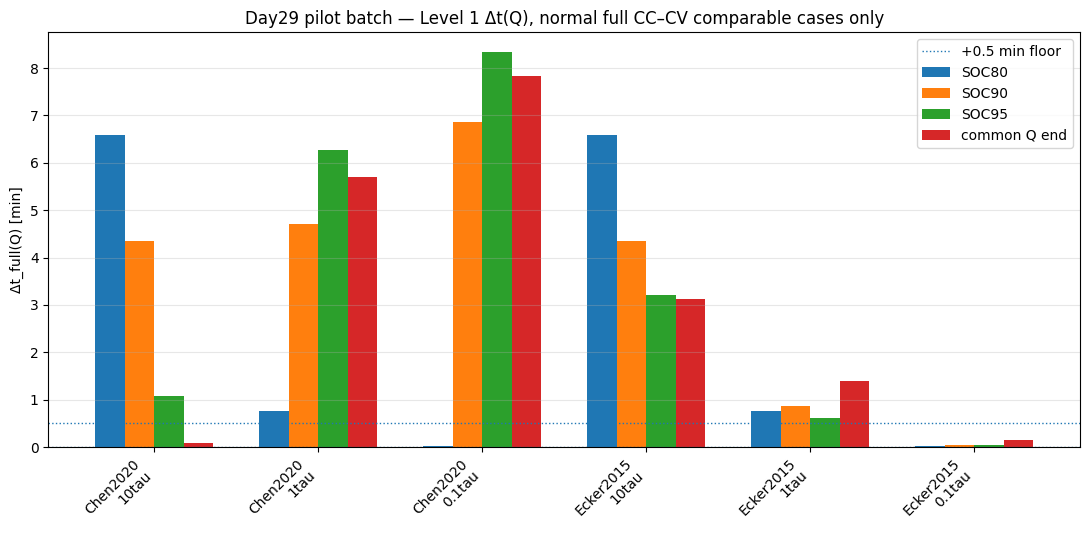

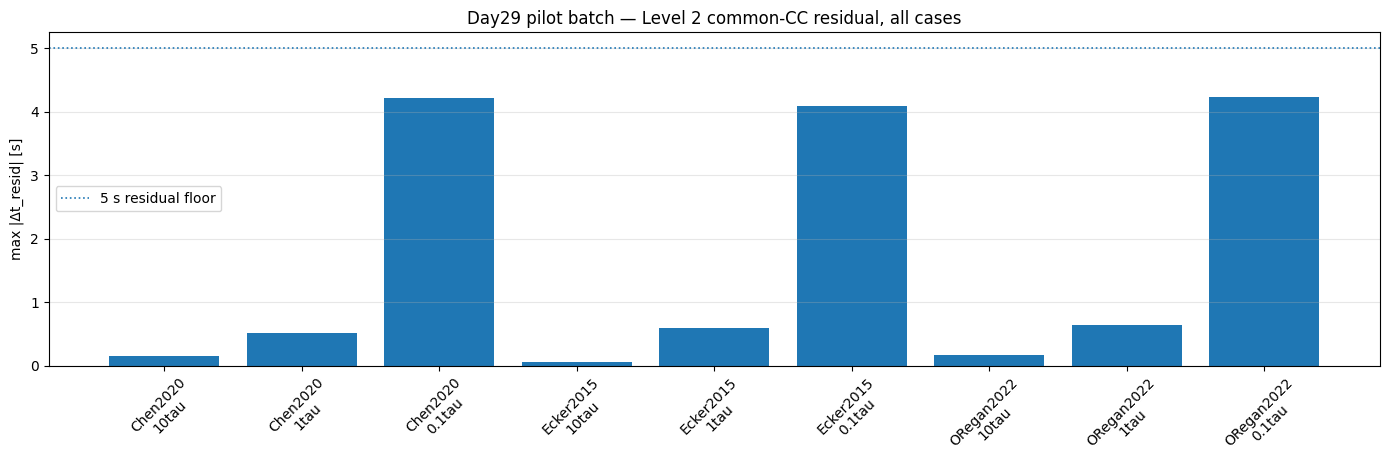

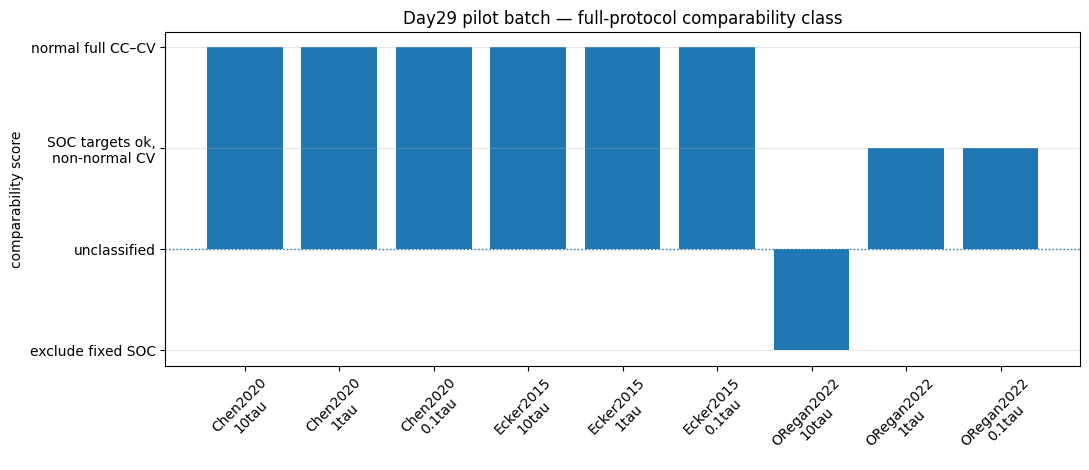

,parameter_set,freq_label,pair_id,delta_t_SOC80_min,delta_t_SOC90_min,delta_t_SOC95_min,delta_t_common_Q_end_min,cc_resid_max_abs_s,target_window_class,cv_control_class,comparability_class,level1_verdict_corrected,level2_verdict,level3_verdict_corrected
0,Chen2020,10tau,P01_0p3DC_vs_0p3p0p7_10tau,6.584072,4.346633,1.085225,0.088303,0.147257,covers_SOC80_SOC90_SOC95,normal_CV_continuation,normal_full_CC_CV_comparable,mid_trajectory_gain_but_endpoint_consumed,PASS_common_CC_geometry_dominated,A_to_B_handover_consumes_lead + D_common_CV_co...
1,Chen2020,1tau,P02_0p3DC_vs_0p3p0p7_1tau,0.761077,4.712095,6.266877,5.700024,0.517577,covers_SOC80_SOC90_SOC95,normal_CV_continuation,normal_full_CC_CV_comparable,broad_trajectory_and_endpoint_gain,PASS_common_CC_geometry_dominated,B_segment_adds_lead + D_common_CV_consumes_lead
2,Chen2020,0.1tau,P03_0p3DC_vs_0p3p0p7_0p1tau,0.028896,6.853433,8.336158,7.823475,4.214534,covers_SOC80_SOC90_SOC95,normal_CV_continuation,normal_full_CC_CV_comparable,late_trajectory_and_endpoint_gain,PASS_common_CC_geometry_dominated,B_segment_adds_lead
3,Ecker2015,10tau,P01_0p3DC_vs_0p3p0p7_10tau,6.584072,4.346633,3.213642,3.118144,0.050058,covers_SOC80_SOC90_SOC95,normal_CV_continuation,normal_full_CC_CV_comparable,broad_trajectory_and_endpoint_gain,PASS_common_CC_geometry_dominated,A_to_B_handover_consumes_lead + B_segment_adds...
4,Ecker2015,1tau,P02_0p3DC_vs_0p3p0p7_1tau,0.761077,0.858506,0.617809,1.394133,0.584060,covers_SOC80_SOC90_SOC95,normal_CV_continuation,normal_full_CC_CV_comparable,broad_trajectory_and_endpoint_gain,PASS_common_CC_geometry_dominated,handover_to_D_adds_lead
5,Ecker2015,0.1tau,P03_0p3DC_vs_0p3p0p7_0p1tau,0.028896,0.033547,0.035987,0.157656,4.085635,covers_SOC80_SOC90_SOC95,normal_CV_continuation,normal_full_CC_CV_comparable,weak_or_no_operational_gain,PASS_common_CC_geometry_dominated,no_resolved_major_boundary_or_CV_contribution
6,ORegan2022,10tau,P01_0p3DC_vs_0p3p0p7_10tau,NaN,NaN,NaN,6.250419,0.165625,truncated_below_SOC80,zero_duration_or_noncharging_CV,exclude_from_fixed_SOC80_90_95_comparison,endpoint_only_or_sparse_target_gain,PASS_common_CC_geometry_dominated,no_resolved_major_boundary_or_CV_contribution
7,ORegan2022,1tau,P02_0p3DC_vs_0p3p0p7_1tau,0.761077,0.858506,0.617809,0.697590,0.644911,covers_SOC80_SOC90_SOC95,zero_duration_or_noncharging_CV,fixed_SOC_targets_ok_but_not_normal_full_CV,broad_trajectory_and_endpoint_gain,PASS_common_CC_geometry_dominated,no_resolved_major_boundary_or_CV_contribution
8,ORegan2022,0.1tau,P03_0p3DC_vs_0p3p0p7_0p1tau,0.028896,0.033547,0.035987,0.022445,4.233167,covers_SOC80_SOC90_SOC95,zero_duration_or_noncharging_CV,fixed_SOC_targets_ok_but_not_normal_full_CV,weak_or_no_operational_gain,PASS_common_CC_geometry_dominated,no_resolved_major_boundary_or_CV_contribution


[saved] data/day29_batch_pilot_level1_normal_comparable_only.png (84949 bytes)
[saved] data/day29_batch_pilot_level2_all_cases.png (77411 bytes)
[saved] data/day29_batch_pilot_comparability_flags.png (88420 bytes)
[saved] data/day29_batch_pilot_final_compact_summary.csv (3200 bytes)
[OK] Flag-aware final batch summary completed.


In [29]:
# Cell 18 — Flag-aware final batch summary（带可比性标记的最终小批量汇总）

FIG_LEVEL1_NORMAL = DATA_DIR / "day29_batch_pilot_level1_normal_comparable_only.png"
FIG_LEVEL2_ALL = DATA_DIR / "day29_batch_pilot_level2_all_cases.png"
FIG_LEVEL1_FLAGS = DATA_DIR / "day29_batch_pilot_comparability_flags.png"

df_flagged = df_batch_verdict_flagged.copy()

# Sort order
param_order = ["Chen2020", "Ecker2015", "ORegan2022"]
freq_order = ["10tau", "1tau", "0.1tau"]

df_flagged["parameter_set"] = pd.Categorical(
    df_flagged["parameter_set"].astype(str),
    categories=param_order,
    ordered=True,
)
df_flagged["freq_label"] = pd.Categorical(
    df_flagged["freq_label"].astype(str),
    categories=freq_order,
    ordered=True,
)

df_flagged = df_flagged.sort_values(["parameter_set", "freq_label"]).reset_index(drop=True)
df_flagged["case_label"] = df_flagged["parameter_set"].astype(str) + "\n" + df_flagged["freq_label"].astype(str)

df_normal = df_flagged[
    df_flagged["comparability_class"].eq("normal_full_CC_CV_comparable")
].copy()

df_non_normal = df_flagged[
    ~df_flagged["comparability_class"].eq("normal_full_CC_CV_comparable")
].copy()

print("[normal full CC-CV comparable cases]")
display(df_normal[
    [
        "parameter_set",
        "freq_label",
        "delta_t_SOC80_min",
        "delta_t_SOC90_min",
        "delta_t_SOC95_min",
        "delta_t_common_Q_end_min",
        "comparability_class",
        "level1_verdict_corrected",
        "level2_verdict",
    ]
])

print("[non-normal / diagnostic cases]")
display(df_non_normal[
    [
        "parameter_set",
        "freq_label",
        "delta_t_SOC80_min",
        "delta_t_SOC90_min",
        "delta_t_SOC95_min",
        "delta_t_common_Q_end_min",
        "SOC_common_end_nominal_est",
        "target_window_class",
        "cv_control_class",
        "comparability_class",
    ]
])


# ------------------------------------------------------------
# Figure 1 — Level 1 only for normal full CC-CV comparable cases
# ------------------------------------------------------------
x = np.arange(len(df_normal))
width = 0.18

fig, ax = plt.subplots(figsize=(11, 5.5))

ax.bar(x - 1.5 * width, df_normal["delta_t_SOC80_min"], width, label="SOC80")
ax.bar(x - 0.5 * width, df_normal["delta_t_SOC90_min"], width, label="SOC90")
ax.bar(x + 0.5 * width, df_normal["delta_t_SOC95_min"], width, label="SOC95")
ax.bar(x + 1.5 * width, df_normal["delta_t_common_Q_end_min"], width, label="common Q end")

ax.axhline(0.0, linestyle=":", linewidth=1.0)
ax.axhline(0.5, linestyle=":", linewidth=1.0, label="+0.5 min floor")

ax.set_title("Day29 pilot batch — Level 1 Δt(Q), normal full CC–CV comparable cases only")
ax.set_ylabel("Δt_full(Q) [min]")
ax.set_xticks(x)
ax.set_xticklabels(df_normal["case_label"], rotation=45, ha="right")
ax.grid(True, axis="y", alpha=0.3)
ax.legend(loc="best")

plt.tight_layout()
plt.savefig(FIG_LEVEL1_NORMAL, dpi=200)
plt.show()


# ------------------------------------------------------------
# Figure 2 — Level 2 residual for all cases
# ------------------------------------------------------------
x = np.arange(len(df_flagged))

fig, ax = plt.subplots(figsize=(14, 4.8))

ax.bar(df_flagged["case_label"], df_flagged["cc_resid_max_abs_s"])
ax.axhline(5.0, linestyle=":", linewidth=1.2, label="5 s residual floor")

ax.set_title("Day29 pilot batch — Level 2 common-CC residual, all cases")
ax.set_ylabel("max |Δt_resid| [s]")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, axis="y", alpha=0.3)
ax.legend(loc="best")

plt.tight_layout()
plt.savefig(FIG_LEVEL2_ALL, dpi=200)
plt.show()


# ------------------------------------------------------------
# Figure 3 — Comparability flags
# ------------------------------------------------------------
flag_map = {
    "normal_full_CC_CV_comparable": 2,
    "fixed_SOC_targets_ok_but_not_normal_full_CV": 1,
    "exclude_from_fixed_SOC80_90_95_comparison": -1,
}

df_flagged["comparability_score"] = (
    df_flagged["comparability_class"]
    .map(flag_map)
    .fillna(0)
    .astype(float)
)

fig, ax = plt.subplots(figsize=(11, 4.8))

ax.bar(df_flagged["case_label"], df_flagged["comparability_score"])
ax.axhline(0.0, linestyle=":", linewidth=1.0)

ax.set_title("Day29 pilot batch — full-protocol comparability class")
ax.set_ylabel("comparability score")
ax.set_yticks([-1, 0, 1, 2])
ax.set_yticklabels([
    "exclude fixed SOC",
    "unclassified",
    "SOC targets ok,\nnon-normal CV",
    "normal full CC–CV",
])
ax.tick_params(axis="x", rotation=45)
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_LEVEL1_FLAGS, dpi=200)
plt.show()


# ------------------------------------------------------------
# Final compact conclusion table
# ------------------------------------------------------------
df_day29_pilot_final_compact = df_flagged[
    [
        "parameter_set",
        "freq_label",
        "pair_id",
        "delta_t_SOC80_min",
        "delta_t_SOC90_min",
        "delta_t_SOC95_min",
        "delta_t_common_Q_end_min",
        "cc_resid_max_abs_s",
        "target_window_class",
        "cv_control_class",
        "comparability_class",
        "level1_verdict_corrected",
        "level2_verdict",
        "level3_verdict_corrected",
    ]
].copy()

OUT_FINAL_COMPACT = DATA_DIR / "day29_batch_pilot_final_compact_summary.csv"
df_day29_pilot_final_compact.to_csv(OUT_FINAL_COMPACT, index=False)

display(df_day29_pilot_final_compact)

for p in [FIG_LEVEL1_NORMAL, FIG_LEVEL2_ALL, FIG_LEVEL1_FLAGS, OUT_FINAL_COMPACT]:
    assert p.exists(), f"Missing output: {p}"
    print("[saved]", p.relative_to(REPO), f"({p.stat().st_size} bytes)")

print("[OK] Flag-aware final batch summary completed.")